## AFG - Series de Tiempo Mixtas - Análisis Predictivo e Inductivo

## Librerías

In [1]:
# =========================
# Standard library (Python)
# =========================
import os
import sys
import time
import warnings
from datetime import datetime, timedelta

# ================================
# Manipulación de datos y visualización
# ================================
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option("display.float_format", lambda x: f"{x:.6f}")
np.set_printoptions(suppress=True)

import pyarrow.parquet as pq
from joblib import Parallel, delayed #Procesamiento en Paralelo
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import seaborn as sns 


# ================================
# Estadística / Series de tiempo
# ================================ 
from scipy import stats
from scipy.stats import variation, boxcox, yeojohnson, linregress, chi2
from scipy.special import inv_boxcox

from statsmodels.tsa.stattools import (
    adfuller,  # Test ADF (estacionariedad)
    kpss,      # Test KPSS
    acf,       # Autocorrelación
    pacf,      # Autocorrelación parcial
    grangercausalitytests
)
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox 

# ================================
# ML / Métricas / Validación
# ================================
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
) 
from tqdm.auto import tqdm

from itertools import product

# ================================
# Proyecto

from afg_puc import config
from afg_puc.common.utils import df_col_normalizer
from afg_puc.common.utils import PlotFeatureImportance

# ================================
# Configuración global
# ================================
warnings.filterwarnings("ignore")

c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-03-02 02:11:17.316 | INFO     | afg_puc.config:<module>:12 - PROJ_ROOT path is: C:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc


C:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc


## Funciones Auxiliares

In [2]:
def Fecha_formateada(FECHA):
    """ 
    Toma una fecha y la transforma a formato pd.to_datetime short,
    independiente si tiene /,-, orden u hora. 
    """ 
    fecha = FECHA.astype(str).str.strip().str.replace("/", "-").str[:10]
    if fecha.str[2:3].iloc[0] == "-":
        fecha_final = fecha.str[6:10] + "-" + fecha.str[3:5] + "-" + fecha.str[0:2]
    else:
        fecha_final = fecha
    return pd.to_datetime(fecha_final, errors="coerce") 

def grafica_outliers_tipo(FECHA, LISTA, DF, TIPO, devuelve=False):
    """
    TIPO: 'sin_agrupar' | 'agrupado_semanal' | 'agrupado_mensual'
    """
    try:
        df = DF.copy()
        df[FECHA] = Fecha_formateada(df[FECHA])

        # Preparar dataset según TIPO
        if TIPO == "sin_agrupar":
            tmp = df[[FECHA] + LISTA].sort_values(FECHA).reset_index(drop=True)
            fecha_label = FECHA
            y_label_tag = ""
        elif TIPO == "agrupado_semanal":
            tmp = (df.set_index(FECHA)[LISTA]
                     .resample('W-MON').mean().reset_index()
                     .rename(columns={FECHA: "FECHA_SEMANA"}))
            fecha_label = "FECHA_SEMANA"
            y_label_tag = "Promedio semanal de "
        elif TIPO == "agrupado_mensual":
            tmp = (df.set_index(FECHA)[LISTA]
                     .resample('MS').mean().reset_index()
                     .rename(columns={FECHA: "FECHA_MES"}))
            fecha_label = "FECHA_MES"
            y_label_tag = "Promedio mensual de "
        else:
            raise ValueError("Tipo no soportado")

        # Límites del eje X con padding
        fecha_min = tmp[fecha_label].min()
        fecha_max = tmp[fecha_label].max()
        rango = (fecha_max - fecha_min).total_seconds()
        padding = pd.Timedelta(seconds=rango * 0.02)
        
        out_frames = []
        for col in LISTA:
            s = tmp[col].astype(float)
            
            # Omitir si el promedio es 0 o todos son NaN
            if s.mean() == 0 or s.isna().all():
                continue

            q1, q3 = s.quantile([0.25, 0.75])
            iqr = q3 - q1
            low = q1 - 1.5 * iqr
            high = q3 + 1.5 * iqr
            is_out = (s < low) | (s > high)

            n_out = int(is_out.sum())
            pct = 100.0 * n_out / len(tmp) if len(tmp) else 0.0

            fig, ax = plt.subplots(figsize=(12, 4))
            ax.plot(tmp[fecha_label], s, lw=1.2, alpha=0.7, zorder=1)
            ax.scatter(tmp.loc[~is_out, fecha_label], s[~is_out], 
                      s=12, alpha=0.5, label='Normal', zorder=2)
            ax.scatter(tmp.loc[is_out, fecha_label], s[is_out], 
                      s=18, alpha=0.8, label=f'Outliers ({n_out}, {pct:.1f}%)', 
                      color='red', zorder=3)
            
            ax.set_xlim(fecha_min - padding, fecha_max + padding)
            ax.set_title(f"{col} – Outliers (IQR) [{TIPO}]")
            ax.set_xlabel(fecha_label)
            ax.set_ylabel(f"{y_label_tag}{col}".strip())
            ax.legend(loc='best')
            ax.grid(True, alpha=0.3)
            fig.tight_layout()
            plt.show()

            if devuelve:
                out_frames.append(pd.DataFrame({
                    fecha_label: tmp[fecha_label].values,
                    "variable": col,
                    "value": s.values,
                    "is_outlier": is_out.values
                }))

        if devuelve and out_frames:
            return pd.concat(out_frames, ignore_index=True)
        return None

    except Exception as e:
        raise ValueError(f"Input no válido: {str(e)}") 

# Carga de datos

In [3]:
df_consol = pd.read_parquet(config.PROCESSED_DATA_DIR / "df_consol.parquet", engine="pyarrow")
df_consol.index = pd.to_datetime(df_consol.index)
df_consol = df_consol.sort_index()

#SOLO realizar EDA con data de entrenamiento, sin considerar particion de validacion (-63 test -35 de validación )
df_train= df_consol.iloc[:-98]

dow = df_train.index.weekday
df_train["cercania_lunes"] = (0 - dow) % 7
df_train["lejanania_lunes_pas"] = (dow - 0) % 7

TARGET_COLS = ["oro", "plata", "cobre", "petroleo_brent", "gas_natural"]

print("TRAIN diario (excluye últimos 63 dias):", len(df_train), "|", df_train.index.min(), "->", df_train.index.max())
print("HOLDOUT 63 dias:", len(df_consol.loc[df_consol.index > df_train.index.max()]), "|", df_consol.loc[df_consol.index > df_train.index.max()].index.min(), "->", df_consol.loc[df_consol.index > df_train.index.max()].index.max())

TRAIN diario (excluye últimos 63 dias): 4665 | 2007-07-30 00:00:00 -> 2025-06-13 00:00:00
HOLDOUT 63 dias: 98 | 2025-06-16 00:00:00 -> 2025-10-29 00:00:00


In [4]:
df_train=df_consol.iloc[:-98]

In [5]:
df_consol.index = pd.to_datetime(df_consol.index, errors='coerce')  
idx = df_consol.index
df_consol['fecha'] = idx

#### Preparar datos --> Fecha
##### Lista de Campos para analizar distribución

## Análisis de Valores Atípicos

## FulltravelDuration --> dueños del negocio imputar a la media 
## Empytotaldistance --> media/mediana 
## condiciones climaticas/camino u otras. 
 

In [6]:
campos_numericos=list(df_consol.columns[:5])

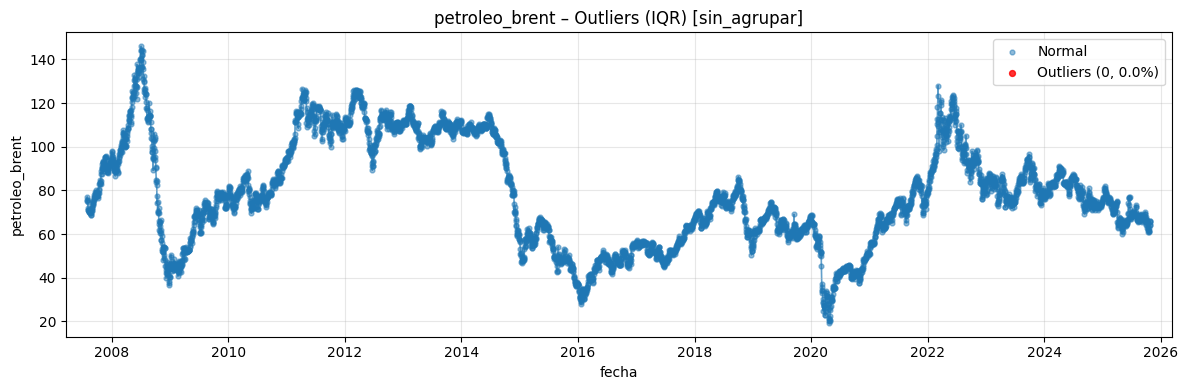

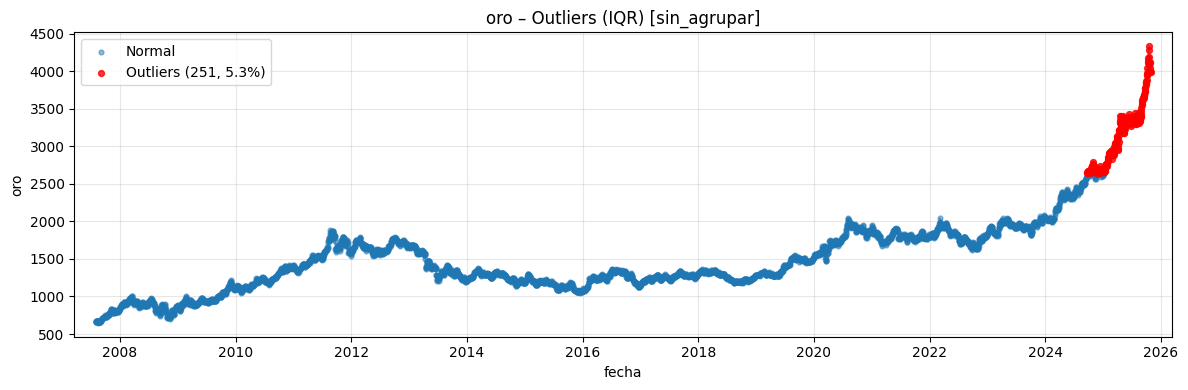

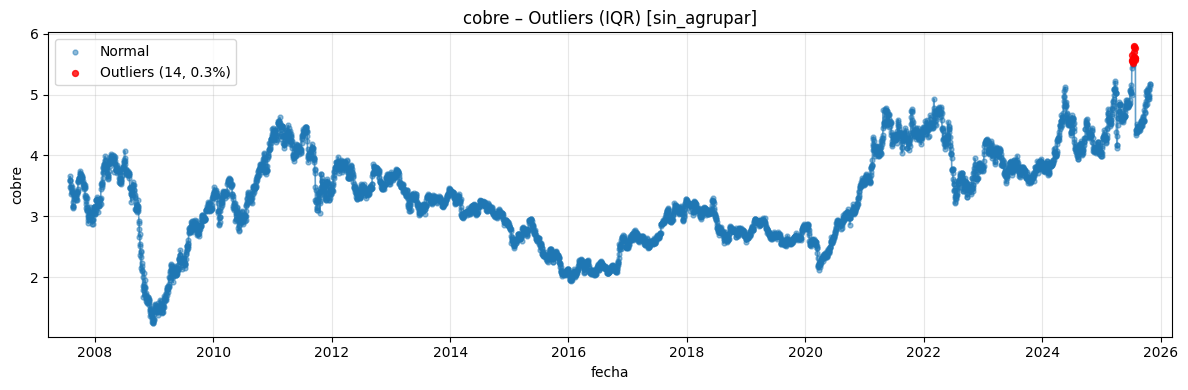

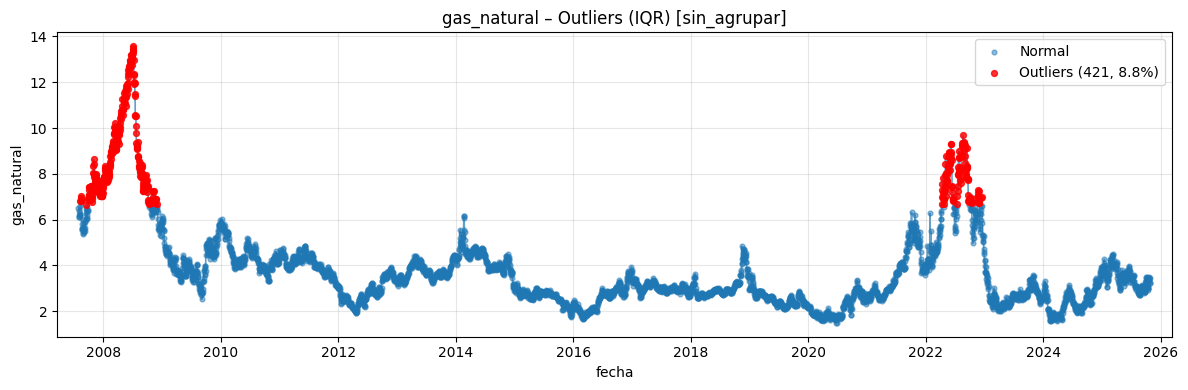

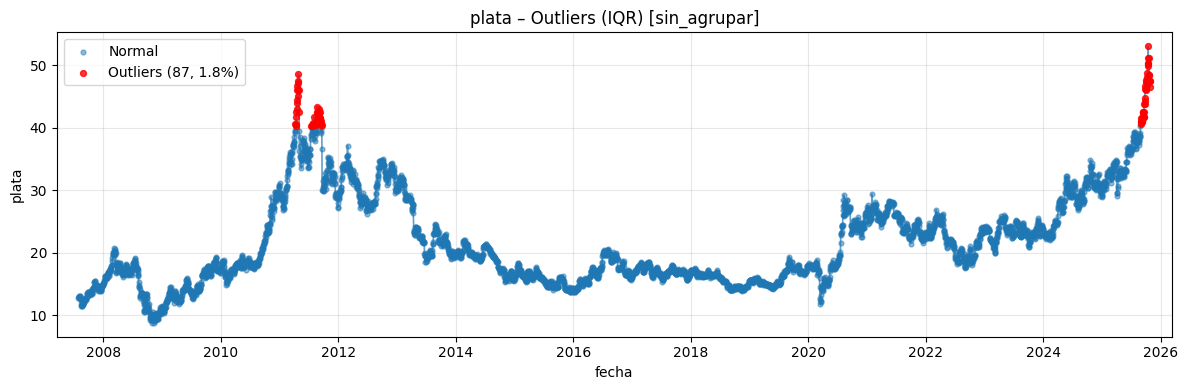

In [7]:
grafica_outliers_tipo("fecha", campos_numericos, df_consol,"sin_agrupar")

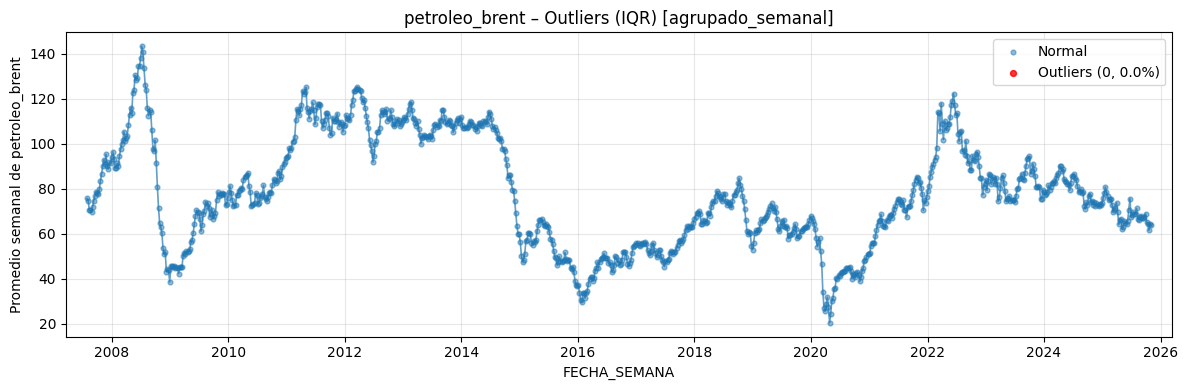

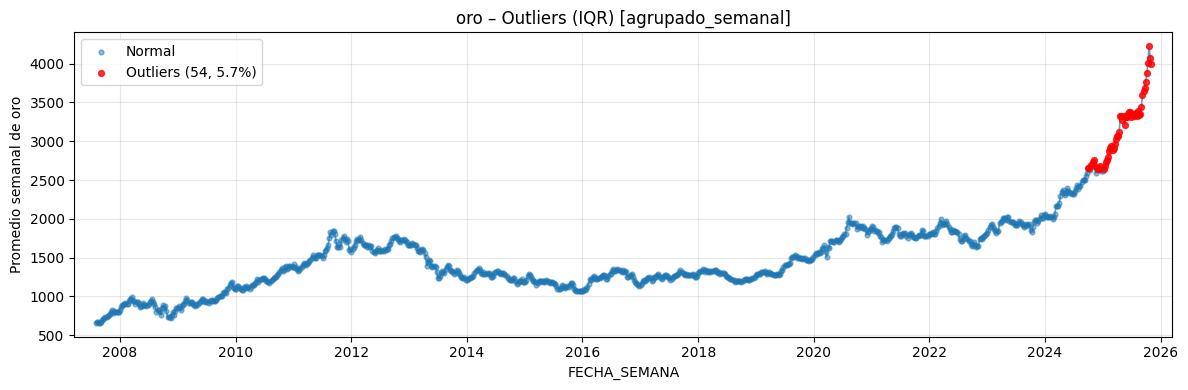

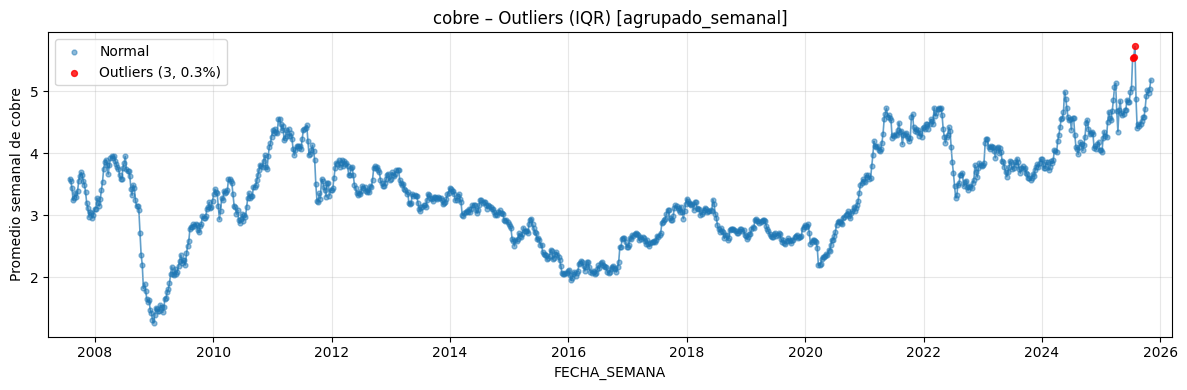

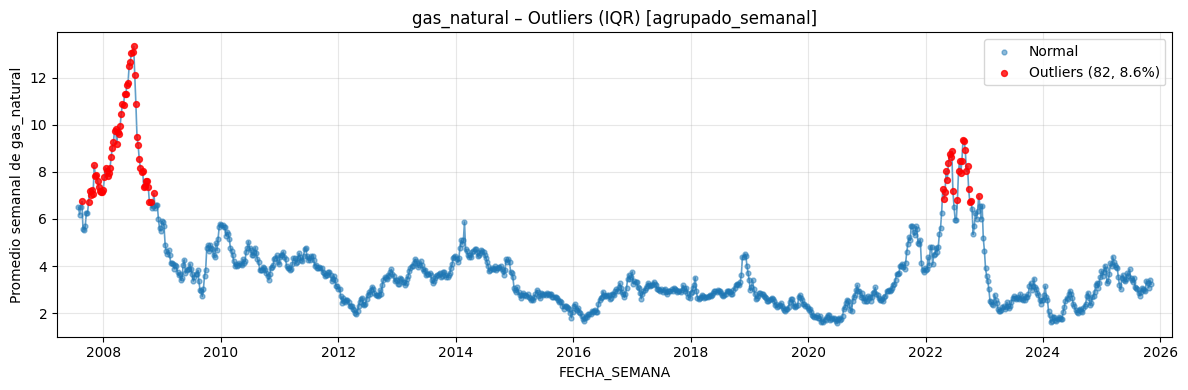

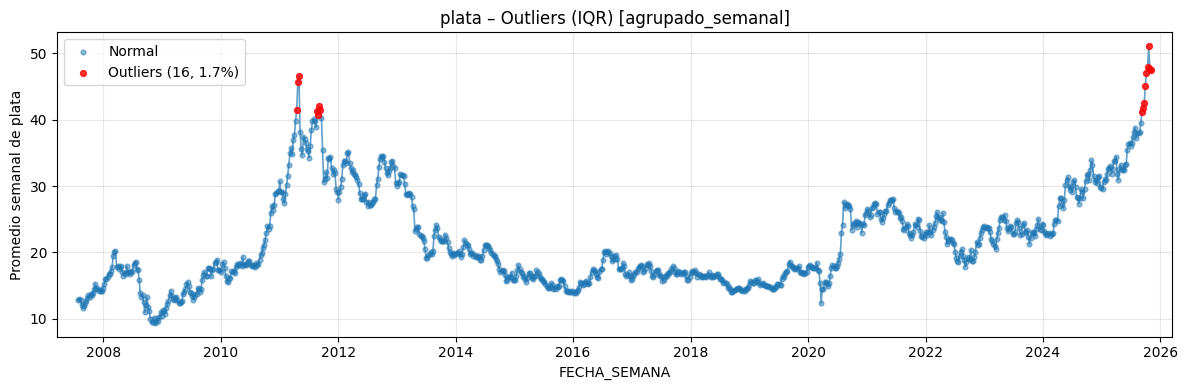

In [8]:
grafica_outliers_tipo("fecha", campos_numericos, df_consol,"agrupado_semanal")

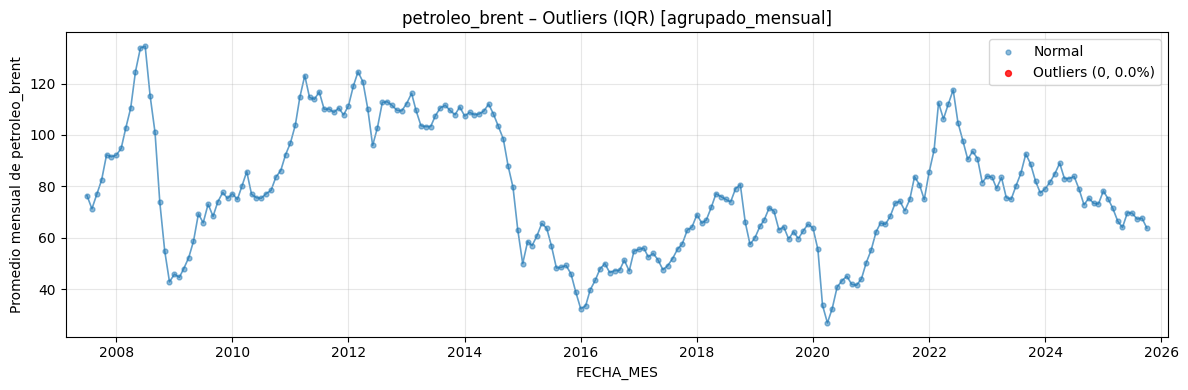

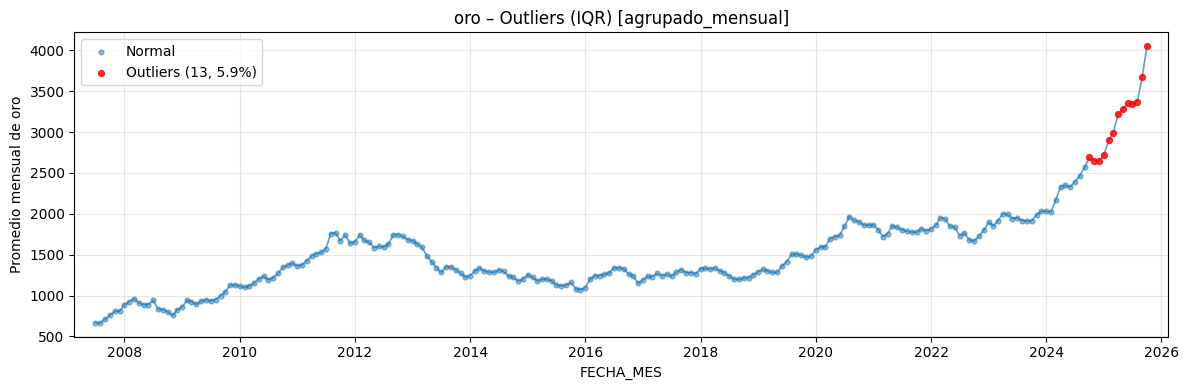

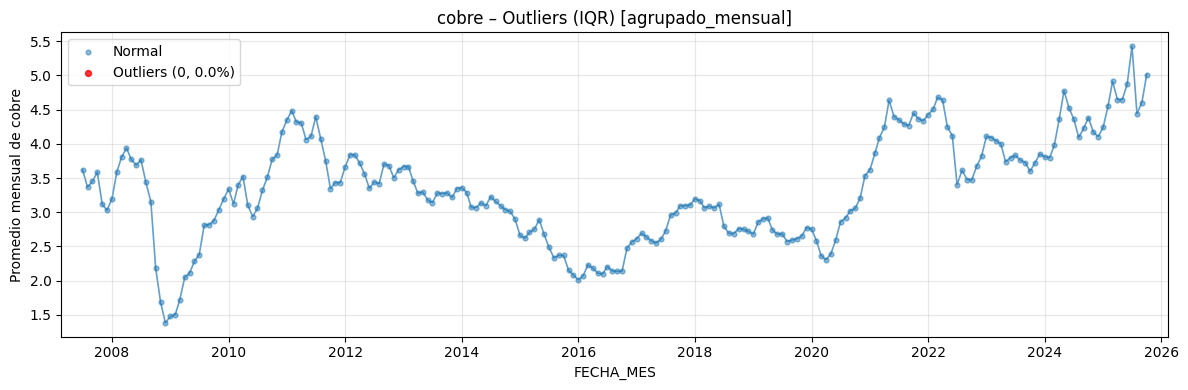

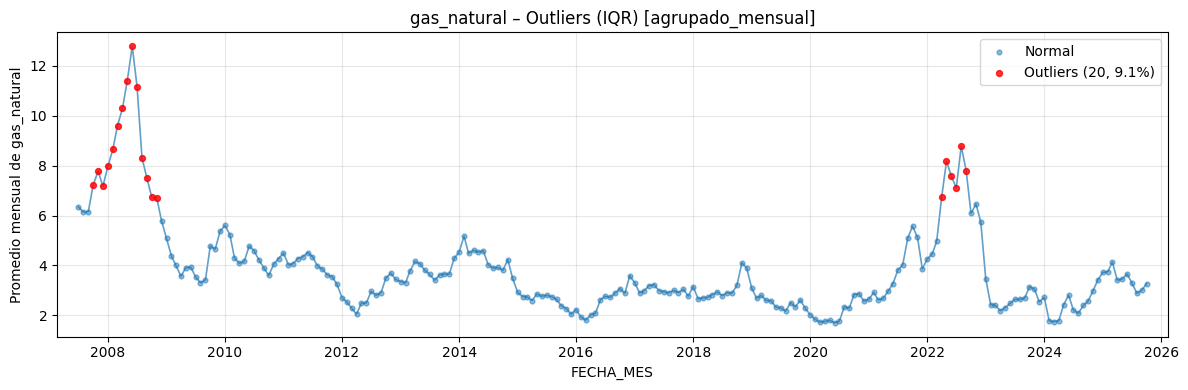

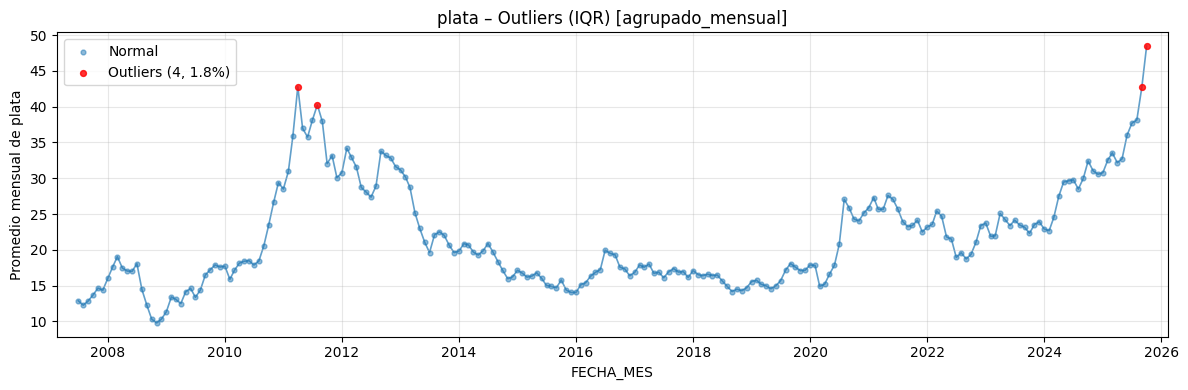

In [9]:
grafica_outliers_tipo("fecha", campos_numericos, df_consol,"agrupado_mensual")

# Modelo Mensual - Oro

In [10]:
df_train = df_col_normalizer(df_train)  
df_train.index.freq = 'B'

## Análisis de Distribución

In [11]:
# === TEST DE SHAPIRO-WILK ===
print("=" * 70)
print("TEST DE SHAPIRO-WILK (Normalidad)")
print("=" * 70)
shapiro_stat, shapiro_p = stats.shapiro(df_train['oro'].dropna())
print(f"Shapiro Statistic: {shapiro_stat:.4f}")
print(f"p-value: {shapiro_p:.4f}")
if shapiro_p > 0.05:
    print("H0: No se rechaza - distribución normal")
    
else:
    print("H0: Se rechaza hipotesis nula - datos no presentan distribución normal")

TEST DE SHAPIRO-WILK (Normalidad)
Shapiro Statistic: 0.9200
p-value: 0.0000
H0: Se rechaza hipotesis nula - datos no presentan distribución normal


al no representar una distribución normal, se debe transformar para ser procesados por una serie de tiempo clásica de la familia arima

# * Análisis Segun Lambda 

Log transformation:
Cuando: Datos positivos con varianza creciente (heteroscedasticidad) --> pero más controlada
Requisito: Todos los valores > 0

Box-Cox:
Cuando: Datos positivos, necesitas estabilizar varianza y mejorar normalidad
Requisito: Todos los valores > 0
Ventaja: Encuentra automáticamente el mejor lambda 
Acá funciona mejor que el log cuando la varianza es más descontrolada y tiene un comportamiento más aleatireo

Yeo-Johnson:
Cuando: Datos con valores negativos o ceros--> se necesitas estabilizar varianza
versión de Box-Cox para negativos

## Test de yj

In [12]:
transformacion, lambda_opt = boxcox(df_train['oro'])
print(f"Lambda óptimo: {lambda_opt:.4f}") 

Lambda óptimo: -0.1675


* BOXCOX No sirve producto de Lambda negativo --> Se opta por YEO-JOHNSON

* Mejora la varianza y mejora la normalidad de la serie  

In [13]:
transformacion, lambda_opt = yeojohnson(df_train['oro'])
print(f"Lambda óptimo: {lambda_opt:.4f}") 

Lambda óptimo: -0.1684


### Se procede a transformar a YJ

In [14]:
df_oro=df_train.copy()
df_oro['oro_yj'] = yeojohnson(df_oro['oro'], lmbda=lambda_opt)

## Análisis de Descomposición Aditiva o Multiplicativa

El modelo multiplicativo es más adecuado (CV menor).


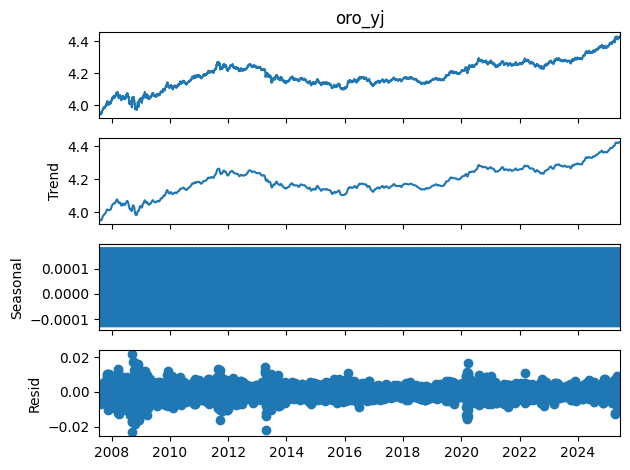

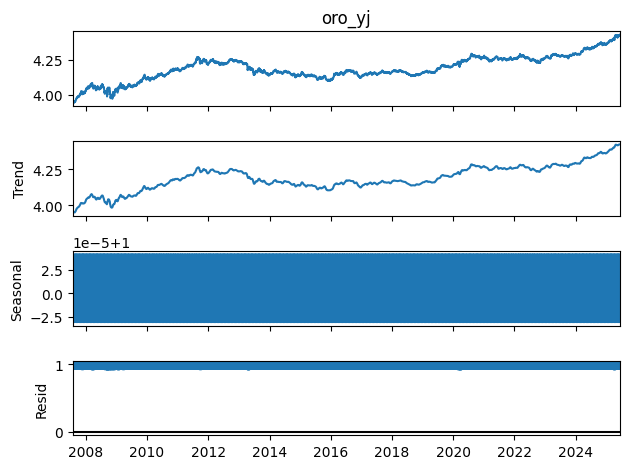

In [15]:
decompose_add = seasonal_decompose(df_oro['oro_yj'] , model='additive', period=12)
decompose_mult = seasonal_decompose(df_oro['oro_yj'] , model='multiplicative', period=12)

decompose_add.plot()
decompose_mult.plot()


seasonal_add = decompose_add.seasonal
seasonal_mult = decompose_mult.seasonal

cv_add = variation(seasonal_add.dropna())
cv_mult = variation(seasonal_mult.dropna()) 
if cv_add < cv_mult:
    print("El modelo aditivo es más adecuado (CV menor).")
elif cv_add > cv_mult:
    print("El modelo multiplicativo es más adecuado (CV menor).")
else:
    print("Ambos modelos tienen el mismo CV.")

* Según nuestro test existe la posibilidad de que un modelo SARIMA se pueda adaptar bien a nuestros datos, pero claramente muestra tendencia, así que amerita test de DF

### ADF Y KPSS

In [16]:
series_to_test = df_oro['oro_yj'] .dropna()

#ADF
adf_stat, adf_pval, adf_lags, adf_nobs, adf_crit, _ = adfuller(series_to_test)
print(f"ADF Statistic : {adf_stat:.4f}")
print(f"ADF p-value   : {adf_pval:.4g}")
print("»", "Estacionaria" if adf_pval < 0.05 else "NO estacionaria", "según ADF")

#KPSS
kpss_stat, kpss_pval, kpss_lags, kpss_crit = kpss(series_to_test, regression='c', nlags="auto")
print(f"KPSS Statistic: {kpss_stat:.4f}")
print(f"KPSS p-value  : {kpss_pval:.4g}")
print("»", "Estacionaria" if kpss_pval > 0.05 else "NO estacionaria", "según KPSS")

tests_df = pd.DataFrame([
    {
        "serie": "oro_yj",
        "test": "ADF",
        "stat": adf_stat,
        "p_value": adf_pval,
        "lags_usados": adf_lags,
        "n_observaciones": adf_nobs,
        "crit_1%": adf_crit.get("1%"),
        "crit_5%": adf_crit.get("5%"),
        "crit_10%": adf_crit.get("10%"),
        "estacionaria": adf_pval < 0.05  # criterio ADF
    },
    {
        "serie": "oro_yj",
        "test": "KPSS (c)",
        "stat": kpss_stat,
        "p_value": kpss_pval,
        "lags_usados": kpss_lags,
        "n_observaciones": series_to_test.shape[0],
        "crit_1%": float(kpss_crit.get("1%")),
        "crit_5%": float(kpss_crit.get("5%")),
        "crit_10%": float(kpss_crit.get("10%")),
        "estacionaria": kpss_pval > 0.05  # criterio KPSS
    }
])

ts_tests_mensual = tests_df

print(ts_tests_mensual)

ADF Statistic : -1.2675
ADF p-value   : 0.6439
» NO estacionaria según ADF
KPSS Statistic: 6.6805
KPSS p-value  : 0.01
» NO estacionaria según KPSS
    serie      test      stat  p_value  lags_usados  n_observaciones  \
0  oro_yj       ADF -1.267529 0.643894           13             4651   
1  oro_yj  KPSS (c)  6.680498 0.010000           41             4665   

    crit_1%   crit_5%  crit_10%  estacionaria  
0 -3.431757 -2.862162 -2.567101         False  
1  0.739000  0.463000  0.347000         False  


* Producto de que los modelos de la familia arima estan hechos para manejar datos estacionarios, se opta por diferenciar

In [17]:
df_oro['oro_yj_dif'] = df_oro['oro_yj'].diff()
df_cierre_mensual_dif_oro = df_oro.dropna(subset="oro_yj_dif")

In [18]:
#ADF
adf_stat_dif, adf_pval_dif, adf_lags_dif, adf_nobs_dif, adf_crit_dif, _ = adfuller(df_cierre_mensual_dif_oro["oro_yj_dif"])
print(f"ADF Statistic : {adf_stat_dif:.4f}")
print(f"ADF p-value   : {adf_pval_dif:.4g}")
print("»", "Estacionaria" if adf_pval_dif < 0.05 else "NO estacionaria", "según ADF")

#KPSS
kpss_stat_dif, kpss_pval_dif, kpss_lags_dif, kpss_crit_dif = kpss(df_cierre_mensual_dif_oro["oro_yj_dif"], regression='c', nlags="auto")
print(f"KPSS Statistic: {kpss_stat_dif:.4f}")
print(f"KPSS p-value  : {kpss_pval_dif:.4g}")
print("»", "Estacionaria" if kpss_pval_dif > 0.05 else "NO estacionaria", "según KPSS")

tests_df_dif = pd.DataFrame([
    {
        "serie": "oro_yj_dif",
        "test": "ADF",
        "stat": adf_stat_dif,
        "p_value": adf_pval_dif,
        "lags_usados": adf_lags_dif,
        "n_observaciones": adf_nobs_dif,
        "crit_1%": adf_crit_dif.get("1%"),
        "crit_5%": adf_crit_dif.get("5%"),
        "crit_10%": adf_crit_dif.get("10%"),
        "estacionaria": adf_pval_dif < 0.05  # criterio ADF
    },
    {
        "serie": "oro_yj_dif",
        "test": "KPSS (c)",
        "stat": kpss_stat_dif,
        "p_value": kpss_pval_dif,
        "lags_usados": kpss_lags_dif,
        "n_observaciones": df_cierre_mensual_dif_oro["oro_yj_dif"].shape[0],
        "crit_1%": float(kpss_crit_dif.get("1%")),
        "crit_5%": float(kpss_crit_dif.get("5%")),
        "crit_10%": float(kpss_crit_dif.get("10%")),
        "estacionaria": kpss_pval_dif > 0.05  # criterio KPSS
    }
])

ts_tests_mensual_dif = tests_df_dif

print(ts_tests_mensual_dif)

ADF Statistic : -19.3586
ADF p-value   : 0
» Estacionaria según ADF
KPSS Statistic: 0.1691
KPSS p-value  : 0.1
» Estacionaria según KPSS
        serie      test       stat  p_value  lags_usados  n_observaciones  \
0  oro_yj_dif       ADF -19.358644 0.000000           12             4651   
1  oro_yj_dif  KPSS (c)   0.169080 0.100000           11             4664   

    crit_1%   crit_5%  crit_10%  estacionaria  
0 -3.431757 -2.862162 -2.567101          True  
1  0.739000  0.463000  0.347000          True  


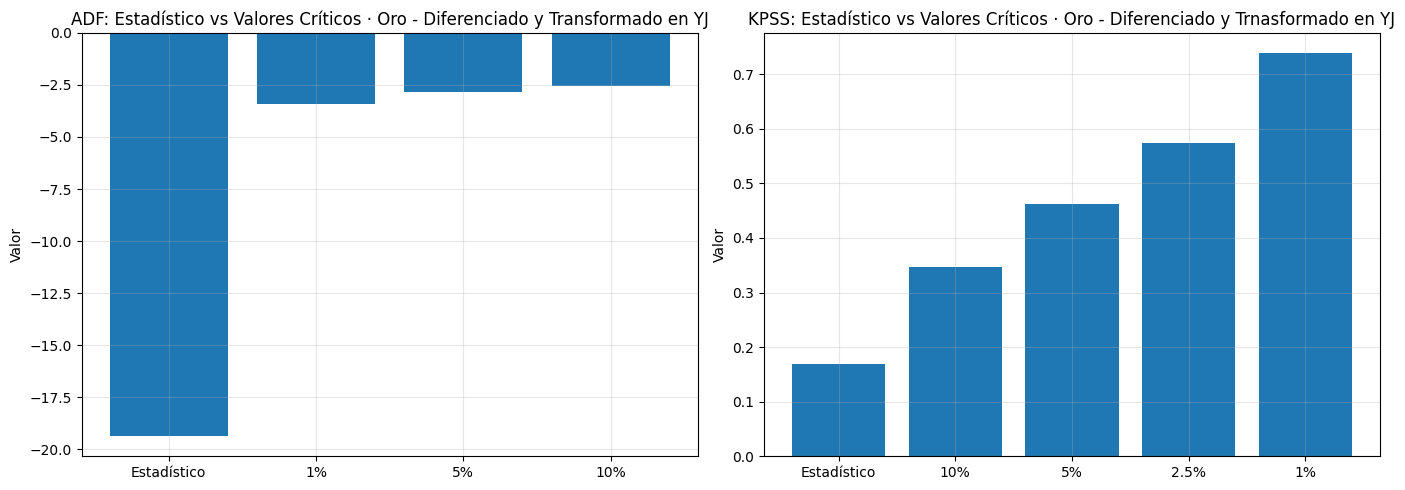

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ADF
axes[0].bar(['Estadístico'] + list(adf_crit_dif.keys()),
            [adf_stat_dif] + list(adf_crit_dif.values()))
axes[0].set_title("ADF: Estadístico vs Valores Críticos · Oro - Diferenciado y Transformado en YJ")
axes[0].set_ylabel("Valor"); axes[0].grid(alpha=.3)

# KPSS
axes[1].bar(['Estadístico'] + list(kpss_crit_dif.keys()),
            [kpss_stat_dif] + [float(k) for k in kpss_crit_dif.values()])
axes[1].set_title("KPSS: Estadístico vs Valores Críticos · Oro - Diferenciado y Trnasformado en YJ")
axes[1].set_ylabel("Valor"); axes[1].grid(alpha=.3)

plt.tight_layout(); plt.show()

* La Serie es Estacionaria

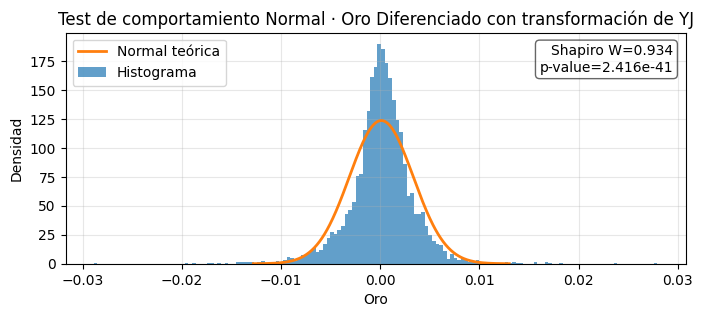

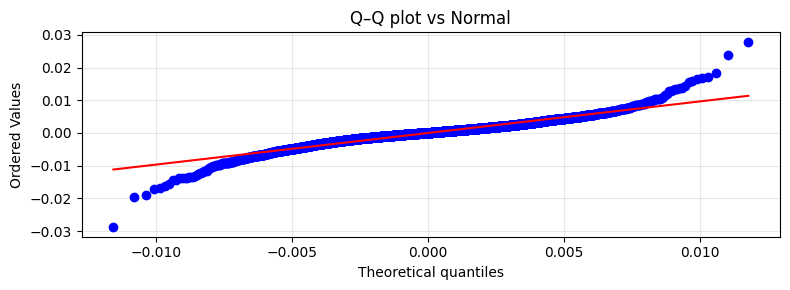

In [20]:
y = df_cierre_mensual_dif_oro["oro_yj_dif"]
sh_stat, sh_p = stats.shapiro(y)

mu, sigma = np.mean(y), np.std(y, ddof=1)
xs = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)

#hist + curva teorica
plt.figure(figsize=(8,3))
plt.hist(y, bins='auto', density=True, alpha=0.7)
plt.plot(xs, stats.norm.pdf(xs, mu, sigma), linewidth=2)
plt.title("Test de comportamiento Normal · Oro Diferenciado con transformación de YJ")
plt.xlabel("Oro")
plt.ylabel("Densidad")
plt.grid(alpha=.3)
plt.legend(["Normal teórica", "Histograma"], loc="best")
plt.annotate(f"Shapiro W={sh_stat:.3f}\np-value={sh_p:.4g}",
             xy=(0.98, 0.95), xycoords="axes fraction",
             ha="right", va="top",
             bbox=dict(boxstyle="round", fc="white", alpha=0.6))

# --- Q–Q plot ---
plt.figure(figsize=(8,3))
# Usamos la normal con media y sigma estimados
stats.probplot(y, dist="norm", sparams=(mu, sigma), plot=plt)
plt.title("Q–Q plot vs Normal")
plt.grid(alpha=.3)

plt.tight_layout()
plt.show()

## ACF Y PACF AL PASAR TEST

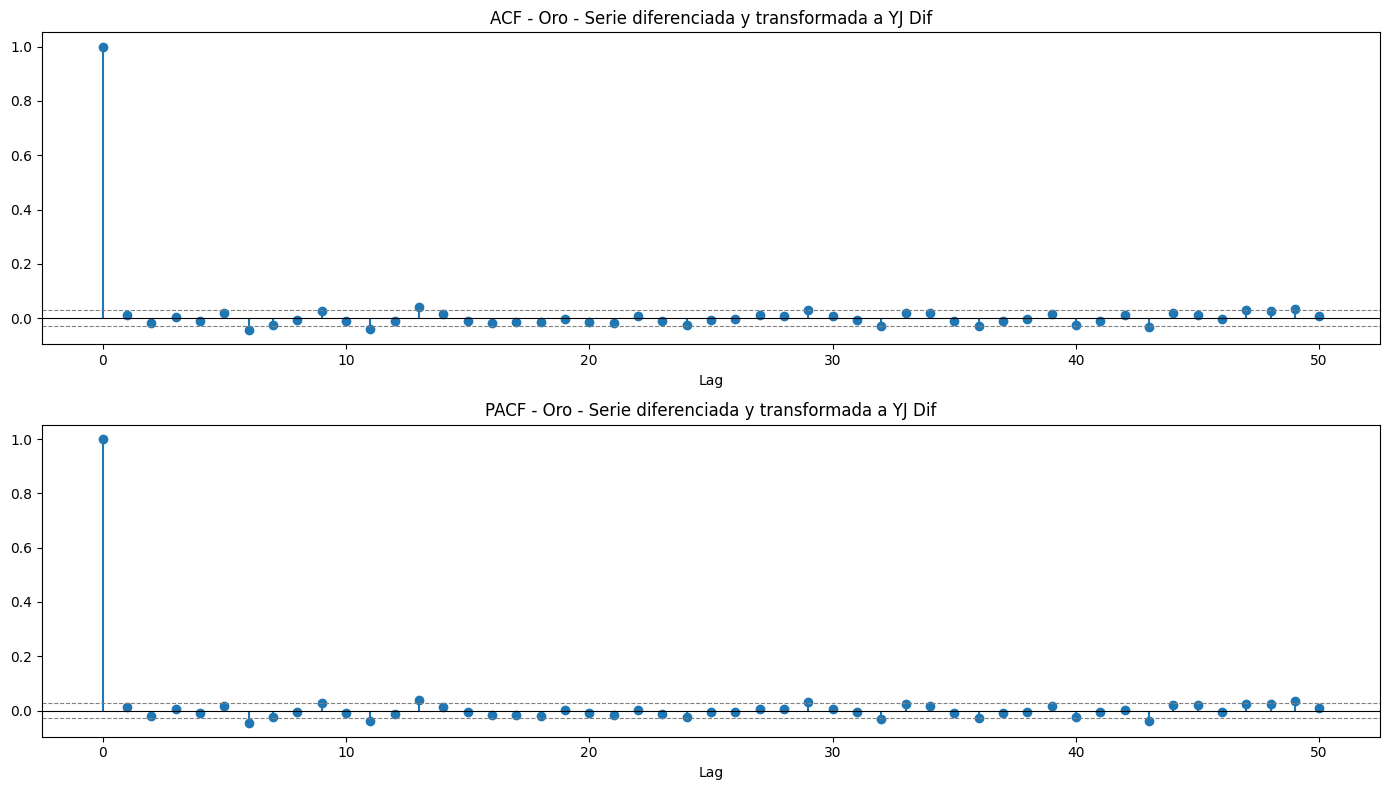

In [21]:
n = len(df_cierre_mensual_dif_oro)
nlags_acf  = min(50, n-1)
nlags_pacf = min(50, n-1)

pacf_monthly = pacf(df_cierre_mensual_dif_oro["oro_yj_dif"], nlags=nlags_pacf, method='ywmle')
acf_monthly = acf(df_cierre_mensual_dif_oro["oro_yj_dif"], nlags=nlags_acf)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
conf = 1.96 / np.sqrt(n)

axes[0].stem(range(len(acf_monthly)), acf_monthly, basefmt=' ')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].axhline(conf, linestyle='--', color='gray', linewidth=0.8)
axes[0].axhline(-conf, linestyle='--', color='gray', linewidth=0.8)
axes[0].set_title('ACF - Oro - Serie diferenciada y transformada a YJ Dif')
axes[0].set_xlabel('Lag')

axes[1].stem(range(len(pacf_monthly)), pacf_monthly, basefmt=' ')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].axhline(conf, linestyle='--', color='gray', linewidth=0.8)
axes[1].axhline(-conf, linestyle='--', color='gray', linewidth=0.8)
axes[1].set_title('PACF - Oro - Serie diferenciada y transformada a YJ Dif')
axes[1].set_xlabel('Lag')

plt.tight_layout()
plt.show()

## Podría indicar que existe un componente estacional cada 10 periodos

* p=AR=0
* d=1 --> 1 diferenciacion  
* No hay componentes que nos hayan pensar que para lag 0 se promedien x lag pasados --> probar entre 0 y 1
* No se aprecia con exactitud los componentes autoregresivos que tienen los lag de forma estacional, así que se opta por buscar en base a lista [1,0]
* Q Podría ser 5, se aprecia y shock proveniente de los residuos en 5 o 6
* No se puede distinguir claramente una estacionalidad, pero se optara por probar s=[5,7]

### Eliminar la colinealidad a través de Granger

In [22]:
target = "oro_yj_dif"
num_cols = df_cierre_mensual_dif_oro.select_dtypes(include=[np.number]).columns.drop(target, errors="ignore")

#Calcular Granger F para todas
granger_scores = []
for col in num_cols:
    data = df_cierre_mensual_dif_oro[[target, col]].dropna()
    if len(data) < 10:
        continue
    try:
        results = grangercausalitytests(data, maxlag=3, verbose=False)
        #Máximo F-stat entre todos los lags
        max_f = max([results[lag][0]['ssr_ftest'][0] for lag in results.keys()])
        granger_scores.append({'variable': col, 'Granger_F': max_f})
    except:
        continue

granger_df = pd.DataFrame(granger_scores).sort_values('Granger_F', ascending=False)

#Eliminar multicolinealidad (corr > 0.85)
vars_list = granger_df['variable'].tolist()
corr_matrix = df_cierre_mensual_dif_oro[vars_list].corr()

variables_a_eliminar = set()
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.85:
            var1, var2 = corr_matrix.columns[i], corr_matrix.columns[j]
            f1 = granger_df[granger_df['variable'] == var1]['Granger_F'].values[0]
            f2 = granger_df[granger_df['variable'] == var2]['Granger_F'].values[0]
            
            #Eliminar la de MENOR Granger F (peor causalidad)
            variables_a_eliminar.add(var2 if f1 > f2 else var1)

top = granger_df[~granger_df['variable'].isin(variables_a_eliminar)] 
lista_variables_oro=top['variable'].tolist()+ list([target])+['oro_yj']
lista_variables_oro_test=top['variable'].tolist()+['oro_yj']       

#### Limpieza de DF

In [23]:
df_oro_final=df_cierre_mensual_dif_oro[lista_variables_oro]

## Matrix de Corr() - Oro

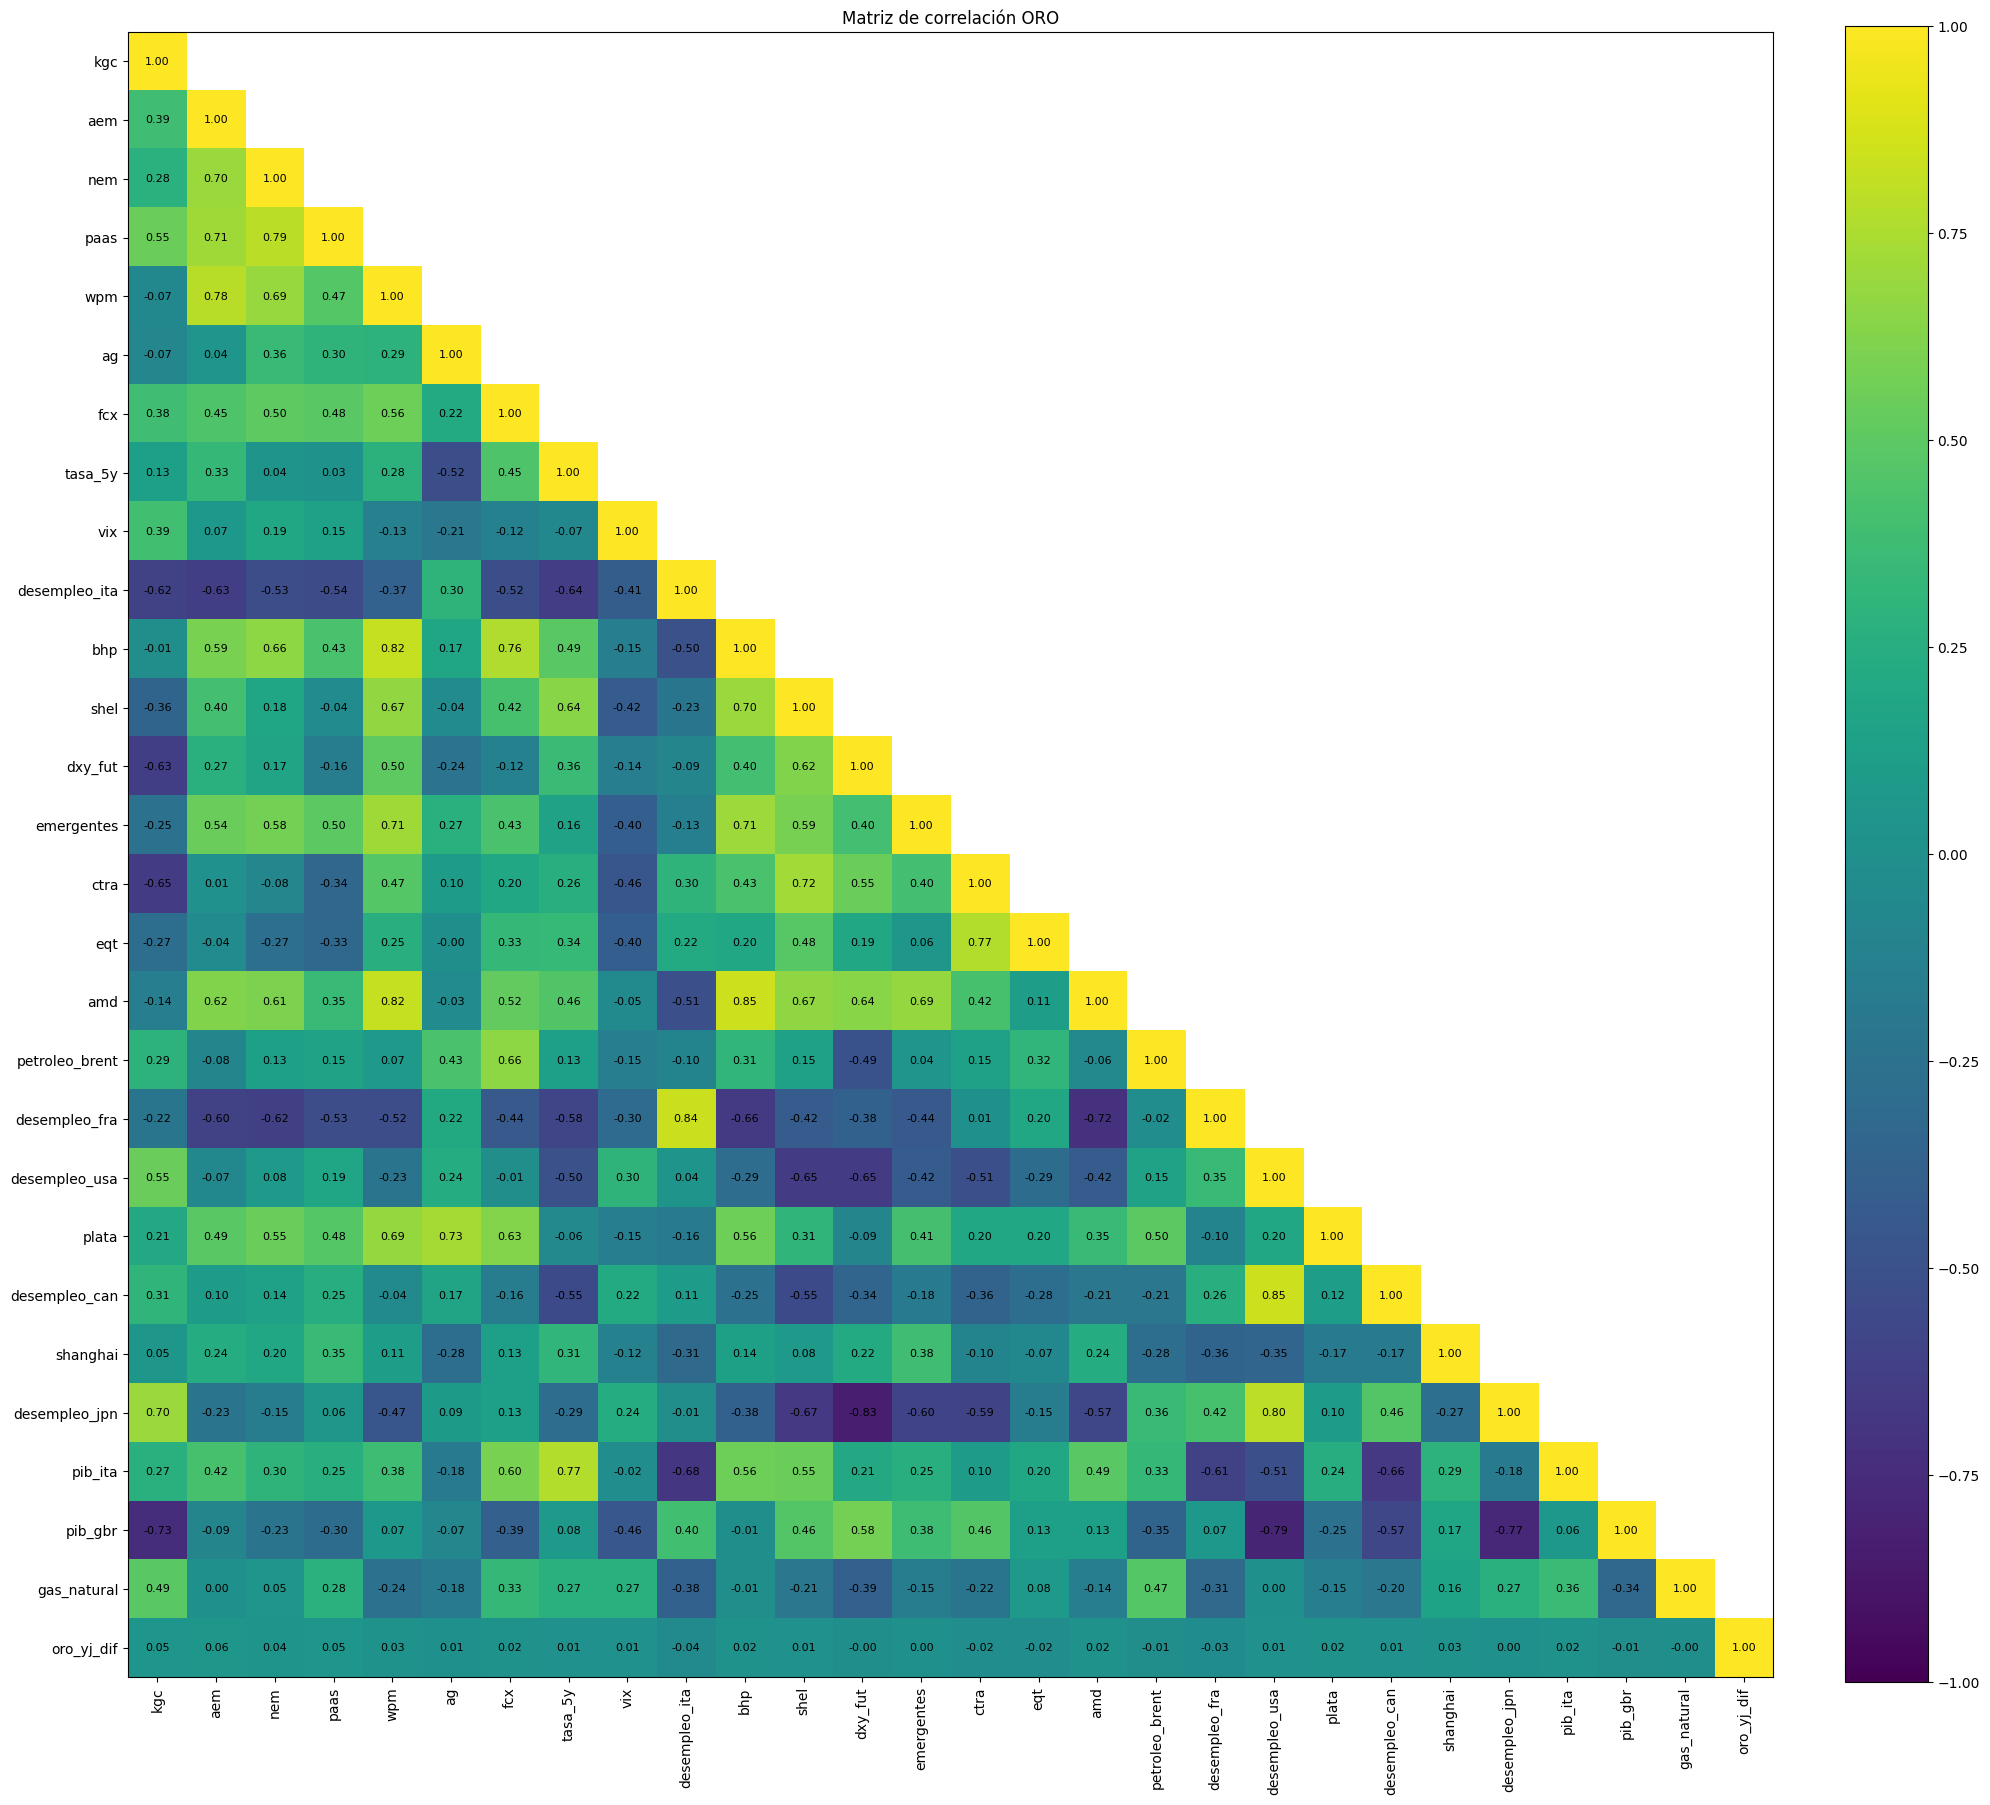

In [24]:
num_cols = (
    df_oro_final.drop(columns=["oro_yj"])
    .select_dtypes(include="number")
    .drop(columns=["fecha"], errors="ignore")
)

corr = num_cols.corr()

M = corr.values.copy()
mask = np.triu(np.ones_like(M, dtype=bool), k=1)
M_masked = M.copy()
M_masked[mask] = np.nan

plt.figure(figsize=(20, 20))
im = plt.imshow(M_masked, vmin=-1, vmax=1)  # sin cmap explícito
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)

for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        if not mask[i, j] and not np.isnan(M_masked[i, j]):
            plt.text(j, i, f"{M[i, j]:.2f}", ha="center", va="center", fontsize=8)

plt.title("Matriz de correlación ORO")
plt.tight_layout()
plt.show()

### Analisis de Causalidad de Granger 

In [25]:
exclude_cols = ["oro","oro_yj"]
features = df_oro_final.drop(columns=exclude_cols, errors="ignore").select_dtypes(include=['float64', 'int64']).columns

max_lag = 7
results = []

for col in features:
    try:
        data = df_oro_final[[col, "oro_yj_dif"]].dropna()
        
        if len(data) > max_lag + 1:
            test = grangercausalitytests(data[["oro_yj_dif", col]], max_lag, verbose=False)
            row = {'Feature': col}
            for lag in range(1, max_lag + 1):
                p_val = test[lag][0]['ssr_ftest'][1]
                row[f'P_Value_Lag{lag}'] = p_val
                row[f'Significant_Lag{lag}'] = p_val < 0.05
            
            results.append(row)
    except:
        continue
granger_df = pd.DataFrame(results)
granger_df['Min_P_Value'] = granger_df[['P_Value_Lag1', 'P_Value_Lag2', 'P_Value_Lag3']].min(axis=1)
granger_df = granger_df.sort_values('Min_P_Value').reset_index(drop=True)

granger_df.head(40)

,Feature,P_Value_Lag1,Significant_Lag1,P_Value_Lag2,Significant_Lag2,P_Value_Lag3,Significant_Lag3,P_Value_Lag4,Significant_Lag4,P_Value_Lag5,Significant_Lag5,P_Value_Lag6,Significant_Lag6,P_Value_Lag7,Significant_Lag7,Min_P_Value
0,kgc,0.161725,False,0.000000,True,0.000000,True,0.000000,True,0.000000,True,0.000000,True,0.000000,True,0.000000
1,aem,0.283484,False,0.000000,True,0.000000,True,0.000000,True,0.000000,True,0.000000,True,0.000000,True,0.000000
2,nem,0.897101,False,0.000000,True,0.000000,True,0.000000,True,0.000000,True,0.000000,True,0.000000,True,0.000000
3,paas,0.886021,False,0.000000,True,0.000000,True,0.000000,True,0.000000,True,0.000000,True,0.000000,True,0.000000
4,wpm,0.894591,False,0.000000,True,0.000000,True,0.000000,True,0.000000,True,0.000000,True,0.000000,True,0.000000
5,ag,0.064385,False,0.000000,True,0.000000,True,0.000001,True,0.000001,True,0.000003,True,0.000006,True,0.000000
6,fcx,0.750459,False,0.000015,True,0.000053,True,0.000124,True,0.000133,True,0.000218,True,0.000474,True,0.000015
7,tasa_5y,0.109858,False,0.000017,True,0.000038,True,0.000006,True,0.000017,True,0.000016,True,0.000009,True,0.000017
8,vix,0.308351,False,0.000174,True,0.000313,True,0.000004,True,0.000001,True,0.000001,True,0.000003,True,0.000174
9,bhp,0.761163,False,0.000213,True,0.000692,True,0.001140,True,0.001773,True,0.001701,True,0.001514,True,0.000213


## Se dejan solamente las variables estadisticamente Significativas hasta lag7

In [26]:
sig_cols = [c for c in granger_df.columns if c.lower().startswith('significant_lag')]
granger_df["granger_test"] = granger_df[sig_cols].any(axis=1).astype(int) 

granger_df=list(granger_df[granger_df["granger_test"]==1]["Feature"])+["oro_yj"]
df_oro_final=df_oro_final[granger_df]

   Test de Granger - Estos valores pasados en X me ayudan a predecir estos valores futuros en Y

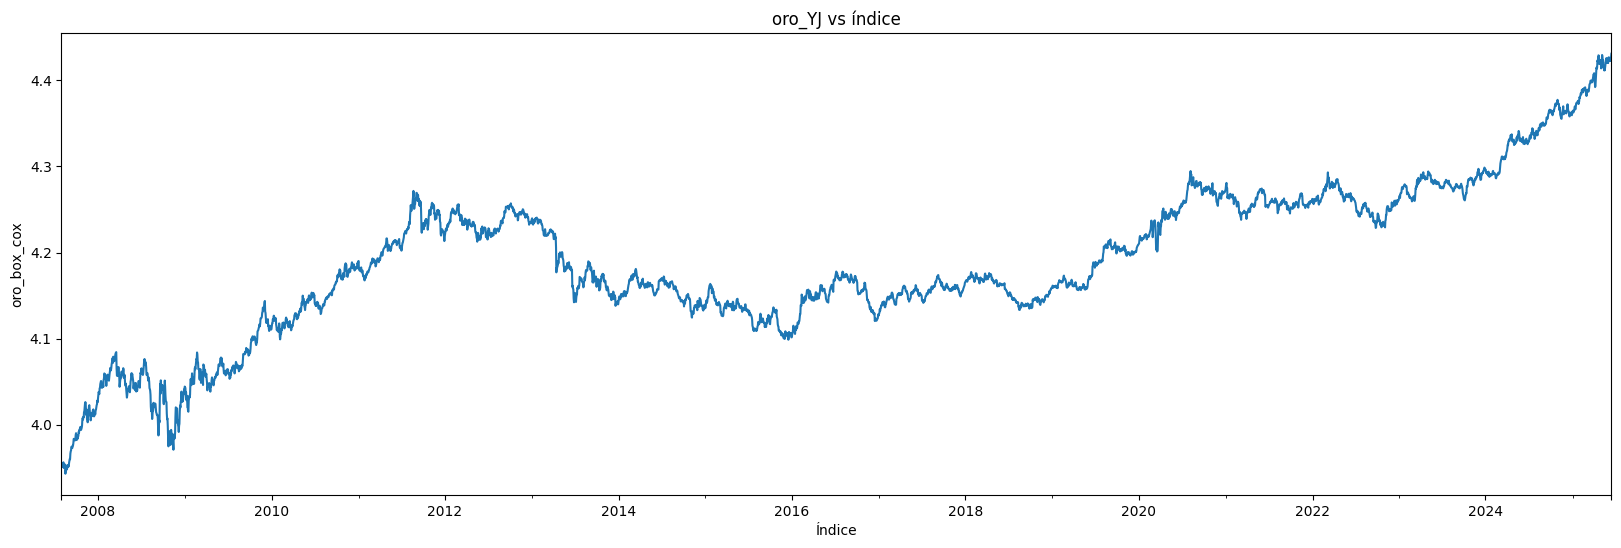

In [27]:
df_oro_final['oro_yj'].plot(figsize=(20,6))
plt.xlabel('Índice')
plt.ylabel('oro_box_cox')
plt.title('oro_YJ vs índice')
plt.show()

In [28]:
df_oro_final.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4664 entries, 2007-07-31 to 2025-06-13
Freq: B
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   kgc             4664 non-null   float64
 1   aem             4664 non-null   float64
 2   nem             4664 non-null   float64
 3   paas            4664 non-null   float64
 4   wpm             4664 non-null   float64
 5   ag              4664 non-null   float64
 6   fcx             4664 non-null   float64
 7   tasa_5y         4664 non-null   float64
 8   vix             4664 non-null   float64
 9   bhp             4664 non-null   float64
 10  emergentes      4664 non-null   float64
 11  shel            4664 non-null   float64
 12  dxy_fut         4664 non-null   float64
 13  desempleo_ita   4664 non-null   float64
 14  ctra            4664 non-null   float64
 15  eqt             4664 non-null   float64
 16  petroleo_brent  4664 non-null   float64
 17  amd    

## Análisis de Plata

### Test de Normalidad -Shapiro Wilk

In [29]:
# === TEST DE SHAPIRO-WILK ===
print("=" * 70)
print("TEST DE SHAPIRO-WILK (Normalidad)")
print("=" * 70)
shapiro_stat, shapiro_p = stats.shapiro(df_train['plata'].dropna())
print(f"Shapiro Statistic: {shapiro_stat:.4f}")
print(f"p-value: {shapiro_p:.4f}")
if shapiro_p > 0.05:
    print("H0: No se rechaza - distribución normal")
    
else:
    print("H0: Se rechaza hipotesis nula - datos no presentan distribución normal")

TEST DE SHAPIRO-WILK (Normalidad)
Shapiro Statistic: 0.9310
p-value: 0.0000
H0: Se rechaza hipotesis nula - datos no presentan distribución normal


#### Producto de que no se comporta de forma normal, se recomiendo transformar, probamos con BoxCox primero

In [30]:
transformacion, lambda_opt = boxcox(df_train['plata'])
print(f"Lambda óptimo: {lambda_opt:.4f}") 

Lambda óptimo: -0.3737


BoxCox no maneja negativos, así que provamos con lambda de YEO-JOHNSON

In [31]:
transformacion, lambda_opt_plata = yeojohnson(df_train['plata'])
print(f"Lambda óptimo: {lambda_opt_plata:.4f}")   

Lambda óptimo: -0.4414


In [32]:
df_plata=df_train.copy()

In [33]:
df_plata['plata_yj'] = yeojohnson(df_plata['plata'], lmbda=lambda_opt_plata)

## Análisis de Descomposición

El modelo multiplicativo es más adecuado (CV menor).


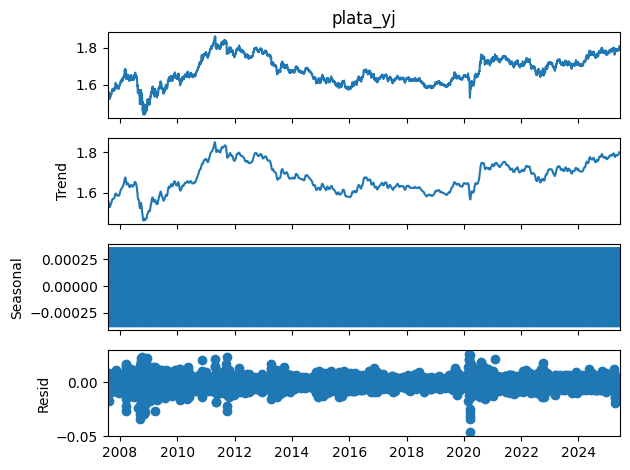

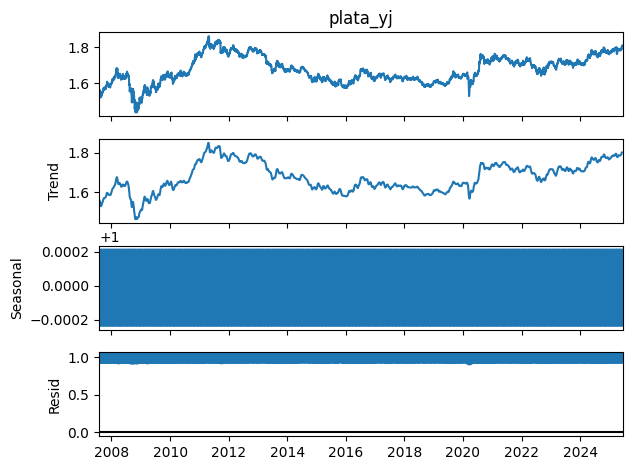

In [34]:
decompose_add = seasonal_decompose(df_plata['plata_yj'] , model='additive', period=12)
decompose_mult = seasonal_decompose(df_plata['plata_yj'] , model='multiplicative', period=12)

decompose_add.plot()
decompose_mult.plot()


seasonal_add = decompose_add.seasonal
seasonal_mult = decompose_mult.seasonal

cv_add = variation(seasonal_add.dropna())
cv_mult = variation(seasonal_mult.dropna()) 
if cv_add < cv_mult:
    print("El modelo aditivo es más adecuado (CV menor).")
elif cv_add > cv_mult:
    print("El modelo multiplicativo es más adecuado (CV menor).")
else:
    print("Ambos modelos tienen el mismo CV.")

Análisis Multiplicativo, nos da una inferencia que podríamos deber ocupar modelos estacionales (sarimax, sarima)

In [35]:
series_to_test = df_plata['plata_yj'].dropna()

#ADF
adf_stat, adf_pval, adf_lags, adf_nobs, adf_crit, _ = adfuller(series_to_test)
print(f"ADF Statistic : {adf_stat:.4f}")
print(f"ADF p-value   : {adf_pval:.4g}")
print("»", "Estacionaria" if adf_pval < 0.05 else "NO estacionaria", "según ADF")

#KPSS
kpss_stat, kpss_pval, kpss_lags, kpss_crit = kpss(series_to_test, regression='c', nlags="auto")
print(f"KPSS Statistic: {kpss_stat:.4f}")
print(f"KPSS p-value  : {kpss_pval:.4g}")
print("»", "Estacionaria" if kpss_pval > 0.05 else "NO estacionaria", "según KPSS")

tests_df = pd.DataFrame([
    {
        "serie": "Plata_JY",
        "test": "ADF",
        "stat": adf_stat,
        "p_value": adf_pval,
        "lags_usados": adf_lags,
        "n_observaciones": adf_nobs,
        "crit_1%": adf_crit.get("1%"),
        "crit_5%": adf_crit.get("5%"),
        "crit_10%": adf_crit.get("10%"),
        "estacionaria": adf_pval < 0.05  # criterio ADF
    },
    {
        "serie": "Plata_JY",
        "test": "KPSS (c)",
        "stat": kpss_stat,
        "p_value": kpss_pval,
        "lags_usados": kpss_lags,
        "n_observaciones": series_to_test.shape[0],
        "crit_1%": float(kpss_crit.get("1%")),
        "crit_5%": float(kpss_crit.get("5%")),
        "crit_10%": float(kpss_crit.get("10%")),
        "estacionaria": kpss_pval > 0.05  # criterio KPSS
    }
])

ts_tests_mensual = tests_df

print(ts_tests_mensual)

ADF Statistic : -2.2596
ADF p-value   : 0.1853
» NO estacionaria según ADF
KPSS Statistic: 1.4161
KPSS p-value  : 0.01
» NO estacionaria según KPSS
      serie      test      stat  p_value  lags_usados  n_observaciones  \
0  Plata_JY       ADF -2.259614 0.185324            0             4664   
1  Plata_JY  KPSS (c)  1.416121 0.010000           41             4665   

    crit_1%   crit_5%  crit_10%  estacionaria  
0 -3.431753 -2.862160 -2.567100         False  
1  0.739000  0.463000  0.347000         False  


Producto de que no es estacionaria en ADF, se procede a diferenciar

In [36]:
df_plata['plata_yj_dif']=df_plata['plata_yj'].diff()

In [37]:
series_to_test_dif = df_plata['plata_yj_dif'].dropna()

#ADF
adf_stat_dif, adf_pval_dif, adf_lags_dif, adf_nobs_dif, adf_crit_dif, _ = adfuller(series_to_test_dif)
print(f"ADF Statistic : {adf_stat_dif:.4f}")
print(f"ADF p-value   : {adf_pval_dif:.4g}")
print("»", "Estacionaria" if adf_pval_dif < 0.05 else "NO estacionaria", "según ADF")

#KPSS
kpss_stat_dif, kpss_pval_dif, kpss_lags_dif, kpss_crit_dif = kpss(series_to_test_dif,regression='c', nlags="auto")
print(f"KPSS Statistic: {kpss_stat_dif:.4f}")
print(f"KPSS p-value  : {kpss_pval_dif:.4g}")
print("»", "Estacionaria" if kpss_pval_dif > 0.05 else "NO estacionaria", "según KPSS")

tests_df_dif = pd.DataFrame([
    {
        "serie": "Plata_JY_dif",
        "test": "ADF",
        "stat": adf_stat_dif,
        "p_value": adf_pval_dif,
        "lags_usados": adf_lags_dif,
        "n_observaciones": adf_nobs_dif,
        "crit_1%": adf_crit_dif.get("1%"),
        "crit_5%": adf_crit_dif.get("5%"),
        "crit_10%": adf_crit_dif.get("10%"),
        "estacionaria": adf_pval_dif < 0.05  # criterio ADF
    },
    {
        "serie": "Plata_JY_dif",
        "test": "KPSS (c)",
        "stat": kpss_stat_dif,
        "p_value": kpss_pval_dif,
        "lags_usados": kpss_lags_dif,
        "n_observaciones": series_to_test_dif.shape[0],
        "crit_1%": float(kpss_crit_dif.get("1%")),
        "crit_5%": float(kpss_crit_dif.get("5%")),
        "crit_10%": float(kpss_crit_dif.get("10%")),
        "estacionaria": kpss_pval_dif > 0.05  # criterio KPSS
    }
])

ts_tests_mensual_dif = tests_df_dif

print(ts_tests_mensual_dif)

ADF Statistic : -68.4636
ADF p-value   : 0
» Estacionaria según ADF
KPSS Statistic: 0.0681
KPSS p-value  : 0.1
» Estacionaria según KPSS
          serie      test       stat  p_value  lags_usados  n_observaciones  \
0  Plata_JY_dif       ADF -68.463590 0.000000            0             4663   
1  Plata_JY_dif  KPSS (c)   0.068097 0.100000           13             4664   

    crit_1%   crit_5%  crit_10%  estacionaria  
0 -3.431753 -2.862160 -2.567100          True  
1  0.739000  0.463000  0.347000          True  


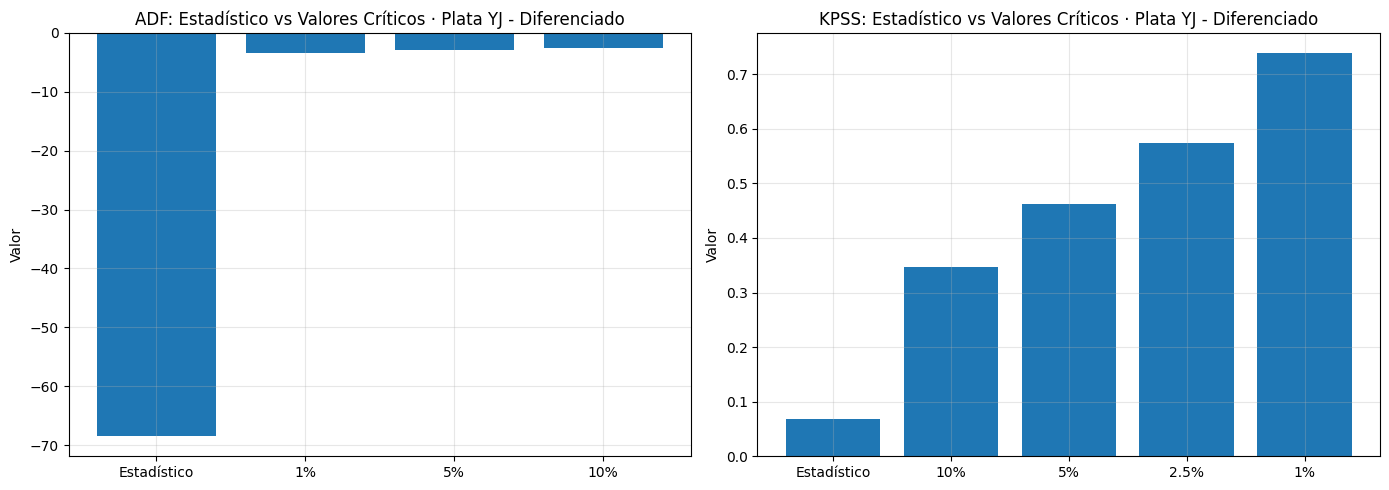

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ADF
axes[0].bar(['Estadístico'] + list(adf_crit_dif.keys()),
            [adf_stat_dif] + list(adf_crit_dif.values()))
axes[0].set_title("ADF: Estadístico vs Valores Críticos · Plata YJ - Diferenciado")
axes[0].set_ylabel("Valor"); axes[0].grid(alpha=.3)

# KPSS
axes[1].bar(['Estadístico'] + list(kpss_crit_dif.keys()),
            [kpss_stat_dif] + [float(k) for k in kpss_crit_dif.values()])
axes[1].set_title("KPSS: Estadístico vs Valores Críticos · Plata YJ - Diferenciado")
axes[1].set_ylabel("Valor"); axes[1].grid(alpha=.3)

plt.tight_layout(); plt.show()

In [39]:
df_cierre_mensual_dif_plata = df_plata.dropna(subset="plata_yj_dif")

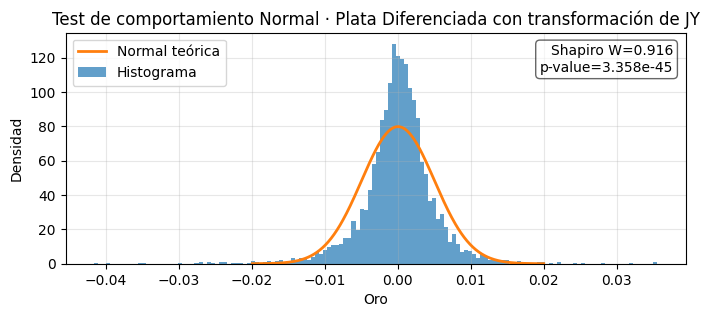

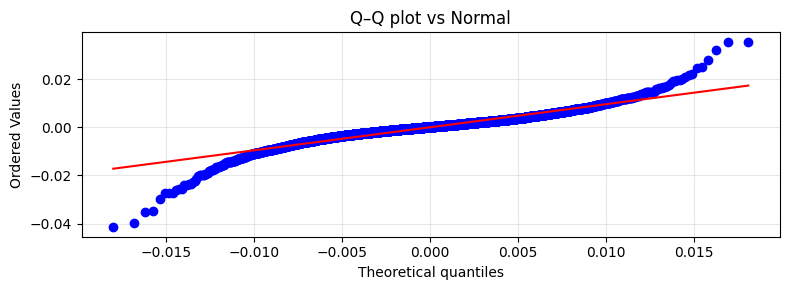

In [40]:
y = df_cierre_mensual_dif_plata["plata_yj_dif"]
sh_stat, sh_p = stats.shapiro(y)

mu, sigma = np.mean(y), np.std(y, ddof=1)
xs = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)

#hist + curva teorica
plt.figure(figsize=(8,3))
plt.hist(y, bins='auto', density=True, alpha=0.7)
plt.plot(xs, stats.norm.pdf(xs, mu, sigma), linewidth=2)
plt.title("Test de comportamiento Normal · Plata Diferenciada con transformación de JY")
plt.xlabel("Oro")
plt.ylabel("Densidad")
plt.grid(alpha=.3)
plt.legend(["Normal teórica", "Histograma"], loc="best")
plt.annotate(f"Shapiro W={sh_stat:.3f}\np-value={sh_p:.4g}",
             xy=(0.98, 0.95), xycoords="axes fraction",
             ha="right", va="top",
             bbox=dict(boxstyle="round", fc="white", alpha=0.6))

# --- Q–Q plot ---
plt.figure(figsize=(8,3))
# Usamos la normal con media y sigma estimados
stats.probplot(y, dist="norm", sparams=(mu, sigma), plot=plt)
plt.title("Q–Q plot vs Normal")
plt.grid(alpha=.3)

plt.tight_layout()
plt.show()

## ACF - PACF

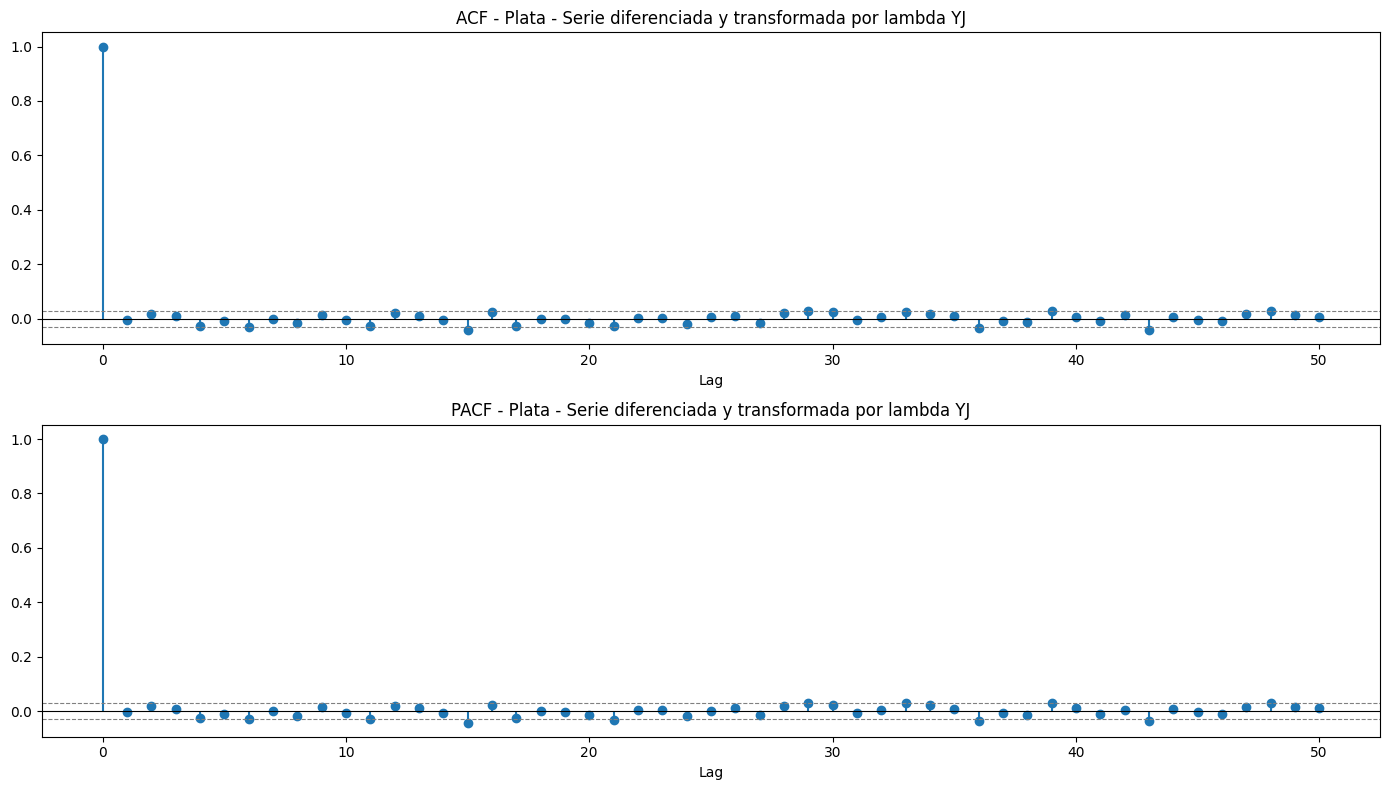

In [41]:
n = len(df_cierre_mensual_dif_plata)
nlags_acf  = min(50, n-1)
nlags_pacf = min(50, n-1)

pacf_monthly = pacf(df_cierre_mensual_dif_plata["plata_yj_dif"], nlags=nlags_pacf, method='ywmle')
acf_monthly = acf(df_cierre_mensual_dif_plata["plata_yj_dif"], nlags=nlags_acf)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
conf = 1.96 / np.sqrt(n)

axes[0].stem(range(len(acf_monthly)), acf_monthly, basefmt=' ')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].axhline(conf, linestyle='--', color='gray', linewidth=0.8)
axes[0].axhline(-conf, linestyle='--', color='gray', linewidth=0.8)
axes[0].set_title('ACF - Plata - Serie diferenciada y transformada por lambda YJ')
axes[0].set_xlabel('Lag')

axes[1].stem(range(len(pacf_monthly)), pacf_monthly, basefmt=' ')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].axhline(conf, linestyle='--', color='gray', linewidth=0.8)
axes[1].axhline(-conf, linestyle='--', color='gray', linewidth=0.8)
axes[1].set_title('PACF - Plata - Serie diferenciada y transformada por lambda YJ')
axes[1].set_xlabel('Lag')

plt.tight_layout()
plt.show()

- p = AR = 0 No hay corte abrupto en el PACF que indique un componente autorregresivo claro
- d = 1 
- q = 0 o 1
- Poca claridad para definir componentes MA no estacionales → probar entre 0 y 1
- s (estacionalidad):se recomienda probar una lista (probablemente entre 5,se repite la onda semanal)
- P (AR estacional):No se aprecian con claridad componentes autoregresivos estacionales en el PACF → probar P = [0,1] o buscar en base a lista
- Q (MA estacional)--> No claro, probar con [0,1]

## Análisis de Colinealidad y TEST de Granger

In [42]:
df_cierre_mensual_dif_plata.head(5)

,petroleo_brent,oro,cobre,gas_natural,plata,shanghai,dxy_fut,emergentes,ftse,dax,sp500,nikkei,vix,aapl,amd,amzn,brkb,dia,googl,jpm,msft,nvda,qqq,spy,tsm,unh,aem,ag,bhp,ctra,cvx,eqt,fcx,kgc,lng,nem,paas,scco,shel,wpm,xom,dolar_index,tasa_10y,tasa_2y,tasa_5y,pib_usa,pib_jpn,pib_deu,pib_gbr,pib_fra,pib_ita,pib_can,desempleo_usa,desempleo_ale,desempleo_fra,desempleo_ingl,desempleo_jpn,desempleo_can,desempleo_ita,desempleo_mex,produccion_petroleo_usa,produccion_gas_usa,dinero_circulante_eeuu_m2_aprox_lcu,dinero_circulante_china_m2_aprox_lcu,dinero_circulante_japon_m2_aprox_lcu,dinero_circulante_reino_unido_m2_aprox_lcu,dinero_circulante_india_m2_aprox_lcu,dinero_circulante_brasil_m2_aprox_lcu,dinero_circulante_mexico_m2_aprox_lcu,plata_yj,plata_yj_dif
FECHA,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2007-07-31,77.050003,666.900024,3.653500,6.191000,12.950000,4471.032227,80.660004,30.161293,6360.100098,7584.140137,1455.270020,17248.890625,23.520000,3.955451,13.540000,3.927000,72.080002,87.783852,12.675341,27.574377,20.683052,0.699278,40.920063,103.608269,5.743544,37.946964,32.626858,4.245691,22.847242,6.124954,41.891644,21.234945,32.836269,11.177741,36.143723,28.910706,21.549908,17.108156,30.477816,11.346232,44.734661,93.426400,4.780000,4.560000,4.600000,14215.651000,527462.800000,653550.200000,407553.300000,498529.200000,424785.500000,453080.300000,4.600000,8.500000,8.000000,5.300000,3.700000,6.100000,6.000000,3.411824,5180.000000,1589702.000000,8741359853877.030273,24242613000000.000000,1036393400000000.000000,1427535000000.000000,20595082000000.000000,1102841687961.790039,2313031831230.569824,1.557627,0.002614
2007-08-01,75.349998,663.599976,3.595000,6.352000,12.888000,4300.562988,80.750000,30.042988,6250.600098,7473.930176,1465.810059,16870.980469,23.670000,4.052715,13.410000,3.865500,71.989998,88.607460,12.748410,27.806208,20.904226,0.694082,41.238602,104.113113,5.624711,37.602203,32.028625,4.443165,22.381550,6.182264,41.847416,21.987703,31.361826,10.884951,34.750614,28.799919,21.255020,16.435724,30.684004,11.155883,45.107727,93.401100,4.760000,4.560000,4.600000,14215.651000,527462.800000,653550.200000,407553.300000,498529.200000,424785.500000,453080.300000,4.600000,8.400000,8.000000,5.300000,3.700000,6.000000,6.200000,3.653460,5180.000000,1589702.000000,8741359853877.030273,24242613000000.000000,1036393400000000.000000,1427535000000.000000,20595082000000.000000,1102841687961.790039,2313031831230.569824,1.556234,-0.001393
2007-08-02,75.760002,664.599976,3.575000,6.106000,12.935000,4407.729980,80.605003,30.375154,6300.299805,7534.129883,1472.199951,16984.109375,21.219999,4.097445,13.400000,3.985500,71.760002,89.517319,12.700442,27.937784,21.061186,0.691027,41.617428,104.944954,5.715251,37.892117,32.427448,4.403671,22.542746,6.185846,41.218510,22.456480,31.641344,10.850503,35.000412,28.896852,21.681824,16.239923,30.343010,11.230366,44.760944,93.303800,4.770000,4.590000,4.620000,14215.651000,527462.800000,653550.200000,407553.300000,498529.200000,424785.500000,453080.300000,4.600000,8.400000,8.000000,5.300000,3.700000,6.000000,6.200000,3.653460,5180.000000,1589702.000000,8741359853877.030273,24242613000000.000000,1036393400000000.000000,1427535000000.000000,20595082000000.000000,1102841687961.790039,2313031831230.569824,1.557291,0.001057
2007-08-03,74.750000,672.500000,3.484500,6.090000,13.100000,4560.773926,80.059998,29.064692,6224.299805,7435.669922,1433.060059,16979.859375,25.160000,3.958153,12.850000,3.840000,71.980003,87.797180,12.501364,27.348841,20.661659,0.650072,40.825371,102.243141,5.488904,37.218266,32.887638,4.176576,21.754663,5.945861,39.808342,21.897556,30.096992,10.928005,34.875511,28.322113,22.100878,15.385344,29.506428,10.965541,43.131947,93.103900,4.710000,4.460000,4.520000,14215.651000,527462.800000,653550.200000,407553.300000,498529.200000,424785.500000,453080.300000,4.600000,8.400000,8.000000,5.300000,3.700000,6.000000,6.200000,3.653460,5180.000000,1589702.000000,8741359853877.03027

In [43]:
target = "plata_yj_dif"
num_cols = df_cierre_mensual_dif_plata.select_dtypes(include=[np.number]).columns.drop(target, errors="ignore")

#Calcular Granger F para todas
granger_scores = []
for col in num_cols:
    data = df_cierre_mensual_dif_plata[[target, col]].dropna()
    if len(data) < 10:
        continue
    try:
        results = grangercausalitytests(data, maxlag=3, verbose=False)
        #Máximo F-stat entre todos los lags
        max_f = max([results[lag][0]['ssr_ftest'][0] for lag in results.keys()])
        granger_scores.append({'variable': col, 'Granger_F': max_f})
    except:
        continue

granger_df = pd.DataFrame(granger_scores).sort_values('Granger_F', ascending=False)

#Eliminar multicolinealidad (corr > 0.85)
vars_list = granger_df['variable'].tolist()
corr_matrix = df_cierre_mensual_dif_plata[vars_list].corr()

variables_a_eliminar = set()
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.85:
            var1, var2 = corr_matrix.columns[i], corr_matrix.columns[j]
            f1 = granger_df[granger_df['variable'] == var1]['Granger_F'].values[0]
            f2 = granger_df[granger_df['variable'] == var2]['Granger_F'].values[0]
            
            #Eliminar la de MENOR Granger F (peor causalidad)
            variables_a_eliminar.add(var2 if f1 > f2 else var1)

top = granger_df[~granger_df['variable'].isin(variables_a_eliminar)] 
lista_variables_plata=top['variable'].tolist()+list([target])
lista_variables_plata_test=top['variable'].tolist()
lista_variables_plata_test.remove("plata_yj")             
top

,variable,Granger_F
33,kgc,105.092102
26,aem,83.259084
36,paas,76.277370
35,nem,75.172922
39,wpm,44.503036
7,emergentes,39.774252
32,fcx,37.895430
12,vix,34.780651
27,ag,33.245088
38,shel,31.613642


In [44]:
df_plata_final=df_cierre_mensual_dif_plata[lista_variables_plata] 

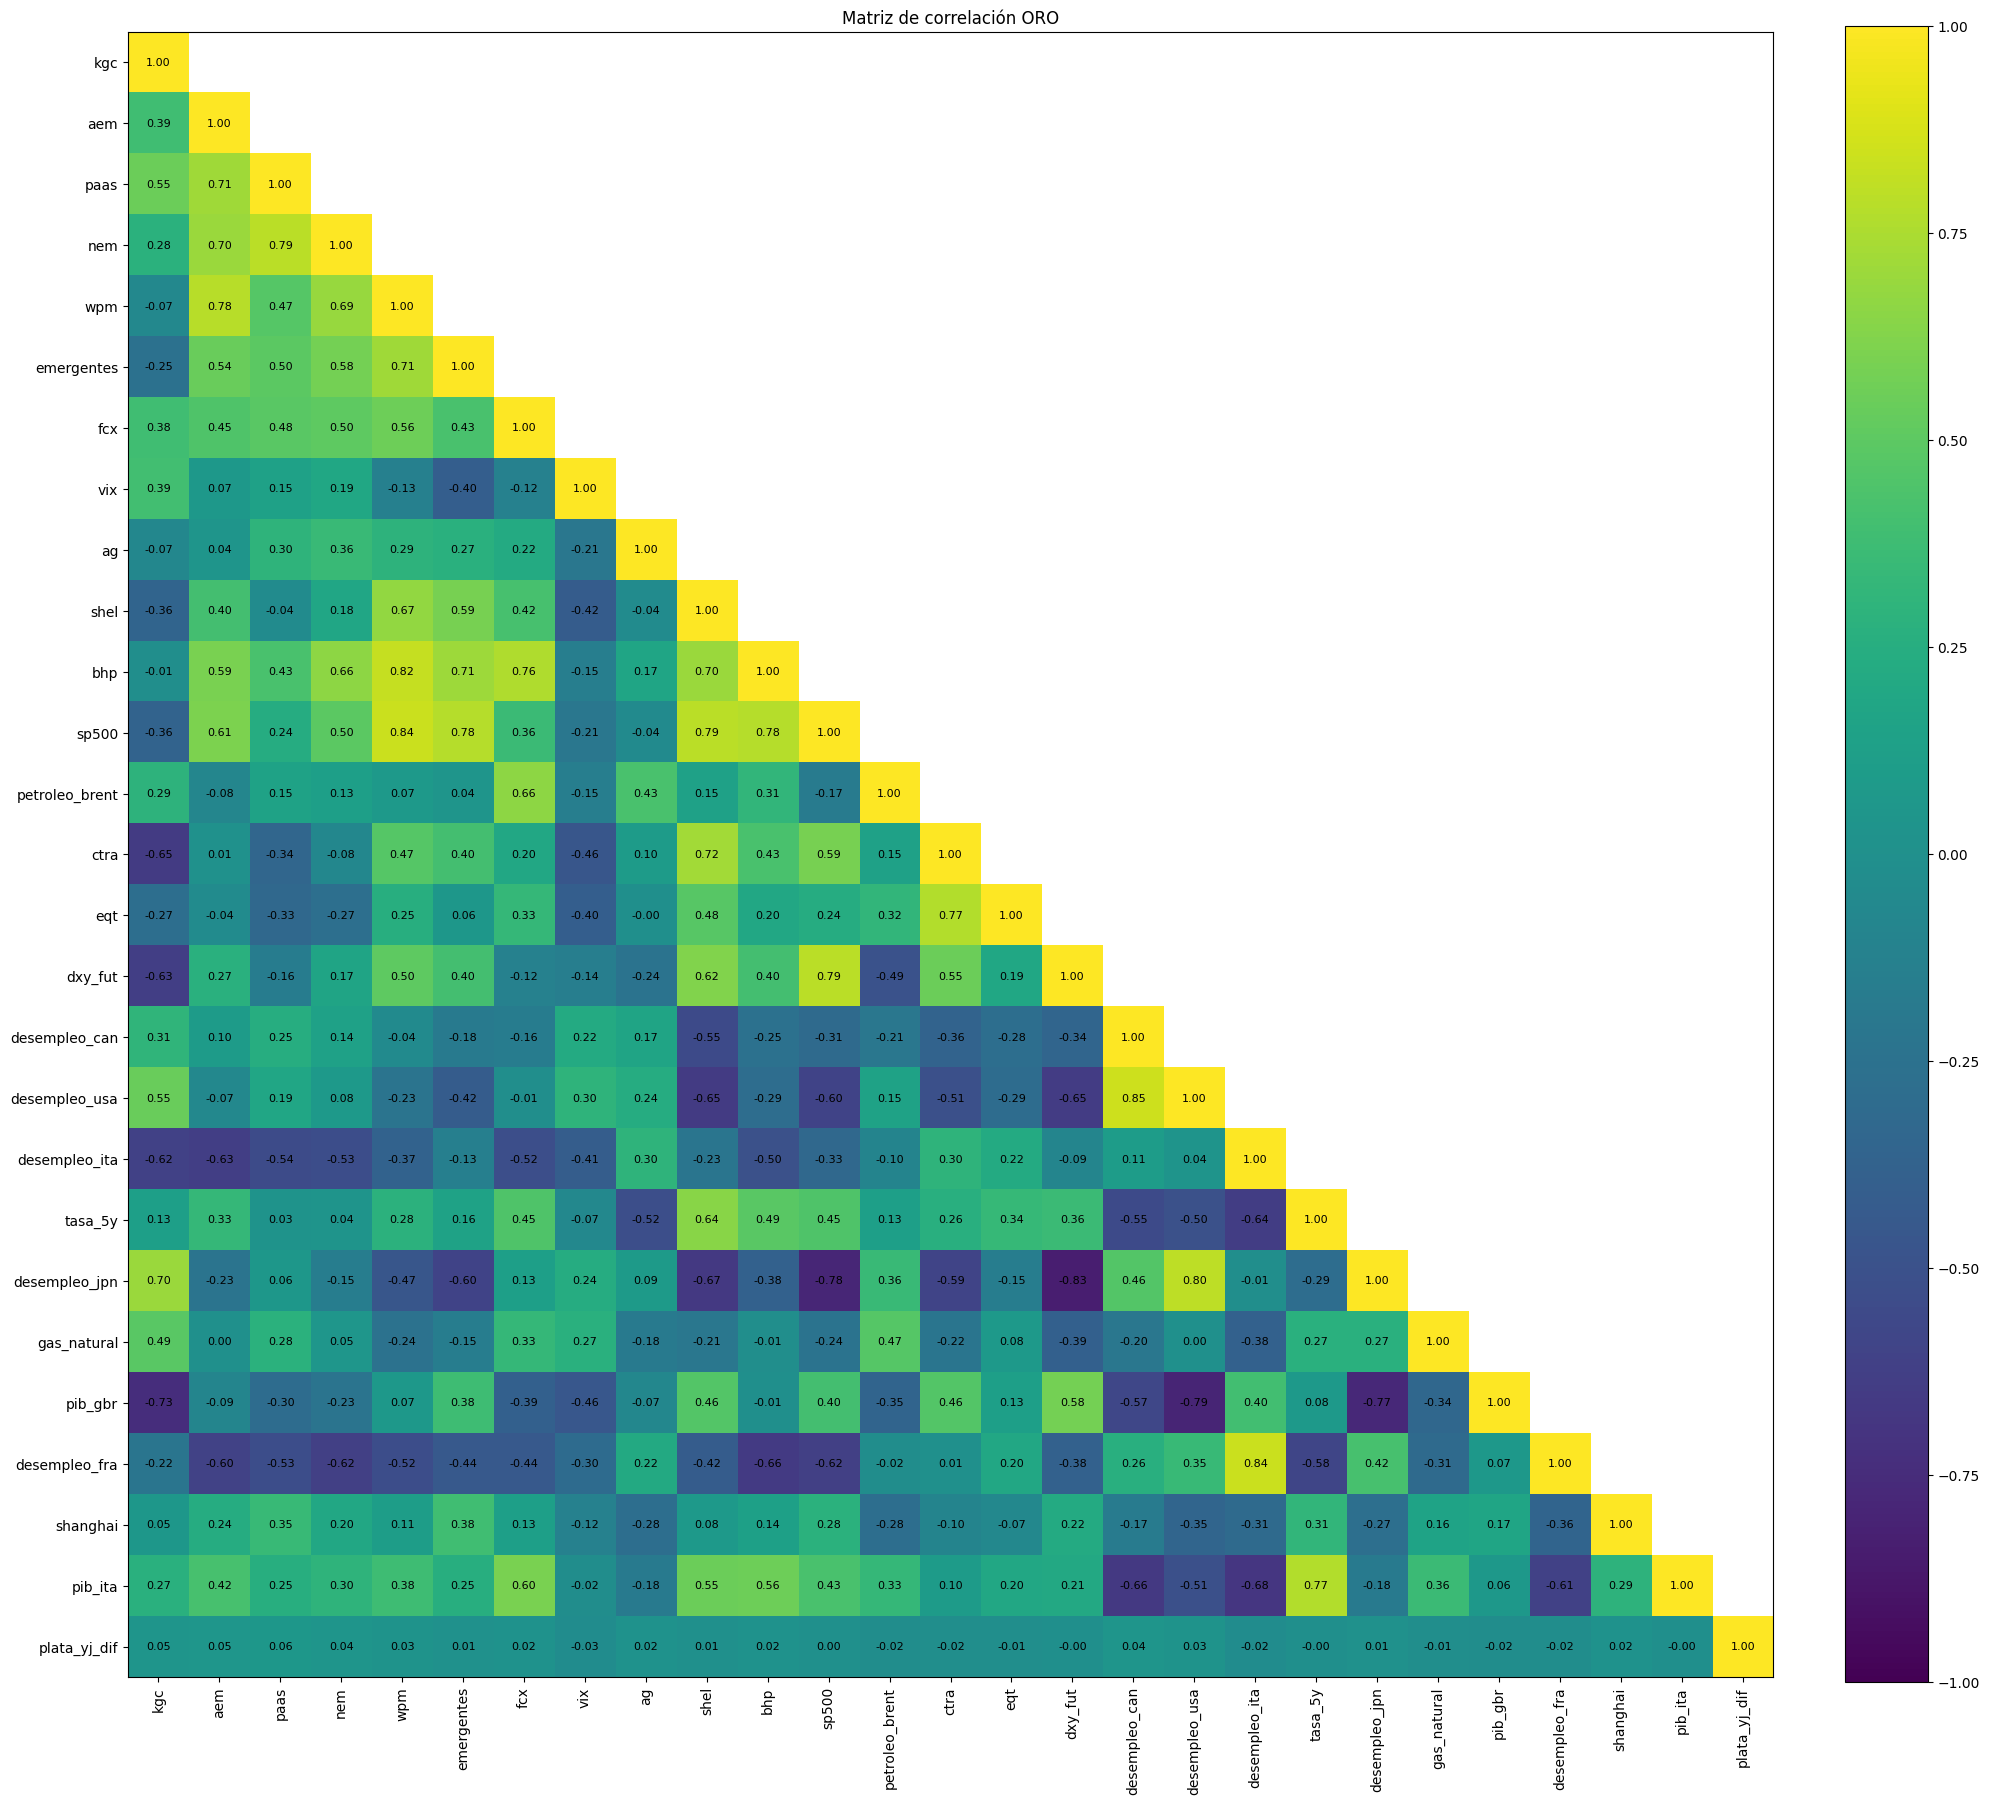

In [45]:
num_cols = (
    df_plata_final.drop(columns="plata_yj")
    .select_dtypes(include="number")
    .drop(columns=["fecha"], errors="ignore")
)

corr = num_cols.corr()

M = corr.values.copy()
mask = np.triu(np.ones_like(M, dtype=bool), k=1)
M_masked = M.copy()
M_masked[mask] = np.nan

plt.figure(figsize=(20, 20))
im = plt.imshow(M_masked, vmin=-1, vmax=1)  # sin cmap explícito
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)

for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        if not mask[i, j] and not np.isnan(M_masked[i, j]):
            plt.text(j, i, f"{M[i, j]:.2f}", ha="center", va="center", fontsize=8)

plt.title("Matriz de correlación ORO")
plt.tight_layout()
plt.show()

## Test de Causalidad de Granger

In [46]:
exclude_cols = ["plata","plata_yj"]
features = df_oro_final.drop(columns=exclude_cols, errors="ignore").select_dtypes(include=['float64', 'int64']).columns

max_lag = 7
results = []

for col in features:
    try:
        data = df_plata_final[[col, "plata_yj_dif"]].dropna()
        
        if len(data) > max_lag + 1:
            test = grangercausalitytests(data[["plata_yj_dif", col]], max_lag, verbose=False)
            row = {'Feature': col}
            for lag in range(1, max_lag + 1):
                p_val = test[lag][0]['ssr_ftest'][1]
                row[f'P_Value_Lag{lag}'] = p_val
                row[f'Significant_Lag{lag}'] = p_val < 0.05
            
            results.append(row)
    except:
        continue
granger_df = pd.DataFrame(results)
granger_df['Min_P_Value'] = granger_df[['P_Value_Lag1', 'P_Value_Lag2', 'P_Value_Lag3']].min(axis=1)
granger_df_plata = granger_df.sort_values('Min_P_Value').reset_index(drop=True)

granger_df_plata.head(40)

,Feature,P_Value_Lag1,Significant_Lag1,P_Value_Lag2,Significant_Lag2,P_Value_Lag3,Significant_Lag3,P_Value_Lag4,Significant_Lag4,P_Value_Lag5,Significant_Lag5,P_Value_Lag6,Significant_Lag6,P_Value_Lag7,Significant_Lag7,Min_P_Value
0,kgc,0.204014,False,0.000000,True,0.000000,True,0.000000,True,0.000000,True,0.000000,True,0.000000,True,0.000000
1,aem,0.236048,False,0.000000,True,0.000000,True,0.000000,True,0.000000,True,0.000000,True,0.000000,True,0.000000
2,paas,0.664755,False,0.000000,True,0.000000,True,0.000000,True,0.000000,True,0.000000,True,0.000000,True,0.000000
3,nem,0.646004,False,0.000000,True,0.000000,True,0.000000,True,0.000000,True,0.000000,True,0.000000,True,0.000000
4,wpm,0.810828,False,0.000000,True,0.000000,True,0.000000,True,0.000000,True,0.000000,True,0.000000,True,0.000000
5,emergentes,0.685513,False,0.000000,True,0.000000,True,0.000000,True,0.000000,True,0.000000,True,0.000000,True,0.000000
6,fcx,0.795681,False,0.000000,True,0.000000,True,0.000000,True,0.000000,True,0.000000,True,0.000000,True,0.000000
7,vix,0.937305,False,0.000000,True,0.000000,True,0.000000,True,0.000000,True,0.000000,True,0.000000,True,0.000000
8,ag,0.262735,False,0.000000,True,0.000000,True,0.000000,True,0.000000,True,0.000000,True,0.000000,True,0.000000
9,shel,0.682766,False,0.000000,True,0.000000,True,0.000000,True,0.000000,True,0.000000,True,0.000000,True,0.000000


In [47]:
sig_cols = [c for c in granger_df_plata.columns if c.lower().startswith('significant_lag')]
granger_df_plata["granger_test"] = granger_df_plata[sig_cols].any(axis=1).astype(int) 

granger_df_plata=list(granger_df_plata[granger_df_plata["granger_test"]==1]["Feature"])+["plata_yj"]
df_plata_final=df_plata_final[granger_df_plata]

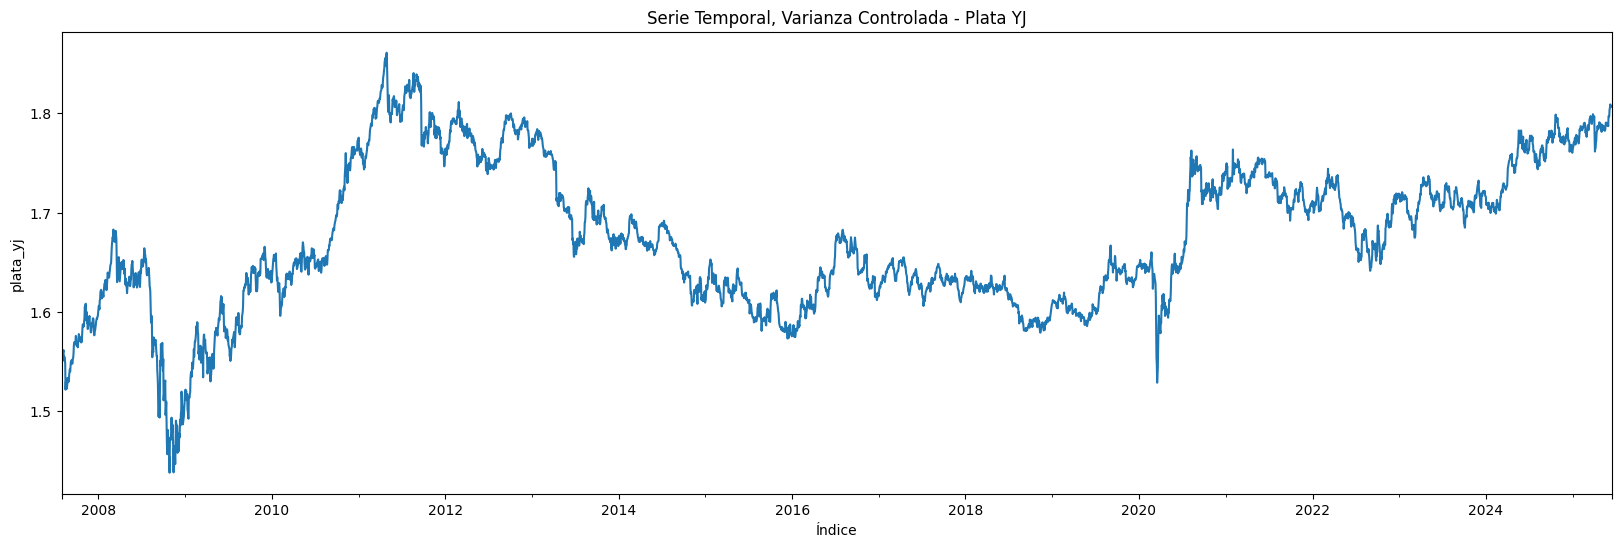

In [48]:
df_plata_final['plata_yj'].plot(figsize=(20,6))
plt.xlabel('Índice')
plt.ylabel('plata_yj')
plt.title('Serie Temporal, Varianza Controlada - Plata YJ')
plt.show()

* Claramente tiene componentes estacionales, la gráfica se tiende a repetir --> parece ser que tiene un comportamiento similar durante 2 años cada 10 años

## Análisis del Cobre

### Test de Shapiro - Wilk

In [49]:
df_cobre=df_train.copy()
# === TEST DE SHAPIRO-WILK ===
print("=" * 70)
print("TEST DE SHAPIRO-WILK (Normalidad)")
print("=" * 70)
shapiro_stat, shapiro_p = stats.shapiro(df_cobre['cobre'].dropna())
print(f"Shapiro Statistic: {shapiro_stat:.4f}")
print(f"p-value: {shapiro_p:.4f}")
if shapiro_p > 0.05:
    print("H0: No se rechaza - distribución normal")
    
else:
    print("H0: Se rechaza hipotesis nula - datos no presentan distribución normal")

TEST DE SHAPIRO-WILK (Normalidad)
Shapiro Statistic: 0.9923
p-value: 0.0000
H0: Se rechaza hipotesis nula - datos no presentan distribución normal


## Trnasformación de Boxcox

In [50]:
transformacion, lambda_opt_cobre = boxcox(df_cobre['cobre'])
print(f"Lambda óptimo: {lambda_opt_cobre:.4f}") 

Lambda óptimo: 0.9855


In [51]:
df_cobre['cobre_yj'] = yeojohnson(df_cobre['cobre'], lmbda=lambda_opt_cobre)

## Análisis de Descomposición

El modelo multiplicativo es más adecuado (CV menor).


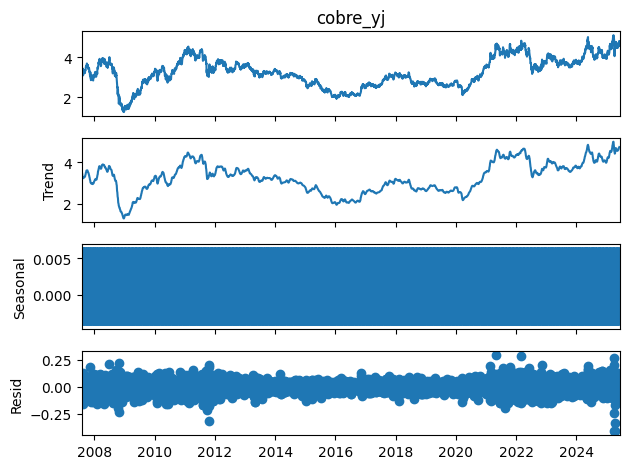

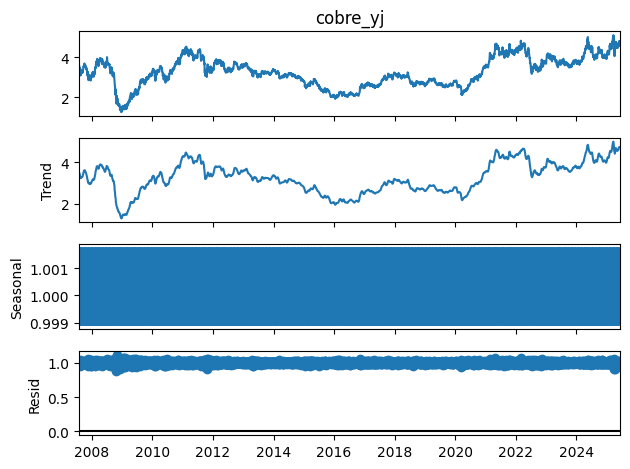

In [52]:
decompose_add = seasonal_decompose(df_cobre['cobre_yj'] , model='additive', period=12)
decompose_mult = seasonal_decompose(df_cobre['cobre_yj'] , model='multiplicative', period=12)

decompose_add.plot()
decompose_mult.plot()


seasonal_add = decompose_add.seasonal
seasonal_mult = decompose_mult.seasonal

cv_add = variation(seasonal_add.dropna())
cv_mult = variation(seasonal_mult.dropna()) 
if cv_add < cv_mult:
    print("El modelo aditivo es más adecuado (CV menor).")
elif cv_add > cv_mult:
    print("El modelo multiplicativo es más adecuado (CV menor).")
else:
    print("Ambos modelos tienen el mismo CV.")

### Analisis de ADF - KPSS

In [53]:
series_to_test = df_cobre['cobre_yj'].dropna()

#ADF
adf_stat, adf_pval, adf_lags, adf_nobs, adf_crit, _ = adfuller(series_to_test)
print(f"ADF Statistic : {adf_stat:.4f}")
print(f"ADF p-value   : {adf_pval:.4g}")
print("»", "Estacionaria" if adf_pval < 0.05 else "NO estacionaria", "según ADF")

#KPSS
kpss_stat, kpss_pval, kpss_lags, kpss_crit = kpss(series_to_test, regression='c', nlags="auto")
print(f"KPSS Statistic: {kpss_stat:.4f}")
print(f"KPSS p-value  : {kpss_pval:.4g}")
print("»", "Estacionaria" if kpss_pval > 0.05 else "NO estacionaria", "según KPSS")

tests_df = pd.DataFrame([
    {
        "serie": "cobre_yj",
        "test": "ADF",
        "stat": adf_stat,
        "p_value": adf_pval,
        "lags_usados": adf_lags,
        "n_observaciones": adf_nobs,
        "crit_1%": adf_crit.get("1%"),
        "crit_5%": adf_crit.get("5%"),
        "crit_10%": adf_crit.get("10%"),
        "estacionaria": adf_pval < 0.05  # criterio ADF
    },
    {
        "serie": "cobre_yj",
        "test": "KPSS (c)",
        "stat": kpss_stat,
        "p_value": kpss_pval,
        "lags_usados": kpss_lags,
        "n_observaciones": series_to_test.shape[0],
        "crit_1%": float(kpss_crit.get("1%")),
        "crit_5%": float(kpss_crit.get("5%")),
        "crit_10%": float(kpss_crit.get("10%")),
        "estacionaria": kpss_pval > 0.05  # criterio KPSS
    }
])

ts_tests_mensual = tests_df

print(ts_tests_mensual)

ADF Statistic : -1.9682
ADF p-value   : 0.3007
» NO estacionaria según ADF
KPSS Statistic: 2.1257
KPSS p-value  : 0.01
» NO estacionaria según KPSS
      serie      test      stat  p_value  lags_usados  n_observaciones  \
0  cobre_yj       ADF -1.968216 0.300681            0             4664   
1  cobre_yj  KPSS (c)  2.125691 0.010000           41             4665   

    crit_1%   crit_5%  crit_10%  estacionaria  
0 -3.431753 -2.862160 -2.567100         False  
1  0.739000  0.463000  0.347000         False  


* Producto de no representar comportamiento estacionario en ADF ni KPSS, Se opta por diferenciar

In [54]:
df_cobre['cobre_yj_dif']=df_cobre['cobre_yj'].diff() 
df_cobre=df_cobre.dropna(subset="cobre_yj_dif")

In [55]:
series_to_test_dif = df_cobre['cobre_yj_dif'].dropna()

#ADF
adf_stat_dif, adf_pval_dif, adf_lags_dif, adf_nobs_dif, adf_crit_dif, _ = adfuller(series_to_test_dif)
print(f"ADF Statistic : {adf_stat_dif:.4f}")
print(f"ADF p-value   : {adf_pval_dif:.4g}")
print("»", "Estacionaria" if adf_pval_dif < 0.05 else "NO estacionaria", "según ADF")

#KPSS
kpss_stat_dif, kpss_pval_dif, kpss_lags_dif, kpss_crit_dif = kpss(series_to_test_dif, regression='c', nlags="auto")
print(f"KPSS Statistic: {kpss_stat_dif:.4f}")
print(f"KPSS p-value  : {kpss_pval_dif:.4g}")
print("»", "Estacionaria" if kpss_pval_dif > 0.05 else "NO estacionaria", "según KPSS")

tests_df_dif = pd.DataFrame([
    {
        "serie": "Cobre YJ diferenciado",
        "test": "ADF",
        "stat": adf_stat_dif,
        "p_value": adf_pval_dif,
        "lags_usados": adf_lags_dif,
        "n_observaciones": adf_nobs_dif,
        "crit_1%": adf_crit_dif.get("1%"),
        "crit_5%": adf_crit_dif.get("5%"),
        "crit_10%": adf_crit_dif.get("10%"),
        "estacionaria": adf_pval_dif < 0.05  # criterio ADF
    },
    {
        "serie": "Cobre YJ diferenciado",
        "test": "KPSS (c)",
        "stat": kpss_stat_dif,
        "p_value": kpss_pval_dif,
        "lags_usados": kpss_lags_dif,
        "n_observaciones": series_to_test_dif.shape[0],
        "crit_1%": float(kpss_crit_dif.get("1%")),
        "crit_5%": float(kpss_crit_dif.get("5%")),
        "crit_10%": float(kpss_crit_dif.get("10%")),
        "estacionaria": kpss_pval_dif > 0.05  # criterio KPSS
    }
])

ts_tests_mensual_dif = tests_df_dif

print(ts_tests_mensual_dif)

ADF Statistic : -69.5695
ADF p-value   : 0
» Estacionaria según ADF
KPSS Statistic: 0.1087
KPSS p-value  : 0.1
» Estacionaria según KPSS
                   serie      test       stat  p_value  lags_usados  \
0  Cobre YJ diferenciado       ADF -69.569492 0.000000            0   
1  Cobre YJ diferenciado  KPSS (c)   0.108728 0.100000            8   

   n_observaciones   crit_1%   crit_5%  crit_10%  estacionaria  
0             4663 -3.431753 -2.862160 -2.567100          True  
1             4664  0.739000  0.463000  0.347000          True  


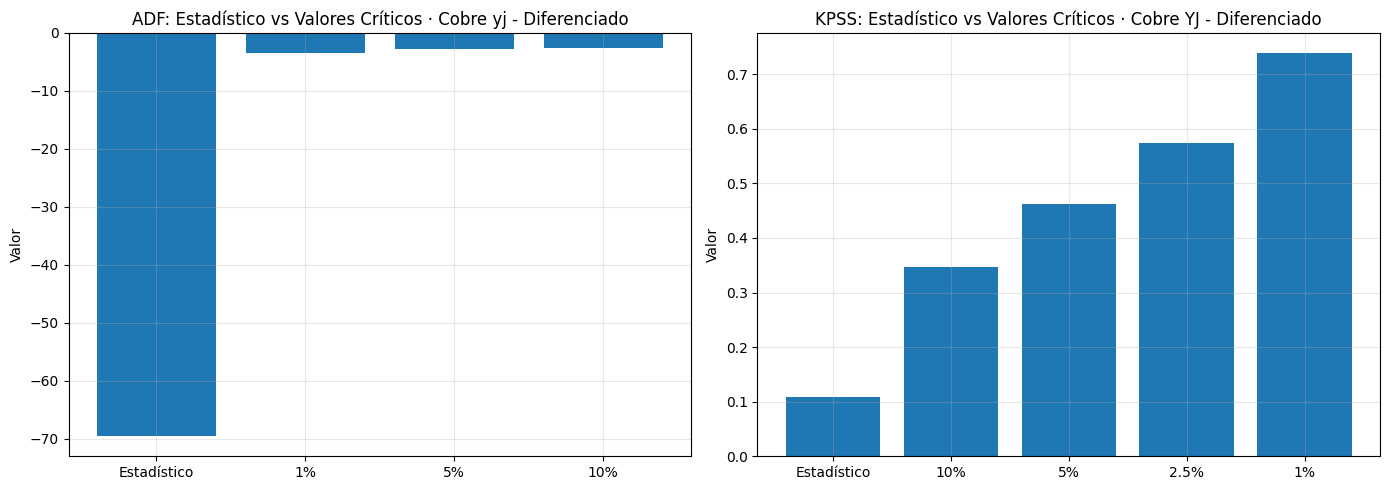

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ADF
axes[0].bar(['Estadístico'] + list(adf_crit_dif.keys()),
            [adf_stat_dif] + list(adf_crit_dif.values()))
axes[0].set_title("ADF: Estadístico vs Valores Críticos · Cobre yj - Diferenciado")
axes[0].set_ylabel("Valor"); axes[0].grid(alpha=.3)

# KPSS
axes[1].bar(['Estadístico'] + list(kpss_crit_dif.keys()),
            [kpss_stat_dif] + [float(k) for k in kpss_crit_dif.values()])
axes[1].set_title("KPSS: Estadístico vs Valores Críticos · Cobre YJ - Diferenciado")
axes[1].set_ylabel("Valor"); axes[1].grid(alpha=.3)

plt.tight_layout(); plt.show()

## Gráfica de Normalidad - Cobre diferenciado

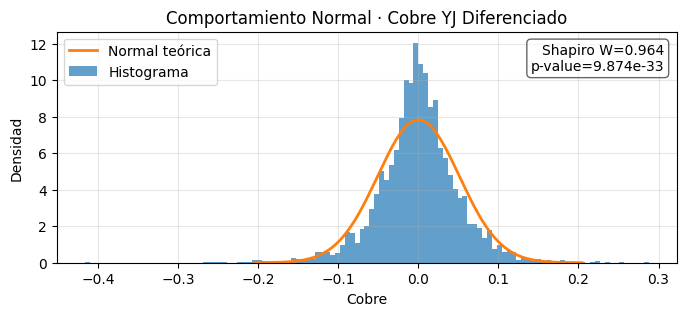

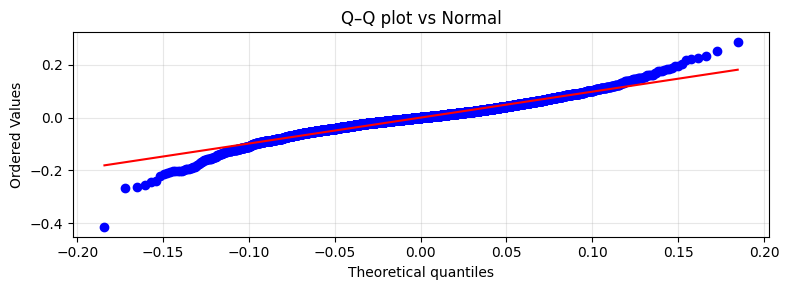

In [57]:
y = df_cobre['cobre_yj_dif']
sh_stat, sh_p = stats.shapiro(y)

mu, sigma = np.mean(y), np.std(y, ddof=1)
xs = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)

#hist + curva teorica
plt.figure(figsize=(8,3))
plt.hist(y, bins='auto', density=True, alpha=0.7)
plt.plot(xs, stats.norm.pdf(xs, mu, sigma), linewidth=2)
plt.title("Comportamiento Normal · Cobre YJ Diferenciado")
plt.xlabel("Cobre")
plt.ylabel("Densidad")
plt.grid(alpha=.3)
plt.legend(["Normal teórica", "Histograma"], loc="best")
plt.annotate(f"Shapiro W={sh_stat:.3f}\np-value={sh_p:.4g}",
             xy=(0.98, 0.95), xycoords="axes fraction",
             ha="right", va="top",
             bbox=dict(boxstyle="round", fc="white", alpha=0.6))

# --- Q–Q plot ---
plt.figure(figsize=(8,3))
# Usamos la normal con media y sigma estimados
stats.probplot(y, dist="norm", sparams=(mu, sigma), plot=plt)
plt.title("Q–Q plot vs Normal")
plt.grid(alpha=.3)

plt.tight_layout()
plt.show()

## ADF Y PACF - Cobre Diferenciado

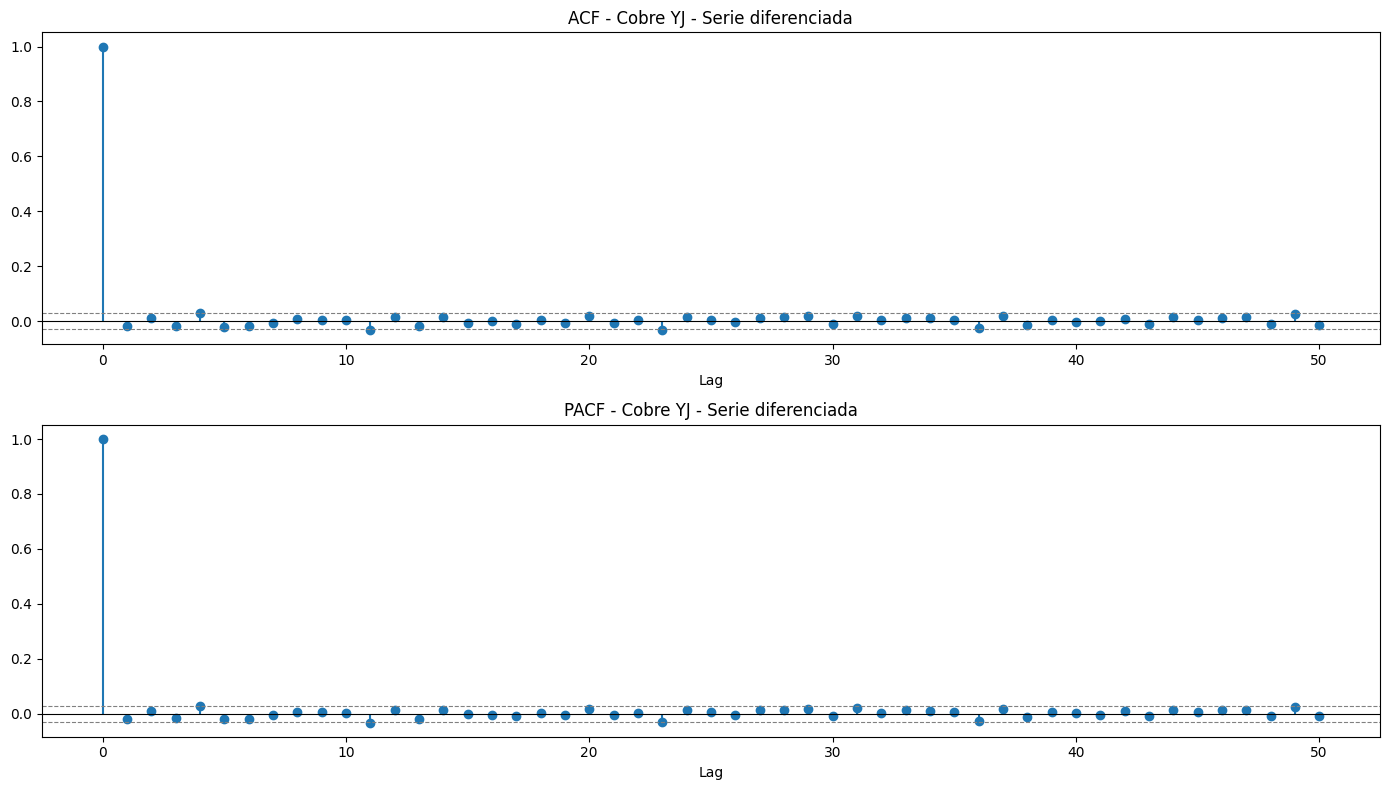

In [58]:
n = len(df_cobre)
nlags_acf  = min(50, n-1)
nlags_pacf = min(50, n-1)

pacf_monthly = pacf(df_cobre["cobre_yj_dif"], nlags=nlags_pacf, method='ywmle')
acf_monthly = acf(df_cobre["cobre_yj_dif"], nlags=nlags_acf)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
conf = 1.96 / np.sqrt(n)

axes[0].stem(range(len(acf_monthly)), acf_monthly, basefmt=' ')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].axhline(conf, linestyle='--', color='gray', linewidth=0.8)
axes[0].axhline(-conf, linestyle='--', color='gray', linewidth=0.8)
axes[0].set_title('ACF - Cobre YJ - Serie diferenciada')
axes[0].set_xlabel('Lag')

axes[1].stem(range(len(pacf_monthly)), pacf_monthly, basefmt=' ')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].axhline(conf, linestyle='--', color='gray', linewidth=0.8)
axes[1].axhline(-conf, linestyle='--', color='gray', linewidth=0.8)
axes[1].set_title('PACF - Cobre YJ - Serie diferenciada')
axes[1].set_xlabel('Lag')

plt.tight_layout()
plt.show()

- p = AR = [0,1] --> Podria presentar un Componente Autoregresivo
- d = [1] 
- q = [0]
- Poca claridad para definir componentes MA no estacionales → probar entre 0 y 1
- s (estacionalidad):No se ve comportamiento definido, probar con s=0 o s=5
- P (AR estacional):No se aprecian con claridad componentes autoregresivos estacionales en el PACF → probar P = [0] o máximo 1
- D=[0] --> ya logramos estacionalidad
- Q (MA estacional) --> no se ve ningun shock importante en pacf, por lo que se dejara entre [0] máximo 1. 

* Tiene más parecido a un de un arimax-arima que un sarima/sarimax

## Análisis de Colinealidad basado en Granger

In [59]:
target = "cobre_yj_dif"
num_cols = df_cobre.select_dtypes(include=[np.number]).columns.drop(target, errors="ignore")

#Calcular Granger F para todas
granger_scores = []
for col in num_cols:
    data = df_cobre[[target, col]].dropna()
    if len(data) < 10:
        continue
    try:
        results = grangercausalitytests(data, maxlag=3, verbose=False)
        #Máximo F-stat entre todos los lags
        max_f = max([results[lag][0]['ssr_ftest'][0] for lag in results.keys()])
        granger_scores.append({'variable': col, 'Granger_F': max_f})
    except:
        continue

granger_df = pd.DataFrame(granger_scores).sort_values('Granger_F', ascending=False)

#Eliminar multicolinealidad (corr > 0.85)
vars_list = granger_df['variable'].tolist()
corr_matrix = df_cobre[vars_list].corr()

variables_a_eliminar = set()
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.85:
            var1, var2 = corr_matrix.columns[i], corr_matrix.columns[j]
            f1 = granger_df[granger_df['variable'] == var1]['Granger_F'].values[0]
            f2 = granger_df[granger_df['variable'] == var2]['Granger_F'].values[0]
            
            #Eliminar la de MENOR Granger F (peor causalidad)
            variables_a_eliminar.add(var2 if f1 > f2 else var1)

top = granger_df[~granger_df['variable'].isin(variables_a_eliminar)] 
lista_variables_cobre=top['variable'].tolist()+list([target]+['cobre_yj'])
lista_variables_cobre_test=top['variable'].tolist()+['cobre_yj']
         
top

,variable,Granger_F
32,fcx,64.797759
28,bhp,34.564283
10,sp500,30.381041
7,emergentes,30.180314
12,vix,20.481036
35,nem,19.889284
31,eqt,14.548859
26,aem,13.552718
38,shel,12.755812
36,paas,12.277695


In [60]:
df_cobre_final=df_cobre[lista_variables_cobre]

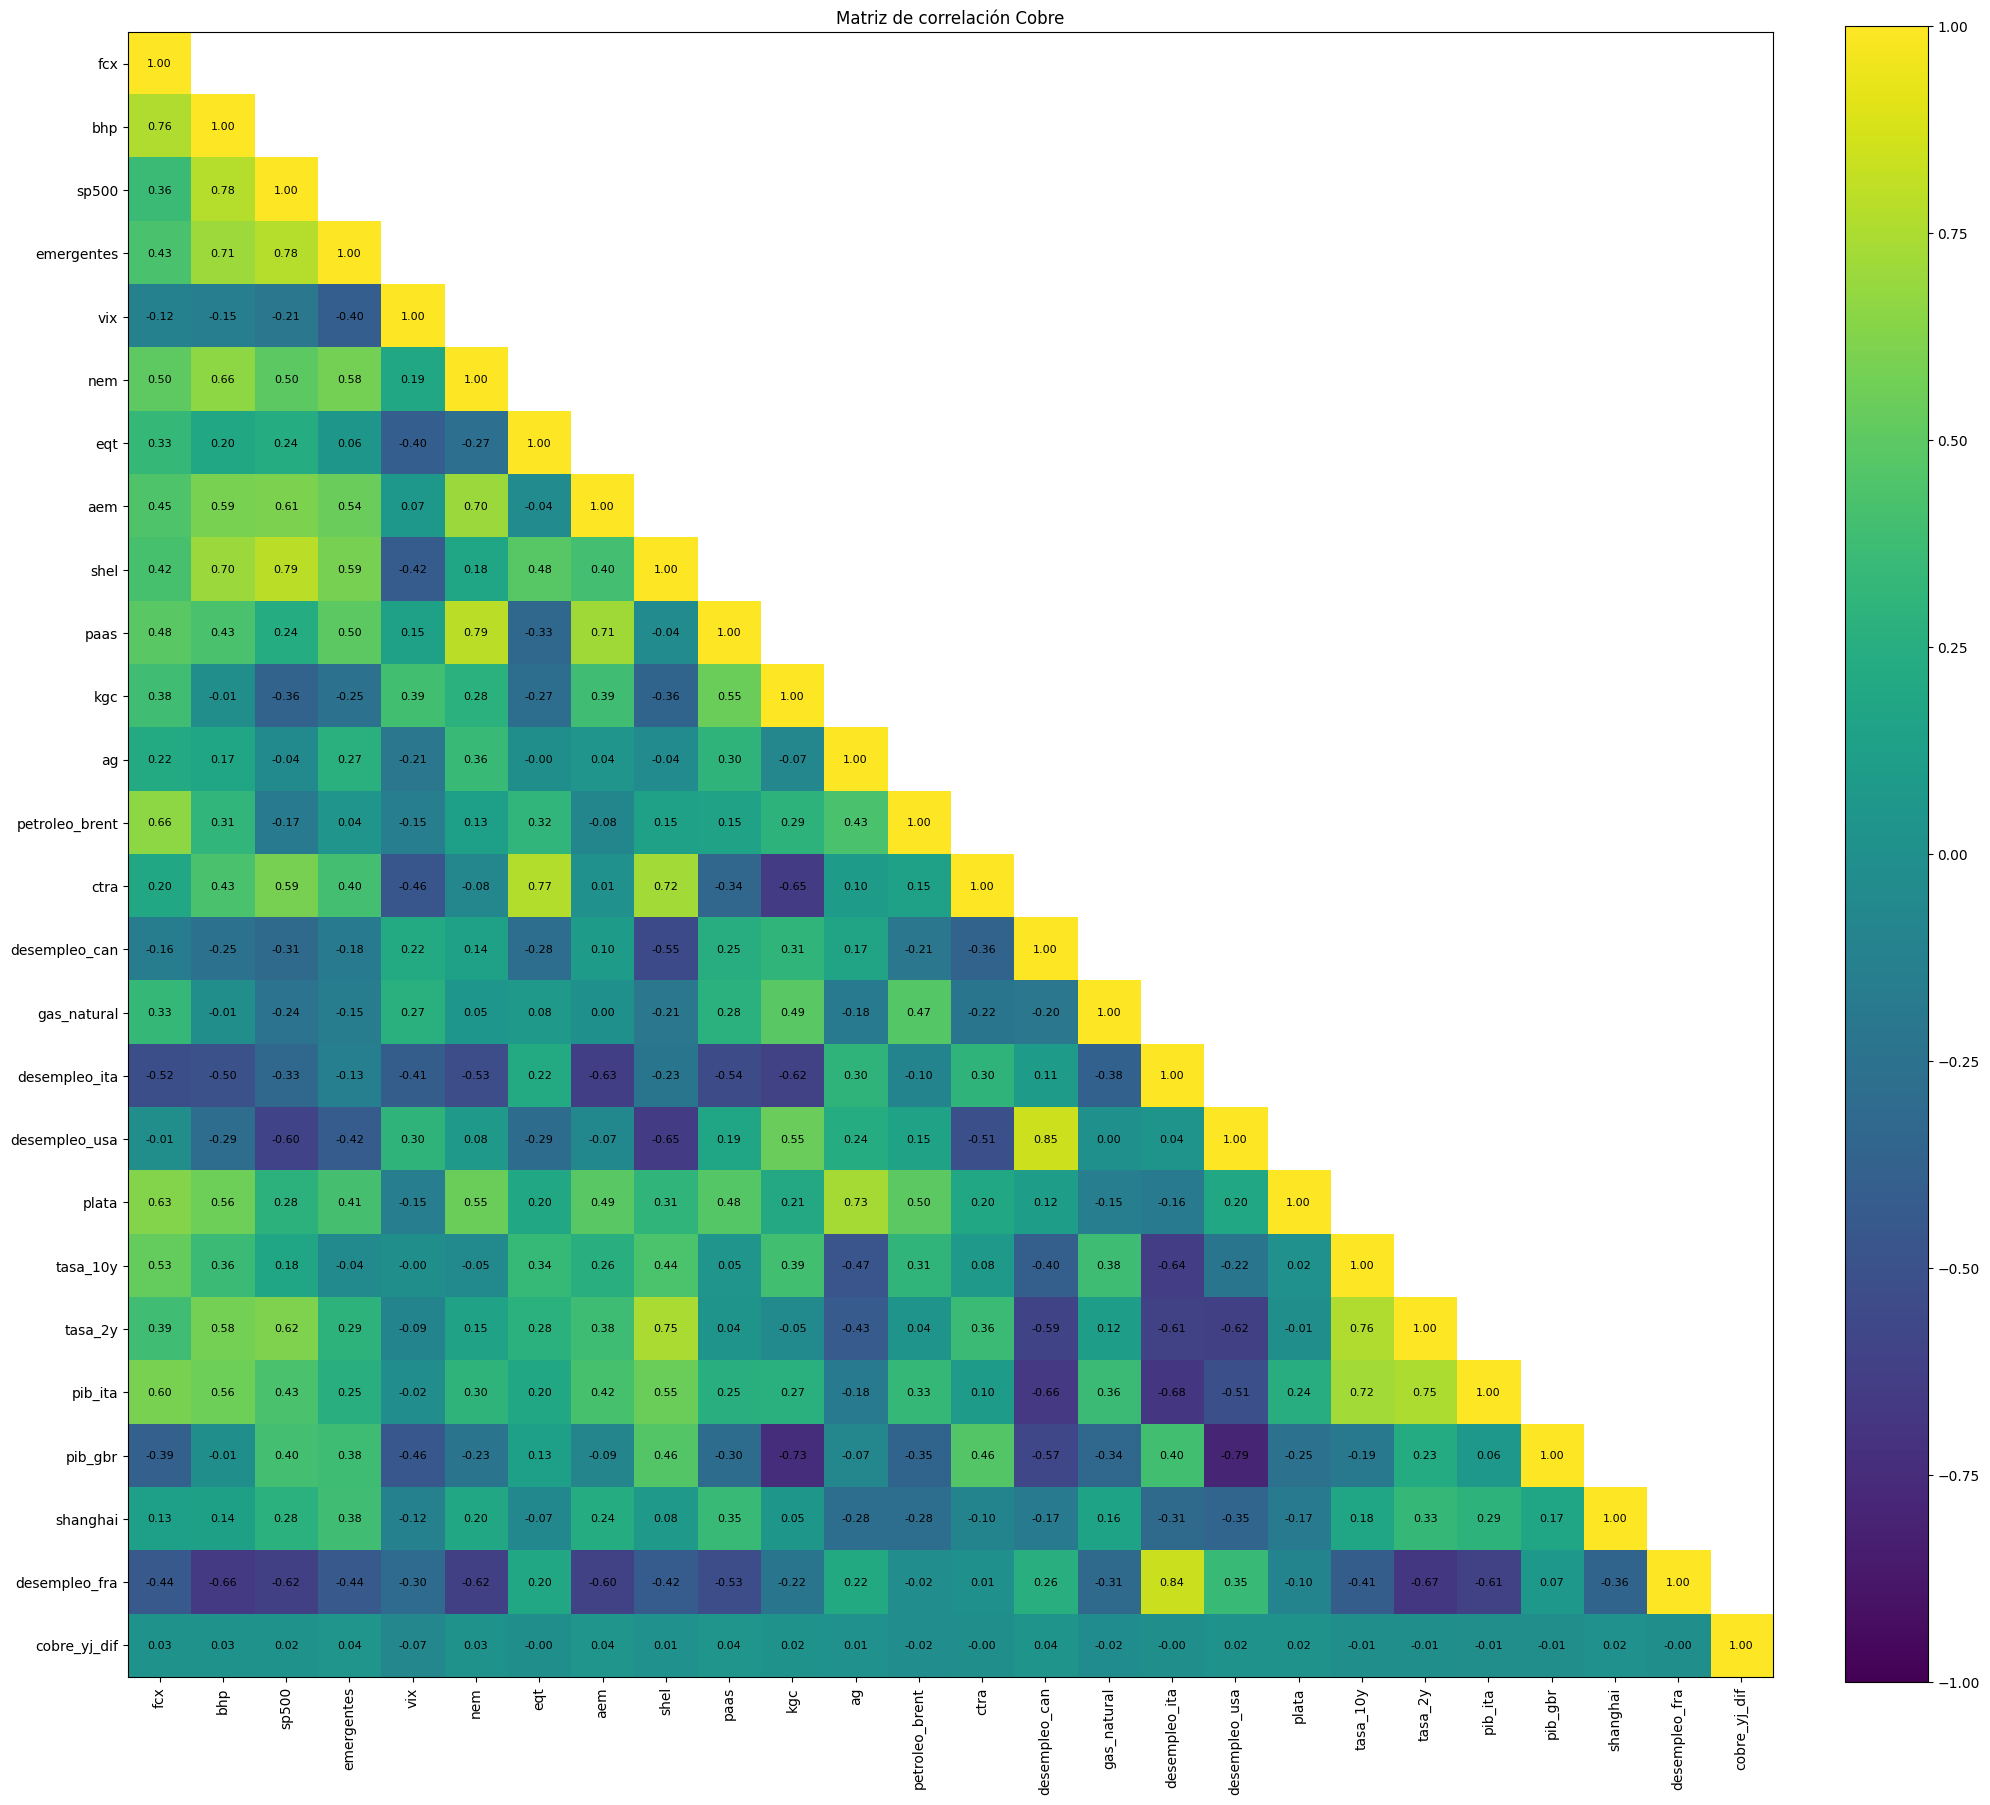

In [61]:
num_cols = (
    df_cobre_final.drop(columns=["cobre_yj"])
    .select_dtypes(include="number")
    .drop(columns=["fecha"], errors="ignore")
)

corr = num_cols.corr()

M = corr.values.copy()
mask = np.triu(np.ones_like(M, dtype=bool), k=1)
M_masked = M.copy()
M_masked[mask] = np.nan

plt.figure(figsize=(20, 20))
im = plt.imshow(M_masked, vmin=-1, vmax=1)  # sin cmap explícito
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)

for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        if not mask[i, j] and not np.isnan(M_masked[i, j]):
            plt.text(j, i, f"{M[i, j]:.2f}", ha="center", va="center", fontsize=8)

plt.title("Matriz de correlación Cobre")
plt.tight_layout()
plt.show()

## Test de Causalidad de Granger

In [62]:
exclude_cols = ["cobre_yj"]
features = df_cobre_final.drop(columns=exclude_cols, errors="ignore").select_dtypes(include=['float64', 'int64']).columns

max_lag = 7
results = []

for col in features:
    try:
        data = df_cobre_final[[col, "cobre_yj_dif"]].dropna()
        
        if len(data) > max_lag + 1:
            test = grangercausalitytests(data[["cobre_yj_dif", col]], max_lag, verbose=False)
            row = {'Feature': col}
            for lag in range(1, max_lag + 1):
                p_val = test[lag][0]['ssr_ftest'][1]
                row[f'P_Value_Lag{lag}'] = p_val
                row[f'Significant_Lag{lag}'] = p_val < 0.05
            
            results.append(row)
    except:
        continue
granger_df = pd.DataFrame(results)
granger_df['Min_P_Value'] = granger_df[['P_Value_Lag1', 'P_Value_Lag2', 'P_Value_Lag3']].min(axis=1)
granger_df_cobre = granger_df.sort_values('Min_P_Value').reset_index(drop=True)

granger_df_cobre.head(40)

,Feature,P_Value_Lag1,Significant_Lag1,P_Value_Lag2,Significant_Lag2,P_Value_Lag3,Significant_Lag3,P_Value_Lag4,Significant_Lag4,P_Value_Lag5,Significant_Lag5,P_Value_Lag6,Significant_Lag6,P_Value_Lag7,Significant_Lag7,Min_P_Value
0,fcx,0.627216,False,0.000000,True,0.000000,True,0.000000,True,0.000000,True,0.000000,True,0.000000,True,0.000000
1,bhp,0.928702,False,0.000000,True,0.000000,True,0.000000,True,0.000000,True,0.000000,True,0.000000,True,0.000000
2,emergentes,0.423953,False,0.000000,True,0.000000,True,0.000000,True,0.000000,True,0.000000,True,0.000000,True,0.000000
3,sp500,0.407422,False,0.000000,True,0.000000,True,0.000000,True,0.000000,True,0.000000,True,0.000000,True,0.000000
4,vix,0.189705,False,0.000000,True,0.000000,True,0.000000,True,0.000000,True,0.000000,True,0.000000,True,0.000000
5,nem,0.418992,False,0.000000,True,0.000000,True,0.000000,True,0.000000,True,0.000000,True,0.000000,True,0.000000
6,eqt,0.264446,False,0.000001,True,0.000001,True,0.000001,True,0.000003,True,0.000002,True,0.000004,True,0.000001
7,aem,0.115779,False,0.000001,True,0.000004,True,0.000005,True,0.000003,True,0.000000,True,0.000000,True,0.000001
8,shel,0.529626,False,0.000003,True,0.000011,True,0.000023,True,0.000057,True,0.000152,True,0.000344,True,0.000003
9,paas,0.425994,False,0.000005,True,0.000013,True,0.000037,True,0.000096,True,0.000026,True,0.000028,True,0.000005


In [63]:
sig_cols = [c for c in granger_df.columns if c.lower().startswith('significant_lag')]
granger_df_cobre["granger_test"] = granger_df_cobre[sig_cols].any(axis=1).astype(int) 

granger_df_cobre=list(granger_df_cobre[granger_df_cobre["granger_test"]==1]["Feature"])+["cobre_yj"]
df_cobre_final=df_cobre_final[granger_df_cobre]

# Comportamiento Historico

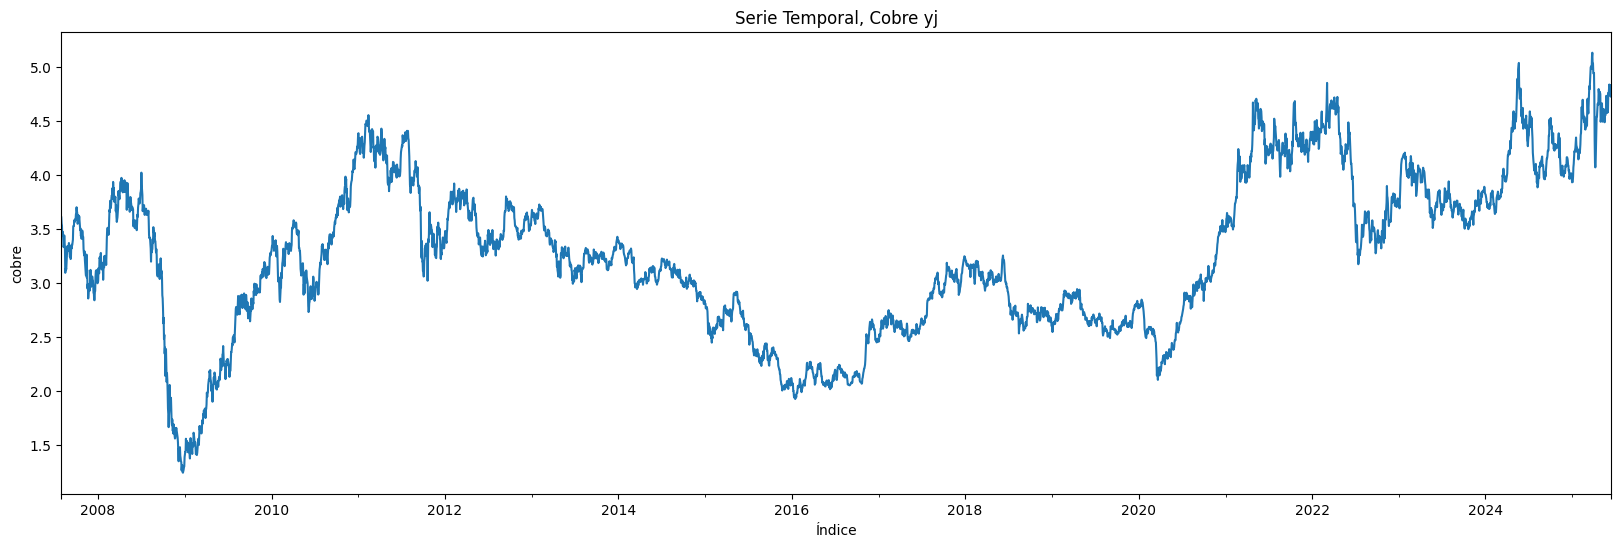

In [64]:
df_cobre_final['cobre_yj'].plot(figsize=(20,6))
plt.xlabel('Índice')
plt.ylabel('cobre')
plt.title('Serie Temporal, Cobre yj')
plt.show()

* Podríamos ver en la gráfica que tiene una cierta simetria entre los periodos, por lo que podría indicar una serie diferenciada estacional

## Análisis de Gas Natural

In [65]:
df_gas_natural=df_train.copy()
# === TEST DE SHAPIRO-WILK ===
print("=" * 70)
print("TEST DE SHAPIRO-WILK (Normalidad)")
print("=" * 70)
shapiro_stat, shapiro_p = stats.shapiro(df_gas_natural['gas_natural'].dropna())
print(f"Shapiro Statistic: {shapiro_stat:.4f}")
print(f"p-value: {shapiro_p:.4f}")
if shapiro_p > 0.05:
    print("H0: No se rechaza - distribución normal")
    
else:
    print("H0: Se rechaza hipotesis nula - datos no presentan distribución normal")

TEST DE SHAPIRO-WILK (Normalidad)
Shapiro Statistic: 0.7984
p-value: 0.0000
H0: Se rechaza hipotesis nula - datos no presentan distribución normal


Los datos del gas no presentan una distribución normal, por lo que se opta a realizar una transformación y así que funcionen en modelos de la familia SARIMA

### Test de BOXOCOX

In [66]:
transformacion, lambda_opt = boxcox(df_gas_natural['gas_natural'])
print(f"Lambda óptimo: {lambda_opt:.4f}")

Lambda óptimo: -0.6623


El lambda al ser negativo, se procede a testear con YEO-JOHNSON

In [67]:
transformacion, lambda_opt_gas_natural = yeojohnson(df_gas_natural['gas_natural'])
print(f"Lambda óptimo: {lambda_opt_gas_natural:.4f}")  

Lambda óptimo: -1.1014


#### Se transforma a escala de YJ para disminuir la varianza y ajustar la seria a un comportamiento normal 

In [68]:
df_gas_natural['gas_natural_yj'] = yeojohnson(df_gas_natural['gas_natural'], lmbda=lambda_opt_gas_natural)

### Análisis de Descomposición

El modelo aditivo es más adecuado (CV menor).


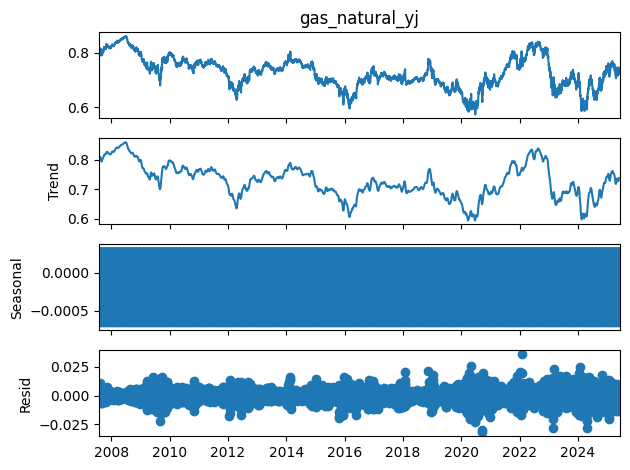

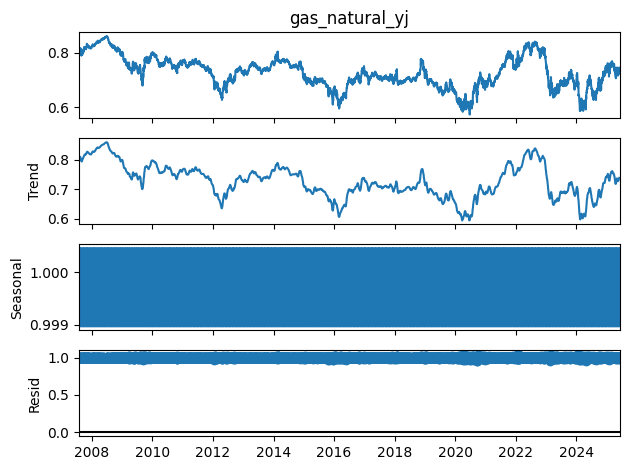

In [69]:
decompose_add = seasonal_decompose(df_gas_natural['gas_natural_yj']  , model='additive', period=12)
decompose_mult = seasonal_decompose(df_gas_natural['gas_natural_yj']  , model='multiplicative', period=12)

decompose_add.plot()
decompose_mult.plot()


seasonal_add = decompose_add.seasonal
seasonal_mult = decompose_mult.seasonal

cv_add = variation(seasonal_add.dropna())
cv_mult = variation(seasonal_mult.dropna()) 
if cv_add < cv_mult:
    print("El modelo aditivo es más adecuado (CV menor).")
elif cv_add > cv_mult:
    print("El modelo multiplicativo es más adecuado (CV menor).")
else:
    print("Ambos modelos tienen el mismo CV.")

In [70]:
series_to_test = df_gas_natural['gas_natural_yj'].dropna()

#ADF
adf_stat, adf_pval, adf_lags, adf_nobs, adf_crit, _ = adfuller(series_to_test)
print(f"ADF Statistic : {adf_stat:.4f}")
print(f"ADF p-value   : {adf_pval:.4g}")
print("»", "Estacionaria" if adf_pval < 0.05 else "NO estacionaria", "según ADF")

#KPSS
kpss_stat, kpss_pval, kpss_lags, kpss_crit = kpss(series_to_test, regression='c', nlags="auto")
print(f"KPSS Statistic: {kpss_stat:.4f}")
print(f"KPSS p-value  : {kpss_pval:.4g}")
print("»", "Estacionaria" if kpss_pval > 0.05 else "NO estacionaria", "según KPSS")

tests_df = pd.DataFrame([
    {
        "serie": "GAS_NARUTAL_YJ",
        "test": "ADF",
        "stat": adf_stat,
        "p_value": adf_pval,
        "lags_usados": adf_lags,
        "n_observaciones": adf_nobs,
        "crit_1%": adf_crit.get("1%"),
        "crit_5%": adf_crit.get("5%"),
        "crit_10%": adf_crit.get("10%"),
        "estacionaria": adf_pval < 0.05  # criterio ADF
    },
    {
        "serie": "GAS_NARUTAL_YJ",
        "test": "KPSS (c)",
        "stat": kpss_stat,
        "p_value": kpss_pval,
        "lags_usados": kpss_lags,
        "n_observaciones": series_to_test.shape[0],
        "crit_1%": float(kpss_crit.get("1%")),
        "crit_5%": float(kpss_crit.get("5%")),
        "crit_10%": float(kpss_crit.get("10%")),
        "estacionaria": kpss_pval > 0.05  # criterio KPSS
    }
])

ts_tests_mensual = tests_df

print(ts_tests_mensual)

ADF Statistic : -3.1508
ADF p-value   : 0.02301
» Estacionaria según ADF
KPSS Statistic: 2.8511
KPSS p-value  : 0.01
» NO estacionaria según KPSS
            serie      test      stat  p_value  lags_usados  n_observaciones  \
0  GAS_NARUTAL_YJ       ADF -3.150817 0.023014           13             4651   
1  GAS_NARUTAL_YJ  KPSS (c)  2.851063 0.010000           41             4665   

    crit_1%   crit_5%  crit_10%  estacionaria  
0 -3.431757 -2.862162 -2.567101          True  
1  0.739000  0.463000  0.347000         False  


In [71]:
df_gas_natural['gas_natural_yj_dif']=df_gas_natural['gas_natural_yj'].diff()
df_gas_natural=df_gas_natural.dropna(subset="gas_natural_yj_dif")

Según nuestro test, en ADF no tiene comportamiento estacionario, por lo que se procede a diferenciar

In [72]:
series_to_test_dif = df_gas_natural['gas_natural_yj_dif']

#ADF
adf_stat_dif, adf_pval_dif, adf_lags_dif, adf_nobs_dif, adf_crit_dif, _ = adfuller(series_to_test)
print(f"ADF Statistic : {adf_stat_dif:.4f}")
print(f"ADF p-value   : {adf_pval_dif:.4g}")
print("»", "Estacionaria" if adf_pval_dif < 0.05 else "NO estacionaria", "según ADF")

#KPSS
kpss_stat_dif, kpss_pval_dif, kpss_lags_dif, kpss_crit_dif = kpss(series_to_test_dif, regression='c', nlags="auto")
print(f"KPSS Statistic: {kpss_stat_dif:.4f}")
print(f"KPSS p-value  : {kpss_pval_dif:.4g}")
print("»", "Estacionaria" if kpss_pval_dif > 0.05 else "NO estacionaria", "según KPSS")

tests_df_dif = pd.DataFrame([
    {
        "serie": "GAS_NARUTAL_YJ_DIF",
        "test": "ADF",
        "stat": adf_stat_dif,
        "p_value": adf_pval_dif,
        "lags_usados": adf_lags_dif,
        "n_observaciones": adf_nobs_dif,
        "crit_1%": adf_crit_dif.get("1%"),
        "crit_5%": adf_crit_dif.get("5%"),
        "crit_10%": adf_crit_dif.get("10%"),
        "estacionaria": adf_pval_dif < 0.05  # criterio ADF
    },
    {
        "serie": "GAS_NARUTAL_YJ_DIF",
        "test": "KPSS (c)",
        "stat": kpss_stat_dif,
        "p_value": kpss_pval_dif,
        "lags_usados": kpss_lags_dif,
        "n_observaciones": series_to_test_dif.shape[0],
        "crit_1%": float(kpss_crit_dif.get("1%")),
        "crit_5%": float(kpss_crit_dif.get("5%")),
        "crit_10%": float(kpss_crit_dif.get("10%")),
        "estacionaria": kpss_pval_dif > 0.05  # criterio KPSS
    }
])

ts_tests_mensual_dif = tests_df_dif

print(ts_tests_mensual_dif)

ADF Statistic : -3.1508
ADF p-value   : 0.02301
» Estacionaria según ADF
KPSS Statistic: 0.0441
KPSS p-value  : 0.1
» Estacionaria según KPSS
                serie      test      stat  p_value  lags_usados  \
0  GAS_NARUTAL_YJ_DIF       ADF -3.150817 0.023014           13   
1  GAS_NARUTAL_YJ_DIF  KPSS (c)  0.044067 0.100000           17   

   n_observaciones   crit_1%   crit_5%  crit_10%  estacionaria  
0             4651 -3.431757 -2.862162 -2.567101          True  
1             4664  0.739000  0.463000  0.347000          True  


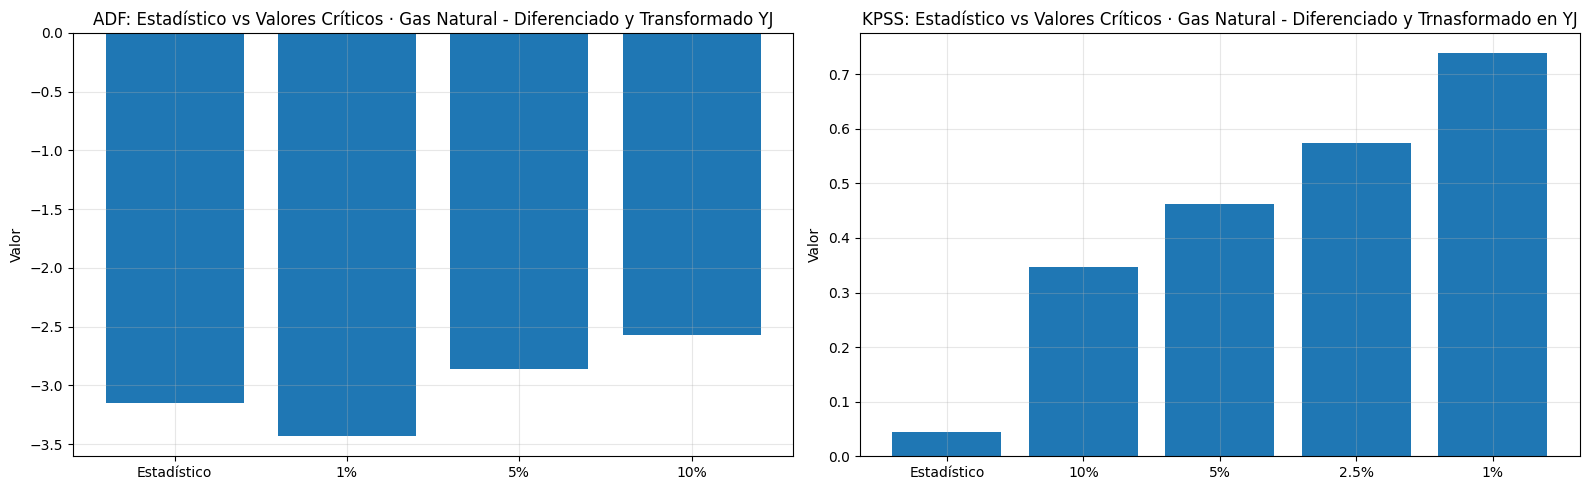

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ADF
axes[0].bar(['Estadístico'] + list(adf_crit_dif.keys()),
            [adf_stat_dif] + list(adf_crit_dif.values()))
axes[0].set_title("ADF: Estadístico vs Valores Críticos · Gas Natural - Diferenciado y Transformado YJ")
axes[0].set_ylabel("Valor"); axes[0].grid(alpha=.3)

# KPSS
axes[1].bar(['Estadístico'] + list(kpss_crit_dif.keys()),
            [kpss_stat_dif] + [float(k) for k in kpss_crit_dif.values()])
axes[1].set_title("KPSS: Estadístico vs Valores Críticos · Gas Natural - Diferenciado y Trnasformado en YJ")
axes[1].set_ylabel("Valor"); axes[1].grid(alpha=.3)

plt.tight_layout(); plt.show()

### Gráfica Shapiro WILK

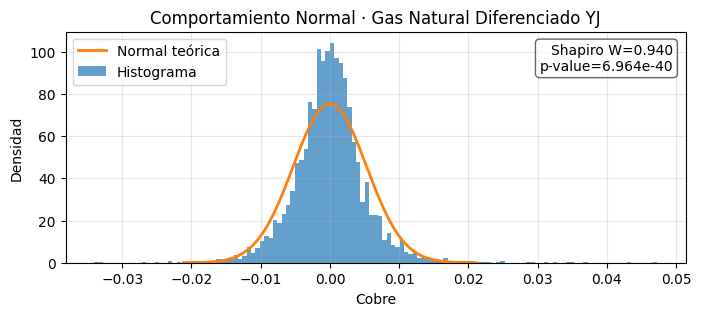

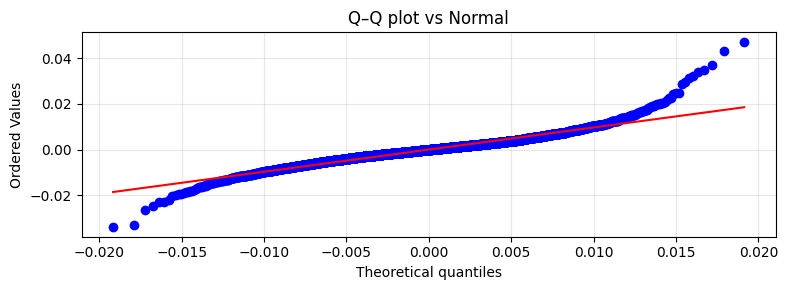

In [74]:
y = df_gas_natural['gas_natural_yj_dif']
sh_stat, sh_p = stats.shapiro(y)

mu, sigma = np.mean(y), np.std(y, ddof=1)
xs = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)

#hist + curva teorica
plt.figure(figsize=(8,3))
plt.hist(y, bins='auto', density=True, alpha=0.7)
plt.plot(xs, stats.norm.pdf(xs, mu, sigma), linewidth=2)
plt.title("Comportamiento Normal · Gas Natural Diferenciado YJ")
plt.xlabel("Cobre")
plt.ylabel("Densidad")
plt.grid(alpha=.3)
plt.legend(["Normal teórica", "Histograma"], loc="best")
plt.annotate(f"Shapiro W={sh_stat:.3f}\np-value={sh_p:.4g}",
             xy=(0.98, 0.95), xycoords="axes fraction",
             ha="right", va="top",
             bbox=dict(boxstyle="round", fc="white", alpha=0.6))

# --- Q–Q plot ---
plt.figure(figsize=(8,3))
# Usamos la normal con media y sigma estimados
stats.probplot(y, dist="norm", sparams=(mu, sigma), plot=plt)
plt.title("Q–Q plot vs Normal")
plt.grid(alpha=.3)

plt.tight_layout()
plt.show()

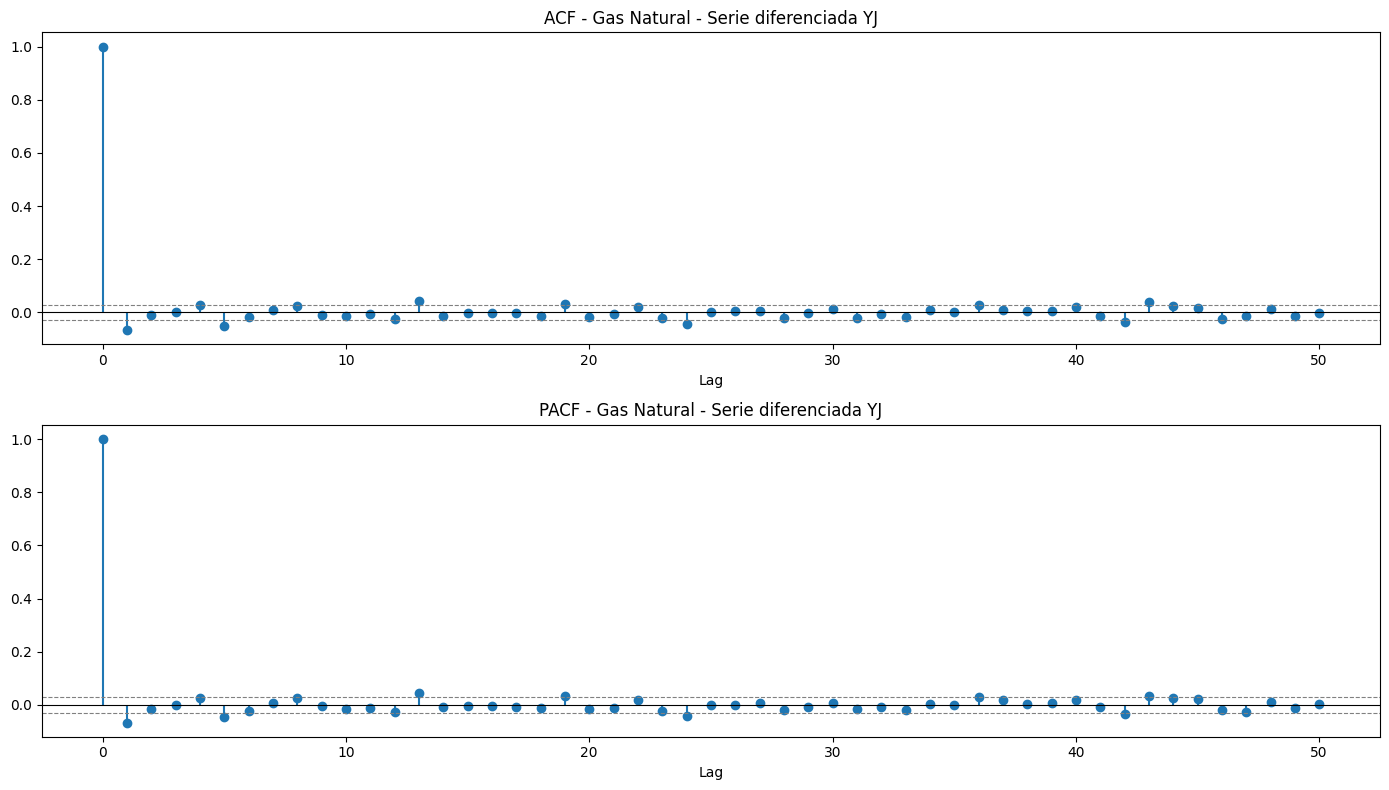

In [75]:
n = len(df_gas_natural)
nlags_acf  = min(50, n-1)
nlags_pacf = min(50, n-1)
pacf_monthly = pacf(df_gas_natural["gas_natural_yj_dif"], nlags=nlags_pacf, method='ywmle')
acf_monthly = acf(df_gas_natural["gas_natural_yj_dif"], nlags=nlags_acf)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
conf = 1.96 / np.sqrt(n)

axes[0].stem(range(len(acf_monthly)), acf_monthly, basefmt=' ')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].axhline(conf, linestyle='--', color='gray', linewidth=0.8)
axes[0].axhline(-conf, linestyle='--', color='gray', linewidth=0.8)
axes[0].set_title('ACF - Gas Natural - Serie diferenciada YJ')
axes[0].set_xlabel('Lag')

axes[1].stem(range(len(pacf_monthly)), pacf_monthly, basefmt=' ')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].axhline(conf, linestyle='--', color='gray', linewidth=0.8)
axes[1].axhline(-conf, linestyle='--', color='gray', linewidth=0.8)
axes[1].set_title('PACF - Gas Natural - Serie diferenciada YJ')
axes[1].set_xlabel('Lag')

plt.tight_layout()
plt.show()

- p = AR = 1 por lo menos
- d = 1 
- q = [1,4]--> podría inclusive, contener 4 componentes de rezago antes del shock
- Poca claridad para definir componentes MA no estacionales → probar entre [1,2]
- s (estacionalidad):5 --> semanal
- P (AR estacional):No se aprecian con claridad componentes autoregresivos estacionales en el PACF → probar P = [0,1].
- Q (MA estacional) ≥ 1 Claramente hay componente Q, ya que los shocks aparecen en múltiplos estacionales  
- Podria tener un componente ESTACIONAL en D=[0,1] 

* Tiene más parecido a un de un arimax-arima que un sarima/sarimax

### Test de Multicolinealidad con Granger

In [76]:
target = "gas_natural_yj_dif"
num_cols = df_gas_natural.select_dtypes(include=[np.number]).columns.drop(target, errors="ignore")

#Calcular Granger F para todas
granger_scores = []
for col in num_cols:
    data = df_gas_natural[[target, col]].dropna()
    if len(data) < 10:
        continue
    try:
        results = grangercausalitytests(data, maxlag=3, verbose=False)
        #Máximo F-stat entre todos los lags
        max_f = max([results[lag][0]['ssr_ftest'][0] for lag in results.keys()])
        granger_scores.append({'variable': col, 'Granger_F': max_f})
    except:
        continue

granger_df = pd.DataFrame(granger_scores).sort_values('Granger_F', ascending=False)

#Eliminar multicolinealidad (corr > 0.85)
vars_list = granger_df['variable'].tolist()
corr_matrix = df_gas_natural[vars_list].corr()

variables_a_eliminar = set()
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.85:
            var1, var2 = corr_matrix.columns[i], corr_matrix.columns[j]
            f1 = granger_df[granger_df['variable'] == var1]['Granger_F'].values[0]
            f2 = granger_df[granger_df['variable'] == var2]['Granger_F'].values[0]
            
            #Eliminar la de MENOR Granger F (peor causalidad)
            variables_a_eliminar.add(var2 if f1 > f2 else var1)

top = granger_df[~granger_df['variable'].isin(variables_a_eliminar)] 
lista_variables_gas_natural=top['variable'].tolist()+list([target])
lista_variables_gas_natural_test=top['variable'].tolist()
         
top

,variable,Granger_F
69,gas_natural_yj,10.195643
57,desempleo_can,3.915685
36,paas,3.895619
18,googl,3.298339
4,plata,3.220583
26,aem,2.920036
7,emergentes,2.472541
31,eqt,2.394728
35,nem,2.336896
29,ctra,2.143447


In [77]:
df_gas_natural_final=df_gas_natural[lista_variables_gas_natural]

In [78]:
df_gas_natural_final.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4664 entries, 2007-07-31 to 2025-06-13
Freq: B
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   gas_natural_yj      4664 non-null   float64
 1   desempleo_can       4664 non-null   float64
 2   paas                4664 non-null   float64
 3   googl               4664 non-null   float64
 4   plata               4664 non-null   float64
 5   aem                 4664 non-null   float64
 6   emergentes          4664 non-null   float64
 7   eqt                 4664 non-null   float64
 8   nem                 4664 non-null   float64
 9   ctra                4664 non-null   float64
 10  desempleo_ale       4664 non-null   float64
 11  ag                  4664 non-null   float64
 12  vix                 4664 non-null   float64
 13  fcx                 4664 non-null   float64
 14  pib_gbr             4664 non-null   float64
 15  shanghai            4664 non-

### Matrix de Corr() - Gas Natural

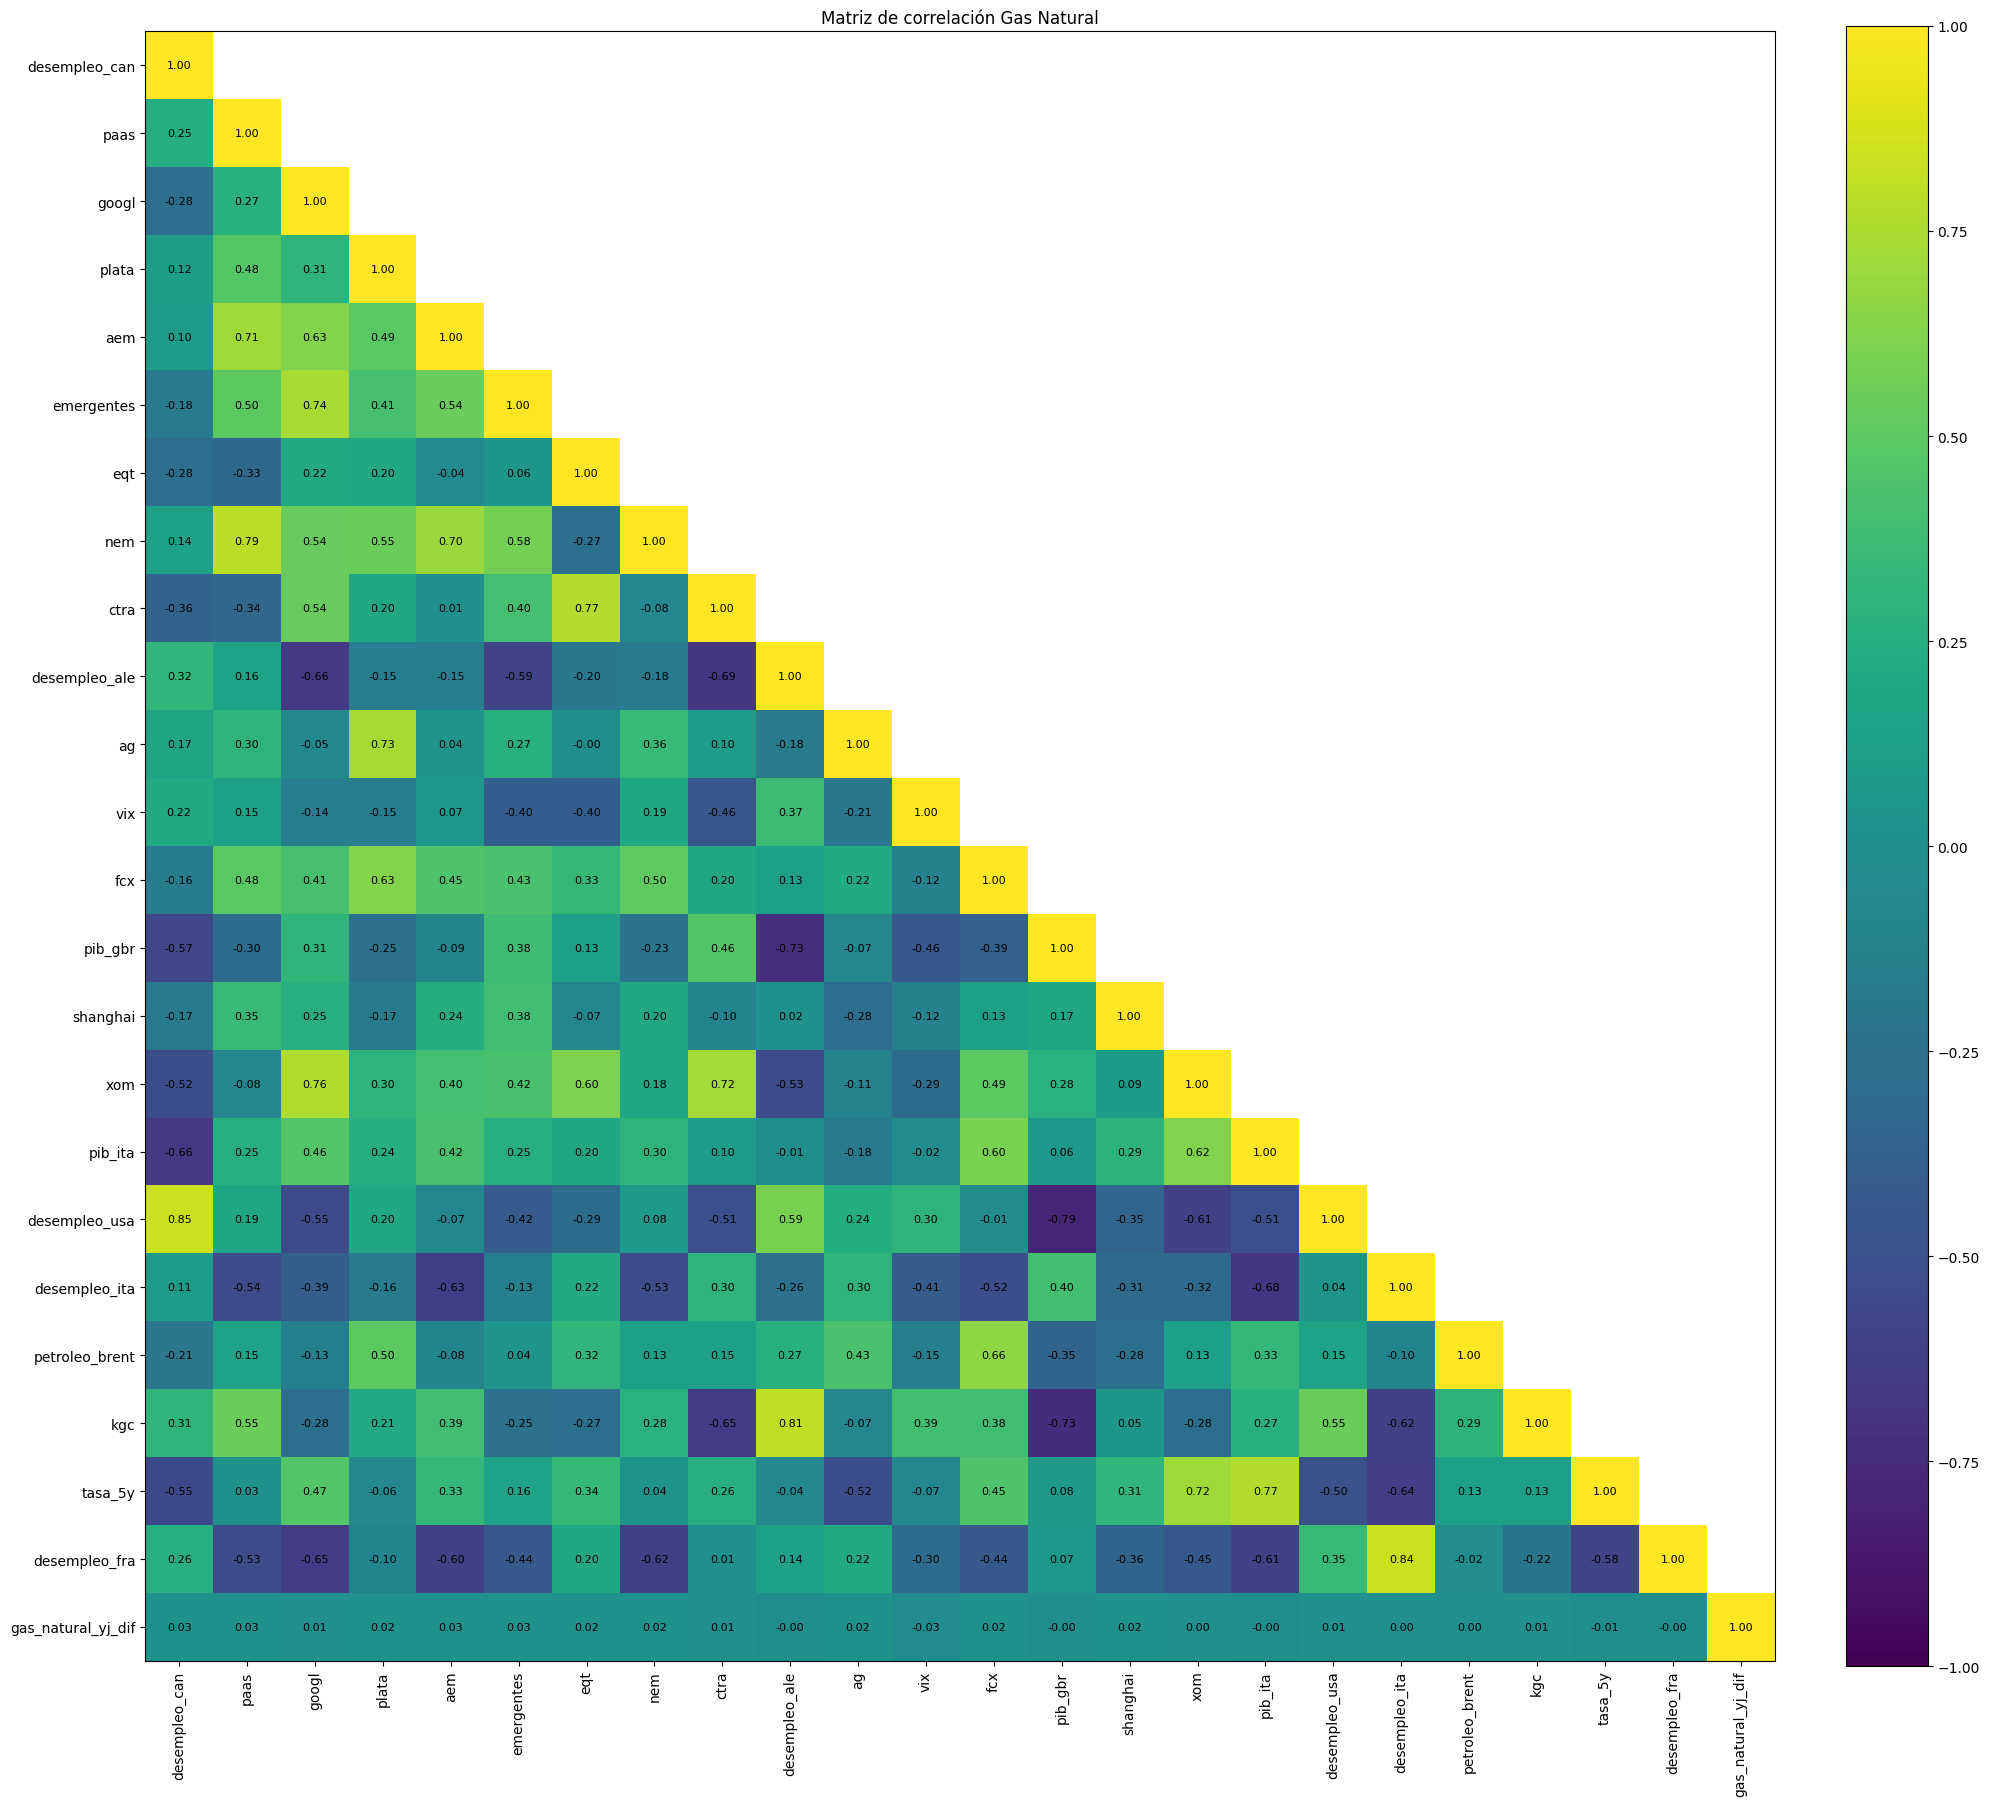

In [79]:
num_cols = (
    df_gas_natural_final.drop(columns=["gas_natural_yj"])
    .select_dtypes(include="number")
    .drop(columns=["fecha"], errors="ignore")
)

corr = num_cols.corr()

M = corr.values.copy()
mask = np.triu(np.ones_like(M, dtype=bool), k=1)
M_masked = M.copy()
M_masked[mask] = np.nan

plt.figure(figsize=(20, 20))
im = plt.imshow(M_masked, vmin=-1, vmax=1)  # sin cmap explícito
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)

for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        if not mask[i, j] and not np.isnan(M_masked[i, j]):
            plt.text(j, i, f"{M[i, j]:.2f}", ha="center", va="center", fontsize=8)

plt.title("Matriz de correlación Gas Natural")
plt.tight_layout()
plt.show()

### Test de Causalidad de Granger

In [80]:
exclude_cols = ["gas_natural","gas_natural_yj"]
features = df_gas_natural_final.drop(columns=exclude_cols, errors="ignore").select_dtypes(include=['float64', 'int64']).columns

max_lag = 7
results = []

for col in features:
    try:
        data = df_gas_natural_final[[col, "gas_natural_yj_dif"]].dropna()
        
        if len(data) > max_lag + 1:
            test = grangercausalitytests(data[["gas_natural_yj_dif", col]], max_lag, verbose=False)
            row = {'Feature': col}
            for lag in range(1, max_lag + 1):
                p_val = test[lag][0]['ssr_ftest'][1]
                row[f'P_Value_Lag{lag}'] = p_val
                row[f'Significant_Lag{lag}'] = p_val < 0.05
            
            results.append(row)
    except:
        continue
granger_df = pd.DataFrame(results)
granger_df['Min_P_Value'] = granger_df[['P_Value_Lag1', 'P_Value_Lag2', 'P_Value_Lag3']].min(axis=1)
granger_df_gas_natural = granger_df.sort_values('Min_P_Value').reset_index(drop=True)

granger_df_gas_natural.head(40)

,Feature,P_Value_Lag1,Significant_Lag1,P_Value_Lag2,Significant_Lag2,P_Value_Lag3,Significant_Lag3,P_Value_Lag4,Significant_Lag4,P_Value_Lag5,Significant_Lag5,P_Value_Lag6,Significant_Lag6,P_Value_Lag7,Significant_Lag7,Min_P_Value
0,googl,0.338598,False,0.087323,False,0.019564,True,0.004237,True,0.001716,True,0.001683,True,0.001120,True,0.019564
1,plata,0.208081,False,0.040021,True,0.082795,False,0.154710,False,0.146017,False,0.175472,False,0.254348,False,0.040021
2,desempleo_can,0.047896,True,0.069781,False,0.054548,False,0.051207,False,0.004463,True,0.005598,True,0.008180,True,0.047896
3,paas,0.048471,True,0.085453,False,0.145172,False,0.177973,False,0.120977,False,0.165384,False,0.235736,False,0.048471
4,aem,0.087552,False,0.204129,False,0.259260,False,0.173353,False,0.200641,False,0.177241,False,0.257654,False,0.087552
5,eqt,0.774310,False,0.091310,False,0.177495,False,0.245113,False,0.309481,False,0.366705,False,0.435660,False,0.091310
6,desempleo_ale,0.972717,False,0.996341,False,0.097022,False,0.157974,False,0.284609,False,0.386467,False,0.494605,False,0.097022
7,emergentes,0.115918,False,0.207160,False,0.206343,False,0.346243,False,0.448208,False,0.445746,False,0.395079,False,0.115918
8,ctra,0.822474,False,0.117366,False,0.167931,False,0.196417,False,0.237179,False,0.325034,False,0.429374,False,0.117366
9,ag,0.231678,False,0.122811,False,0.219294,False,0.327894,False,0.354834,False,0.387948,False,0.406656,False,0.122811


In [81]:
sig_cols = [c for c in granger_df_gas_natural.columns if c.lower().startswith('significant_lag')]
granger_df_gas_natural["granger_test"] = granger_df_gas_natural[sig_cols].any(axis=1).astype(int) 

granger_df_gas_natural=list(granger_df_gas_natural[granger_df_gas_natural["granger_test"]==1]["Feature"])+["gas_natural_yj"]
df_gas_natural_final=df_gas_natural_final[granger_df_gas_natural]

### Gráfica - Serie Temporal GAS NATURAL YJ

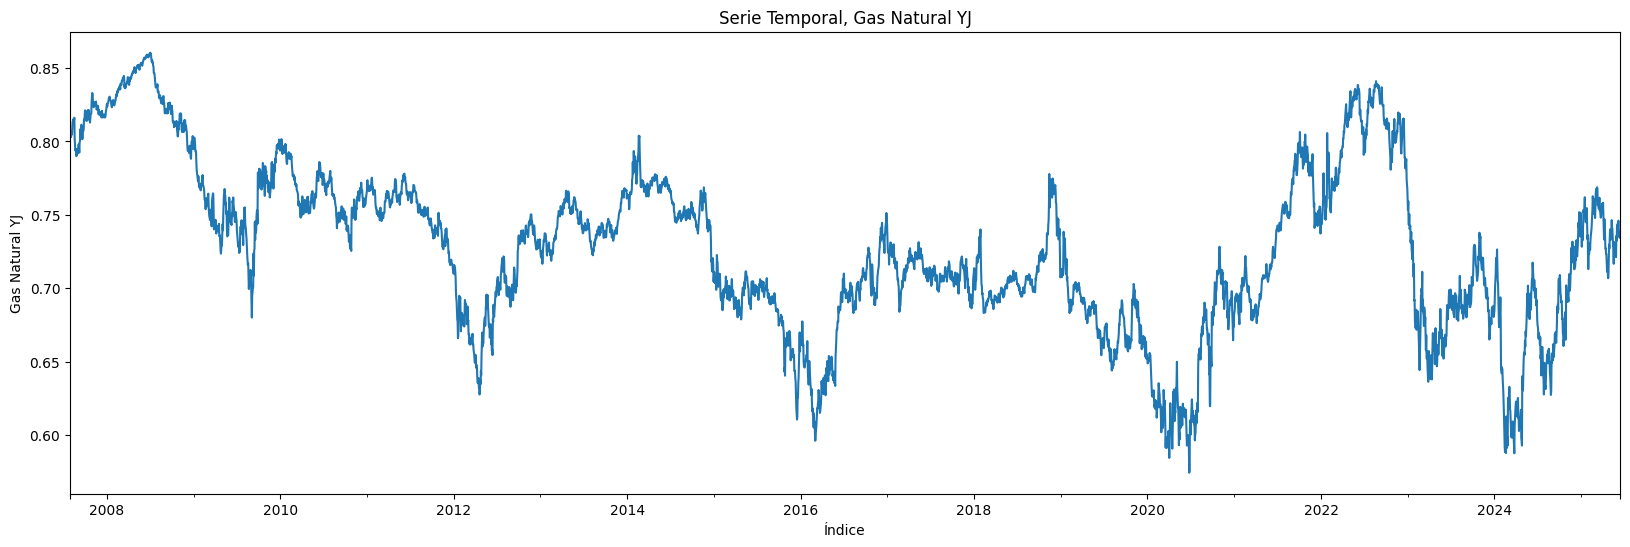

In [82]:
df_gas_natural_final['gas_natural_yj'].plot(figsize=(20,6))
plt.xlabel('Índice')
plt.ylabel('Gas Natural YJ')
plt.title('Serie Temporal, Gas Natural YJ')
plt.show()

* Se Puede apreciar claramente un comportamiento estacional y podría ser que inclusive, mantenga un comportamiento ciclico, por lo que evaluaremos la gráfica de la variable diferenciada

## Comportamiento estacional claro --> indica una diferenciación D=1

## Análisis del Petroleo Brent

In [83]:
df_petroleo_brent=df_train.copy()
# === TEST DE SHAPIRO-WILK ===
print("=" * 70)
print("TEST DE SHAPIRO-WILK (Normalidad)")
print("=" * 70)
shapiro_stat, shapiro_p = stats.shapiro(df_petroleo_brent['petroleo_brent'].dropna())
print(f"Shapiro Statistic: {shapiro_stat:.4f}")
print(f"p-value: {shapiro_p:.4f}")
if shapiro_p > 0.05:
    print("H0: No se rechaza - distribución normal")
    
else:
    print("H0: Se rechaza hipotesis nula - datos no presentan distribución normal")

TEST DE SHAPIRO-WILK (Normalidad)
Shapiro Statistic: 0.9769
p-value: 0.0000
H0: Se rechaza hipotesis nula - datos no presentan distribución normal


## Test de BoxCox para normalizar la serie y controlar la varianza

In [84]:
transformacion, lambda_opt_petroleo = boxcox(df_petroleo_brent['petroleo_brent'])
print(f"Lambda óptimo: {lambda_opt:.4f}")

Lambda óptimo: -0.6623


YJ Ya que BoxCox es negativo

In [85]:
transformacion, lambda_opt_petroleo = yeojohnson(df_petroleo_brent['petroleo_brent'])
print(f"Lambda óptimo: {lambda_opt:.4f}")

Lambda óptimo: -0.6623


In [86]:
df_petroleo_brent['petroleo_brent_yj'] = yeojohnson(df_petroleo_brent['petroleo_brent'], lmbda=lambda_opt_petroleo)

### Análisis de Descomposición

El modelo aditivo es más adecuado (CV menor).


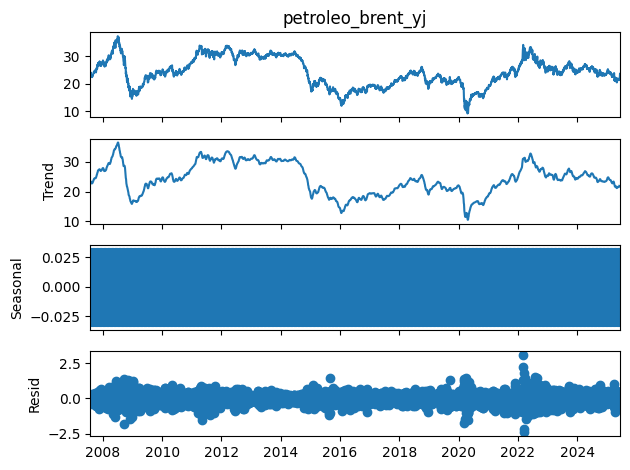

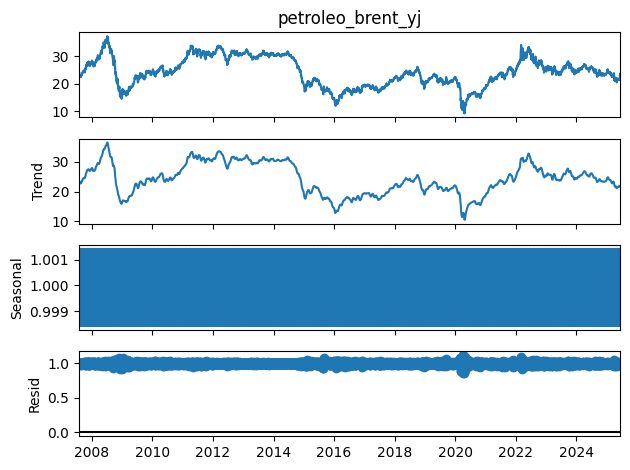

In [87]:
decompose_add = seasonal_decompose(df_petroleo_brent['petroleo_brent_yj'] , model='additive', period=12)
decompose_mult = seasonal_decompose(df_petroleo_brent['petroleo_brent_yj'], model='multiplicative', period=12)

decompose_add.plot()
decompose_mult.plot()


seasonal_add = decompose_add.seasonal
seasonal_mult = decompose_mult.seasonal

cv_add = variation(seasonal_add.dropna())
cv_mult = variation(seasonal_mult.dropna()) 
if cv_add < cv_mult:
    print("El modelo aditivo es más adecuado (CV menor).")
elif cv_add > cv_mult:
    print("El modelo multiplicativo es más adecuado (CV menor).")
else:
    print("Ambos modelos tienen el mismo CV.")

El componente multiplicativo en la descomposición suma más, por lo que nos podría indicar de antemano, que tiene componentes estacionales

### Test ADF-KPSS

In [88]:
series_to_test = df_petroleo_brent['petroleo_brent_yj'].dropna()

#ADF
adf_stat, adf_pval, adf_lags, adf_nobs, adf_crit, _ = adfuller(series_to_test)
print(f"ADF Statistic : {adf_stat:.4f}")
print(f"ADF p-value   : {adf_pval:.4g}")
print("»", "Estacionaria" if adf_pval < 0.05 else "NO estacionaria", "según ADF")

#KPSS
kpss_stat, kpss_pval, kpss_lags, kpss_crit = kpss(series_to_test, regression='c', nlags="auto")
print(f"KPSS Statistic: {kpss_stat:.4f}")
print(f"KPSS p-value  : {kpss_pval:.4g}")
print("»", "Estacionaria" if kpss_pval > 0.05 else "NO estacionaria", "según KPSS")

tests_df = pd.DataFrame([
    {
        "serie": "petroleo_brent_yj",
        "test": "ADF",
        "stat": adf_stat,
        "p_value": adf_pval,
        "lags_usados": adf_lags,
        "n_observaciones": adf_nobs,
        "crit_1%": adf_crit.get("1%"),
        "crit_5%": adf_crit.get("5%"),
        "crit_10%": adf_crit.get("10%"),
        "estacionaria": adf_pval < 0.05  # criterio ADF
    },
    {
        "serie": "petroleo_brent_yj",
        "test": "KPSS (c)",
        "stat": kpss_stat,
        "p_value": kpss_pval,
        "lags_usados": kpss_lags,
        "n_observaciones": series_to_test.shape[0],
        "crit_1%": float(kpss_crit.get("1%")),
        "crit_5%": float(kpss_crit.get("5%")),
        "crit_10%": float(kpss_crit.get("10%")),
        "estacionaria": kpss_pval > 0.05  # criterio KPSS
    }
])

ts_tests_mensual = tests_df

print(ts_tests_mensual)

ADF Statistic : -2.1776
ADF p-value   : 0.2145
» NO estacionaria según ADF
KPSS Statistic: 1.7006
KPSS p-value  : 0.01
» NO estacionaria según KPSS
               serie      test      stat  p_value  lags_usados  \
0  petroleo_brent_yj       ADF -2.177585 0.214481            5   
1  petroleo_brent_yj  KPSS (c)  1.700629 0.010000           41   

   n_observaciones   crit_1%   crit_5%  crit_10%  estacionaria  
0             4659 -3.431754 -2.862161 -2.567100         False  
1             4665  0.739000  0.463000  0.347000         False  


* Diferenciamos por precencia de componentes estacionales

In [89]:
df_petroleo_brent['petroleo_brent_yj_dif']=df_petroleo_brent['petroleo_brent_yj'].diff()

In [90]:
df_petroleo_brent=df_petroleo_brent.dropna(subset="petroleo_brent_yj_dif")

In [91]:
#ADF
adf_stat_dif, adf_pval_dif, adf_lags_dif, adf_nobs_dif, adf_crit_dif, _ = adfuller(df_petroleo_brent['petroleo_brent_yj_dif'])
print(f"ADF Statistic : {adf_stat_dif:.4f}")
print(f"ADF p-value   : {adf_pval_dif:.4g}")
print("»", "Estacionaria" if adf_pval_dif < 0.05 else "NO estacionaria", "según ADF")

#KPSS
kpss_stat_dif, kpss_pval_dif, kpss_lags_dif, kpss_crit_dif = kpss(df_petroleo_brent['petroleo_brent_yj_dif'], regression='c', nlags="auto")
print(f"KPSS Statistic: {kpss_stat_dif:.4f}")
print(f"KPSS p-value  : {kpss_pval_dif:.4g}")
print("»", "Estacionaria" if kpss_pval_dif > 0.05 else "NO estacionaria", "según KPSS")

tests_df_dif = pd.DataFrame([
    {
        "serie": "Petroleo_Brent_dif_YJ",
        "test": "ADF",
        "stat": adf_stat_dif,
        "p_value": adf_pval_dif,
        "lags_usados": adf_lags_dif,
        "n_observaciones": adf_nobs_dif,
        "crit_1%": adf_crit_dif.get("1%"),
        "crit_5%": adf_crit_dif.get("5%"),
        "crit_10%": adf_crit_dif.get("10%"),
        "estacionaria": adf_pval_dif < 0.05  # criterio ADF
    },
    {
        "serie": "Petróleo_Brent_dif_YJ",
        "test": "KPSS (c)",
        "stat": kpss_stat_dif,
        "p_value": kpss_pval_dif,
        "lags_usados": kpss_lags_dif,
        "n_observaciones": df_petroleo_brent['petroleo_brent_yj_dif'].shape[0],
        "crit_1%": float(kpss_crit_dif.get("1%")),
        "crit_5%": float(kpss_crit_dif.get("5%")),
        "crit_10%": float(kpss_crit_dif.get("10%")),
        "estacionaria": kpss_pval_dif > 0.05  # criterio KPSS
    }
])

ts_tests_mensual_dif = tests_df_dif

print(ts_tests_mensual_dif)

ADF Statistic : -31.1690
ADF p-value   : 0
» Estacionaria según ADF
KPSS Statistic: 0.0516
KPSS p-value  : 0.1
» Estacionaria según KPSS
                   serie      test       stat  p_value  lags_usados  \
0  Petroleo_Brent_dif_YJ       ADF -31.169047 0.000000            4   
1  Petróleo_Brent_dif_YJ  KPSS (c)   0.051554 0.100000            7   

   n_observaciones   crit_1%   crit_5%  crit_10%  estacionaria  
0             4659 -3.431754 -2.862161 -2.567100          True  
1             4664  0.739000  0.463000  0.347000          True  


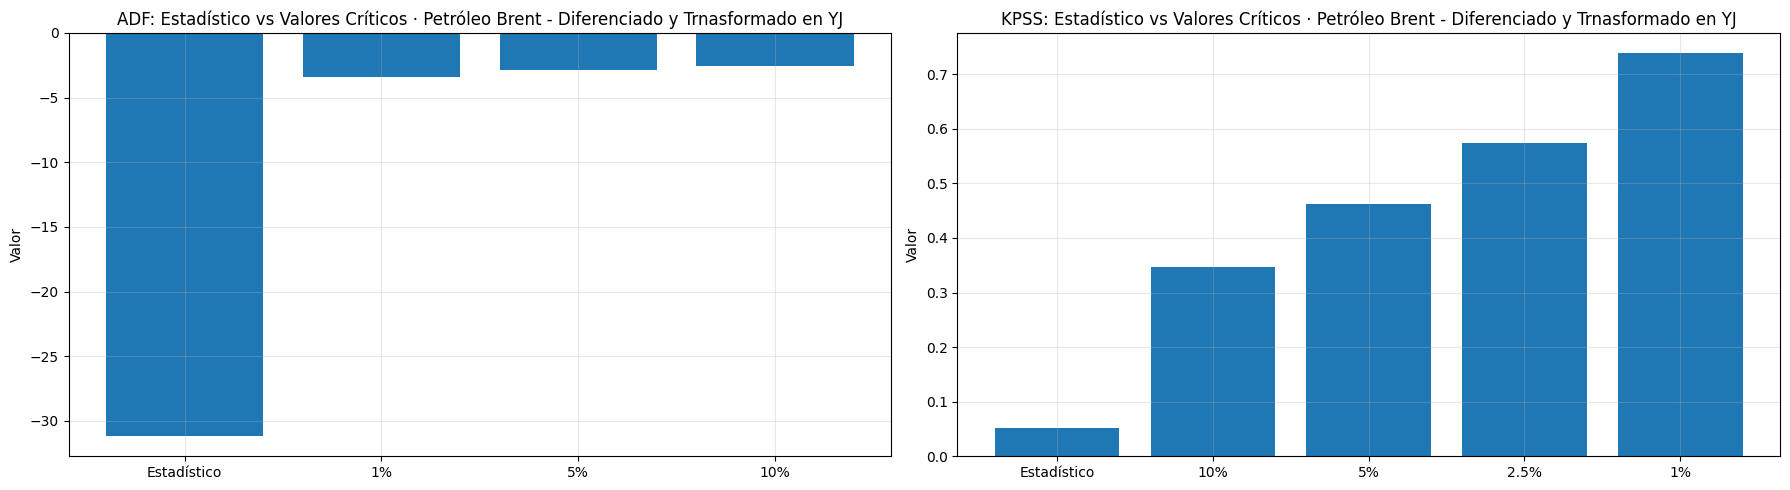

In [92]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# ADF
axes[0].bar(['Estadístico'] + list(adf_crit_dif.keys()),
            [adf_stat_dif] + list(adf_crit_dif.values()))
axes[0].set_title("ADF: Estadístico vs Valores Críticos · Petróleo Brent - Diferenciado y Trnasformado en YJ")
axes[0].set_ylabel("Valor"); axes[0].grid(alpha=.3)

# KPSS
axes[1].bar(['Estadístico'] + list(kpss_crit_dif.keys()),
            [kpss_stat_dif] + [float(k) for k in kpss_crit_dif.values()])
axes[1].set_title("KPSS: Estadístico vs Valores Críticos · Petróleo Brent - Diferenciado y Trnasformado en YJ")
axes[1].set_ylabel("Valor"); axes[1].grid(alpha=.3)

plt.tight_layout(); plt.show()

* La serie ya tiene un comportamiento estacionario

### Gráfica - Shapiro Wilk

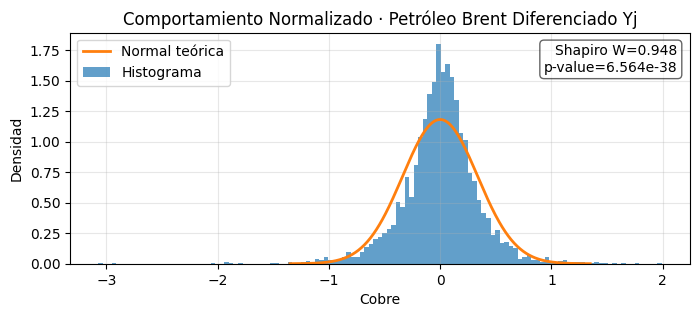

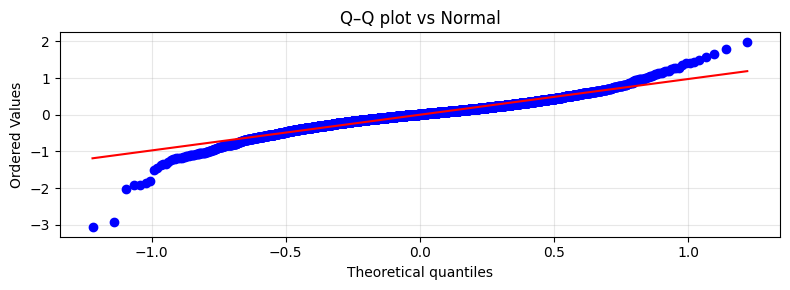

In [93]:
y = df_petroleo_brent['petroleo_brent_yj_dif']
sh_stat, sh_p = stats.shapiro(y)

mu, sigma = np.mean(y), np.std(y, ddof=1)
xs = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)

#hist + curva teorica
plt.figure(figsize=(8,3))
plt.hist(y, bins='auto', density=True, alpha=0.7)
plt.plot(xs, stats.norm.pdf(xs, mu, sigma), linewidth=2)
plt.title("Comportamiento Normalizado · Petróleo Brent Diferenciado Yj")
plt.xlabel("Cobre")
plt.ylabel("Densidad")
plt.grid(alpha=.3)
plt.legend(["Normal teórica", "Histograma"], loc="best")
plt.annotate(f"Shapiro W={sh_stat:.3f}\np-value={sh_p:.4g}",
             xy=(0.98, 0.95), xycoords="axes fraction",
             ha="right", va="top",
             bbox=dict(boxstyle="round", fc="white", alpha=0.6))

# --- Q–Q plot ---
plt.figure(figsize=(8,3))
# Usamos la normal con media y sigma estimados
stats.probplot(y, dist="norm", sparams=(mu, sigma), plot=plt)
plt.title("Q–Q plot vs Normal")
plt.grid(alpha=.3)

plt.tight_layout()
plt.show()

### ADF- PACF

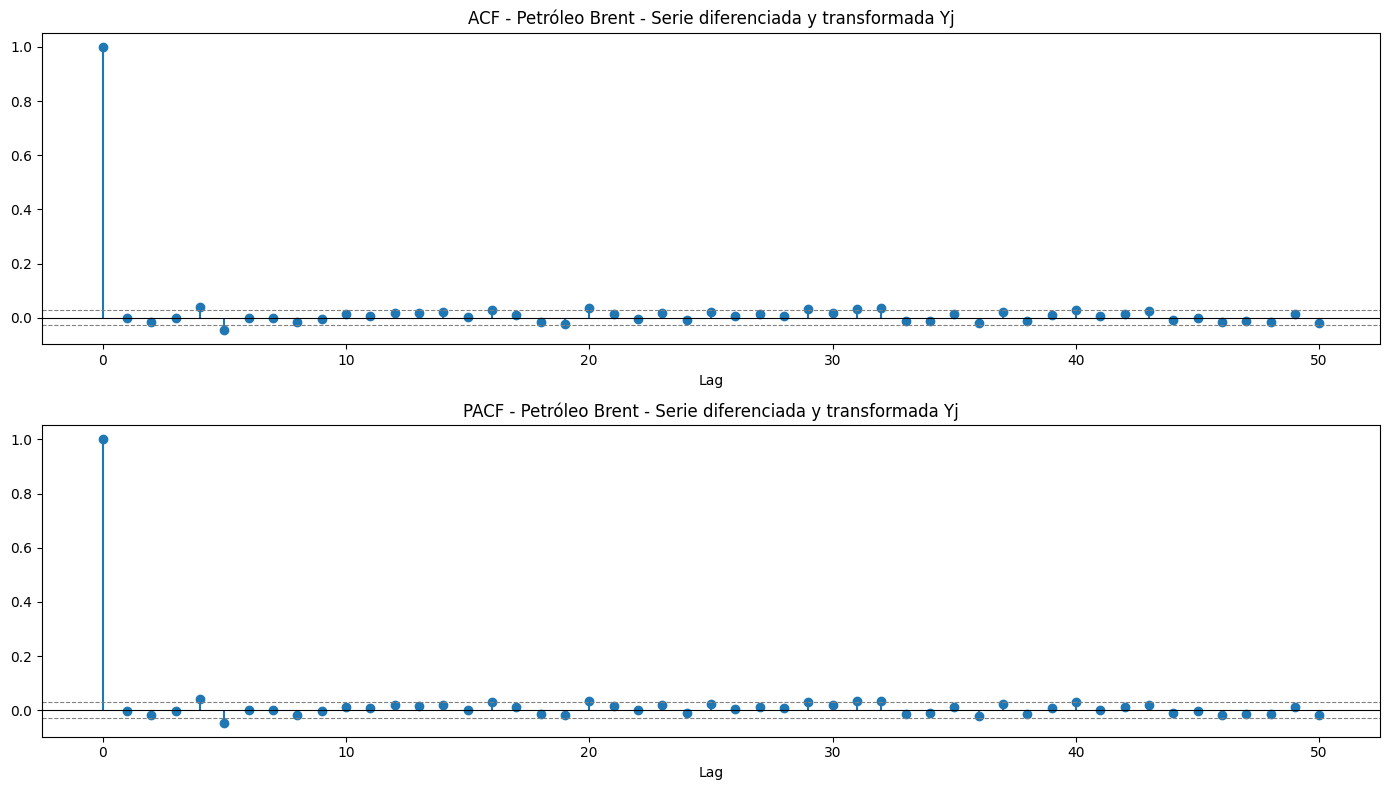

In [94]:
n = len(df_petroleo_brent)
nlags_acf  = min(50, n-1)
nlags_pacf = min(50, n-1)

pacf_monthly = pacf(df_petroleo_brent['petroleo_brent_yj_dif'], nlags=nlags_pacf, method='ywmle')
acf_monthly = acf(df_petroleo_brent['petroleo_brent_yj_dif'], nlags=nlags_acf)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
conf = 1.96 / np.sqrt(n)

axes[0].stem(range(len(acf_monthly)), acf_monthly, basefmt=' ')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].axhline(conf, linestyle='--', color='gray', linewidth=0.8)
axes[0].axhline(-conf, linestyle='--', color='gray', linewidth=0.8)
axes[0].set_title('ACF - Petróleo Brent - Serie diferenciada y transformada Yj')
axes[0].set_xlabel('Lag')

axes[1].stem(range(len(pacf_monthly)), pacf_monthly, basefmt=' ')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].axhline(conf, linestyle='--', color='gray', linewidth=0.8)
axes[1].axhline(-conf, linestyle='--', color='gray', linewidth=0.8)
axes[1].set_title('PACF - Petróleo Brent - Serie diferenciada y transformada Yj')
axes[1].set_xlabel('Lag')

plt.tight_layout()
plt.show()

- p = AR = [0,1] --> lo más probable es que los mejores resultados sean con 0 o a lo más 1
- d = [1] 
- q = [1,4]--> shock fuerte al lag 4 y 5
- Poca claridad para definir componentes MA no estacionales → probar entre [0.2]
- s (estacionalidad):semanal [5]
- P (AR estacional):No se aprecian con claridad componentes autoregresivos estacionales en el PACF → probar P = [0,1]
- Q (MA estacional): no se aprecia con claridad, probar con [0,1] 
- Podria tener un componente ESTACIONAL en D=1, producto de las ascilaciones que presenta de forma recurrente

### Test de Multicolinealidad de Granger

In [95]:
target = "petroleo_brent_yj_dif"
num_cols = df_petroleo_brent.select_dtypes(include=[np.number]).columns.drop(target, errors="ignore")

#Calcular Granger F para todas
granger_scores = []
for col in num_cols:
    data = df_petroleo_brent[[target, col]].dropna()
    if len(data) < 10:
        continue
    try:
        results = grangercausalitytests(data, maxlag=3, verbose=False)
        #Máximo F-stat entre todos los lags
        max_f = max([results[lag][0]['ssr_ftest'][0] for lag in results.keys()])
        granger_scores.append({'variable': col, 'Granger_F': max_f})
    except:
        continue

granger_df = pd.DataFrame(granger_scores).sort_values('Granger_F', ascending=False)

#Eliminar multicolinealidad (corr > 0.85)
vars_list = granger_df['variable'].tolist()
corr_matrix = df_petroleo_brent[vars_list].corr()

variables_a_eliminar = set()
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.85:
            var1, var2 = corr_matrix.columns[i], corr_matrix.columns[j]
            f1 = granger_df[granger_df['variable'] == var1]['Granger_F'].values[0]
            f2 = granger_df[granger_df['variable'] == var2]['Granger_F'].values[0]
            
            #Eliminar la de MENOR Granger F (peor causalidad)
            variables_a_eliminar.add(var2 if f1 > f2 else var1)

top = granger_df[~granger_df['variable'].isin(variables_a_eliminar)] 
lista_variables_petroleo_brent=top['variable'].tolist()+list([target])+["petroleo_brent_yj"]
top

,variable,Granger_F
32,fcx,25.342120
40,xom,23.175857
28,bhp,22.230368
7,emergentes,17.707267
29,ctra,14.150794
31,eqt,12.091947
52,desempleo_usa,11.265830
57,desempleo_can,11.162860
35,nem,8.700662
12,vix,8.199450


In [96]:
df_petroleo_brent_final=df_petroleo_brent[lista_variables_petroleo_brent]

In [97]:
df_petroleo_brent_final

,fcx,xom,bhp,emergentes,ctra,eqt,desempleo_usa,desempleo_can,nem,vix,pib_gbr,paas,petroleo_brent,shanghai,aem,kgc,gas_natural,ag,pib_ita,desempleo_ita,plata,desempleo_fra,tasa_10y,desempleo_ingl,tasa_2y,petroleo_brent_yj_dif,petroleo_brent_yj
FECHA,,,,,,,,,,,,,,,,,,,,,,,,,,,
2007-07-31,32.836269,44.734661,22.847242,30.161293,6.124954,21.234945,4.600000,6.100000,28.910706,23.520000,407553.300000,21.549908,77.050003,4471.032227,32.626858,11.177741,6.191000,4.245691,424785.500000,6.000000,12.950000,8.000000,4.780000,5.300000,4.560000,0.279626,24.205949
2007-08-01,31.361826,45.107727,22.381550,30.042988,6.182264,21.987703,4.600000,6.000000,28.799919,23.670000,407553.300000,21.255020,75.349998,4300.562988,32.028625,10.884951,6.352000,4.443165,424785.500000,6.200000,12.888000,8.000000,4.760000,5.300000,4.560000,-0.363200,23.842750
2007-08-02,31.641344,44.760944,22.542746,30.375154,6.185846,22.456480,4.600000,6.000000,28.896852,21.219999,407553.300000,21.681824,75.760002,4407.729980,32.427448,10.850503,6.106000,4.403671,424785.500000,6.200000,12.935000,8.000000,4.770000,5.300000,4.590000,0.087856,23.930606
2007-08-03,30.096992,43.131947,21.754663,29.064692,5.945861,21.897556,4.600000,6.000000,28.322113,25.160000,407553.300000,22.100878,74.750000,4560.773926,32.887638,10.928005,6.090000,4.176576,424785.500000,6.200000,13.100000,8.000000,4.710000,5.300000,4.460000,-0.216728,23.713878
2007-08-06,29.862906,43.899147,22.037655,29.583418,5.877806,22.235619,4.600000,6.000000,28.155912,22.940001,407553.300000,21.899113,71.169998,4628.107910,31.798540,10.824667,6.208000,4.176576,424785.500000,6.200000,12.977000,8.000000,4.720000,5.300000,4.460000,-0.776617,22.937262
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-09,42.049992,104.002220,50.180000,46.865986,25.714287,54.732189,4.200000,7.000000,53.103386,17.160000,432422.100000,29.209999,67.040001,3399.771973,118.171227,15.056290,3.635000,8.330000,431990.600000,6.500000,36.688000,7.600000,4.490000,4.700000,4.010000,0.127553,22.024119
2025-06-10,41.901020,106.231476,50.880001,47.133396,25.635014,53.565762,4.200000,7.000000,52.385777,16.950001,432422.100000,28.490000,66.870003,3384.815918,116.725250,14.786715,3.533000,8.370000,431990.600000,6.500000,36.542000,7.600000,4.470000,4.700000,4.010000,-0.038002,21.986117
2025-06-11,40.729099,108.302208,50.610001,47.331478,25.545832,53.805031,4.200000,7.000000,53.133289,17.260000,432422.100000,28.660000,69.769997,3402.315918,118.580093,15.236007,3.507000,8.340000,431990.600000,6.500000,36.166000,7.600000,4.410000,4.700000,3.940000,0.643736,22.629852


### Matrix de corr() - Petróleo Brent

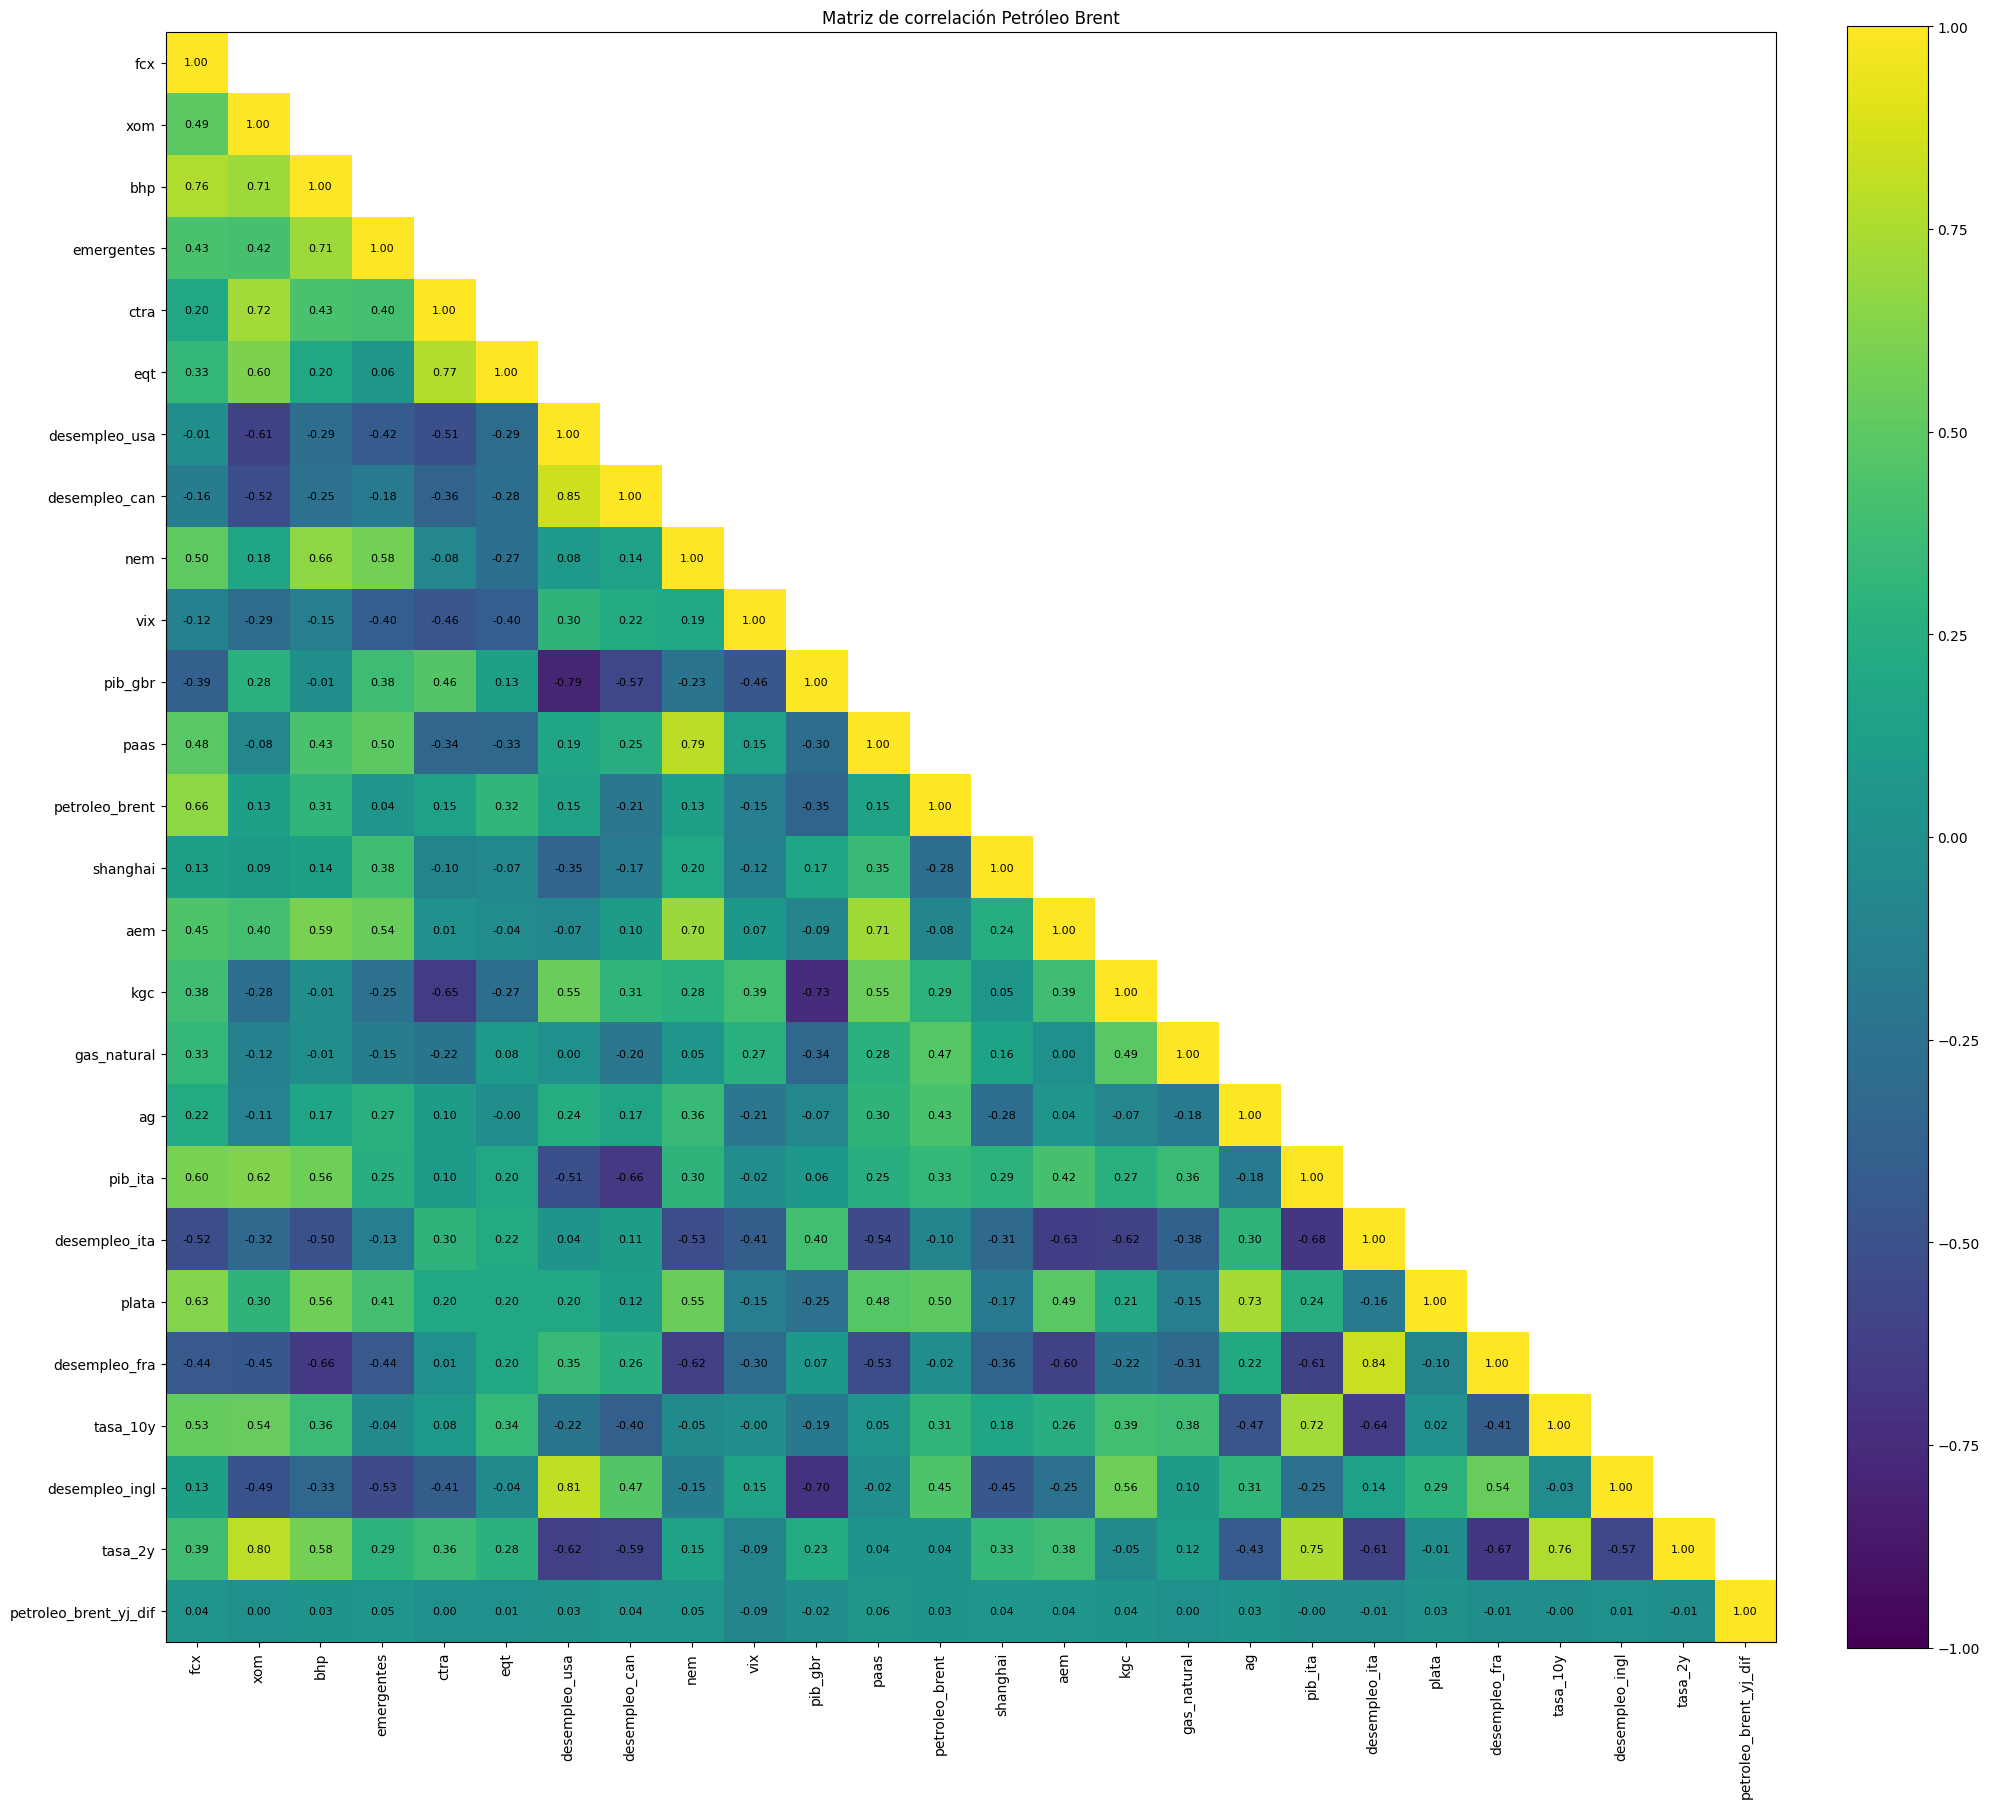

In [98]:
num_cols = (
    df_petroleo_brent_final.drop(columns=["petroleo_brent_yj"])
    .select_dtypes(include="number")
    .drop(columns=["fecha"], errors="ignore")
)

corr = num_cols.corr()

M = corr.values.copy()
mask = np.triu(np.ones_like(M, dtype=bool), k=1)
M_masked = M.copy()
M_masked[mask] = np.nan

plt.figure(figsize=(20, 20))
im = plt.imshow(M_masked, vmin=-1, vmax=1)  # sin cmap explícito
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)

for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        if not mask[i, j] and not np.isnan(M_masked[i, j]):
            plt.text(j, i, f"{M[i, j]:.2f}", ha="center", va="center", fontsize=8)

plt.title("Matriz de correlación Petróleo Brent")
plt.tight_layout()
plt.show()

In [99]:
df_petroleo_brent_final

,fcx,xom,bhp,emergentes,ctra,eqt,desempleo_usa,desempleo_can,nem,vix,pib_gbr,paas,petroleo_brent,shanghai,aem,kgc,gas_natural,ag,pib_ita,desempleo_ita,plata,desempleo_fra,tasa_10y,desempleo_ingl,tasa_2y,petroleo_brent_yj_dif,petroleo_brent_yj
FECHA,,,,,,,,,,,,,,,,,,,,,,,,,,,
2007-07-31,32.836269,44.734661,22.847242,30.161293,6.124954,21.234945,4.600000,6.100000,28.910706,23.520000,407553.300000,21.549908,77.050003,4471.032227,32.626858,11.177741,6.191000,4.245691,424785.500000,6.000000,12.950000,8.000000,4.780000,5.300000,4.560000,0.279626,24.205949
2007-08-01,31.361826,45.107727,22.381550,30.042988,6.182264,21.987703,4.600000,6.000000,28.799919,23.670000,407553.300000,21.255020,75.349998,4300.562988,32.028625,10.884951,6.352000,4.443165,424785.500000,6.200000,12.888000,8.000000,4.760000,5.300000,4.560000,-0.363200,23.842750
2007-08-02,31.641344,44.760944,22.542746,30.375154,6.185846,22.456480,4.600000,6.000000,28.896852,21.219999,407553.300000,21.681824,75.760002,4407.729980,32.427448,10.850503,6.106000,4.403671,424785.500000,6.200000,12.935000,8.000000,4.770000,5.300000,4.590000,0.087856,23.930606
2007-08-03,30.096992,43.131947,21.754663,29.064692,5.945861,21.897556,4.600000,6.000000,28.322113,25.160000,407553.300000,22.100878,74.750000,4560.773926,32.887638,10.928005,6.090000,4.176576,424785.500000,6.200000,13.100000,8.000000,4.710000,5.300000,4.460000,-0.216728,23.713878
2007-08-06,29.862906,43.899147,22.037655,29.583418,5.877806,22.235619,4.600000,6.000000,28.155912,22.940001,407553.300000,21.899113,71.169998,4628.107910,31.798540,10.824667,6.208000,4.176576,424785.500000,6.200000,12.977000,8.000000,4.720000,5.300000,4.460000,-0.776617,22.937262
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-09,42.049992,104.002220,50.180000,46.865986,25.714287,54.732189,4.200000,7.000000,53.103386,17.160000,432422.100000,29.209999,67.040001,3399.771973,118.171227,15.056290,3.635000,8.330000,431990.600000,6.500000,36.688000,7.600000,4.490000,4.700000,4.010000,0.127553,22.024119
2025-06-10,41.901020,106.231476,50.880001,47.133396,25.635014,53.565762,4.200000,7.000000,52.385777,16.950001,432422.100000,28.490000,66.870003,3384.815918,116.725250,14.786715,3.533000,8.370000,431990.600000,6.500000,36.542000,7.600000,4.470000,4.700000,4.010000,-0.038002,21.986117
2025-06-11,40.729099,108.302208,50.610001,47.331478,25.545832,53.805031,4.200000,7.000000,53.133289,17.260000,432422.100000,28.660000,69.769997,3402.315918,118.580093,15.236007,3.507000,8.340000,431990.600000,6.500000,36.166000,7.600000,4.410000,4.700000,3.940000,0.643736,22.629852


### Test de Causalidad de Granger

In [100]:
exclude_cols = ["petroleo_brent","petroleo_brent_yj"]
features = df_petroleo_brent_final.drop(columns=exclude_cols, errors="ignore").select_dtypes(include=['float64', 'int64']).columns

max_lag = 7
results = []

for col in features:
    try:
        data = df_petroleo_brent_final[[col, "petroleo_brent_yj_dif"]].dropna()
        
        if len(data) > max_lag + 1:
            test = grangercausalitytests(data[["petroleo_brent_yj_dif", col]], max_lag, verbose=False)
            row = {'Feature': col}
            for lag in range(1, max_lag + 1):
                p_val = test[lag][0]['ssr_ftest'][1]
                row[f'P_Value_Lag{lag}'] = p_val
                row[f'Significant_Lag{lag}'] = p_val < 0.05
            
            results.append(row)
    except:
        continue
granger_df = pd.DataFrame(results)
granger_df['Min_P_Value'] = granger_df[['P_Value_Lag1', 'P_Value_Lag2', 'P_Value_Lag3']].min(axis=1)
granger_df_petroleo = granger_df.sort_values('Min_P_Value').reset_index(drop=True)

granger_df_petroleo.head(40)

,Feature,P_Value_Lag1,Significant_Lag1,P_Value_Lag2,Significant_Lag2,P_Value_Lag3,Significant_Lag3,P_Value_Lag4,Significant_Lag4,P_Value_Lag5,Significant_Lag5,P_Value_Lag6,Significant_Lag6,P_Value_Lag7,Significant_Lag7,Min_P_Value
0,bhp,0.399526,False,0.000000,True,0.000000,True,0.000000,True,0.000000,True,0.000000,True,0.000000,True,0.000000
1,fcx,0.169847,False,0.000000,True,0.000000,True,0.000000,True,0.000000,True,0.000000,True,0.000000,True,0.000000
2,xom,0.219576,False,0.000000,True,0.000000,True,0.000000,True,0.000000,True,0.000000,True,0.000000,True,0.000000
3,emergentes,0.043927,True,0.000000,True,0.000000,True,0.000000,True,0.000000,True,0.000000,True,0.000001,True,0.000000
4,ctra,0.238571,False,0.000001,True,0.000002,True,0.000008,True,0.000029,True,0.000044,True,0.000077,True,0.000001
5,desempleo_can,0.003660,True,0.000015,True,0.000001,True,0.000002,True,0.000001,True,0.000002,True,0.000003,True,0.000001
6,desempleo_usa,0.070937,False,0.000013,True,0.000002,True,0.000003,True,0.000004,True,0.000008,True,0.000013,True,0.000002
7,eqt,0.410428,False,0.000006,True,0.000004,True,0.000013,True,0.000029,True,0.000055,True,0.000125,True,0.000004
8,pib_gbr,0.166027,False,0.001369,True,0.000033,True,0.000035,True,0.000063,True,0.000160,True,0.000264,True,0.000033
9,vix,0.054643,False,0.000279,True,0.000048,True,0.000249,True,0.000730,True,0.000586,True,0.000684,True,0.000048


In [101]:
sig_cols = [c for c in granger_df_petroleo.columns if c.lower().startswith('significant_lag')]
granger_df_petroleo["granger_test"] = granger_df_petroleo[sig_cols].any(axis=1).astype(int) 

granger_df_petroleo=list(granger_df_petroleo[granger_df_petroleo["granger_test"]==1]["Feature"])+["petroleo_brent_yj"]
df_petroleo_brent_final=df_petroleo_brent_final[granger_df_petroleo]

### Gráfica Petróleo Brent - Box Cox

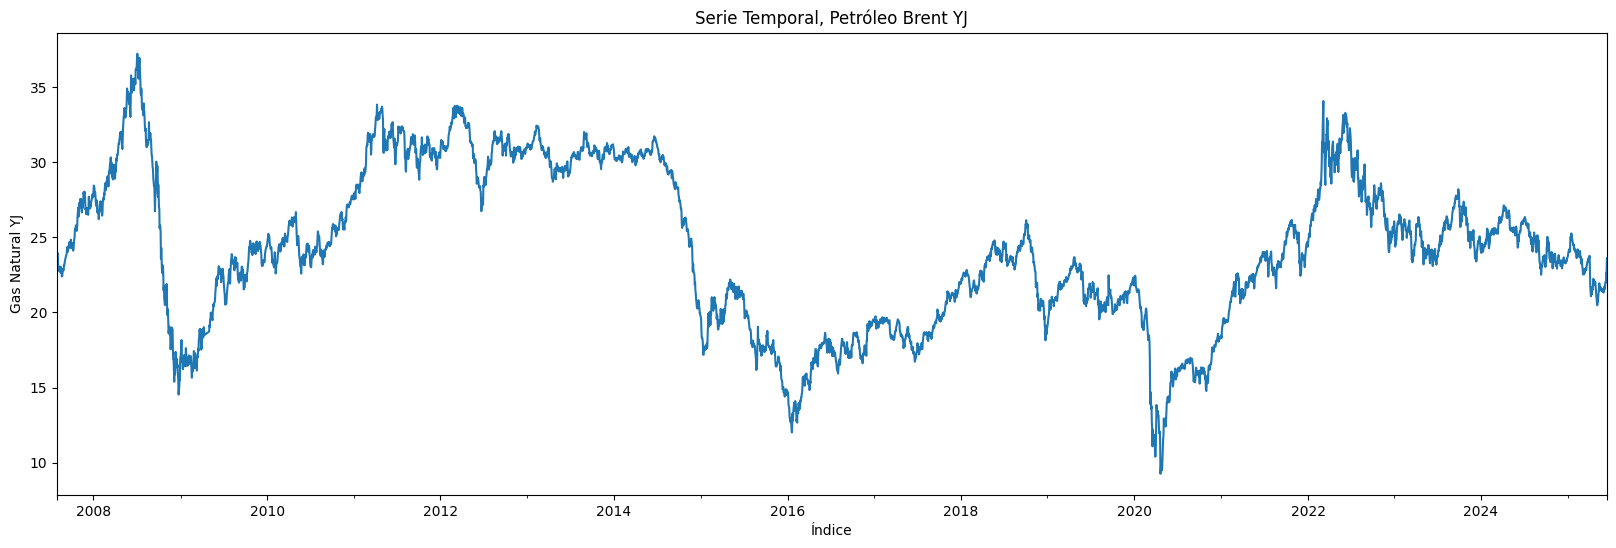

In [102]:
df_petroleo_brent_final['petroleo_brent_yj'].plot(figsize=(20,6))
plt.xlabel('Índice')
plt.ylabel('Gas Natural YJ')
plt.title('Serie Temporal, Petróleo Brent YJ')
plt.show()

In [103]:
import pandas as pd
import numpy as np

# =========================================================
# Helper: toma el primer objeto que exista en memoria
# =========================================================
def tomar_primero_existente(candidatos):
    for nombre in candidatos:
        if nombre in globals():
            return globals()[nombre]
    return None


# =========================================================
# Helper: extrae variables seleccionadas por commodity
# - Si recibe un granger_df con columnas Feature / Significant_Lag*
#   usa eso.
# - Si recibe una lista, la usa.
# - Si recibe el df_final ya filtrado, toma sus columnas.
# =========================================================
def extraer_vars_seleccionadas(obj, commodity):
    excluir = {commodity, f"{commodity}_yj", f"{commodity}_yj_dif"}

    if obj is None:
        return []

    # Caso 1: DataFrame
    if isinstance(obj, pd.DataFrame):
        cols = obj.columns.astype(str).tolist()

        # Caso 1A: es un DataFrame tipo granger_df
        if "Feature" in cols:
            df_aux = obj.copy()

            sig_cols = [c for c in df_aux.columns if str(c).lower().startswith("significant_lag")]

            # Si no existe granger_test, lo construimos
            if "granger_test" not in df_aux.columns and len(sig_cols) > 0:
                df_aux["granger_test"] = df_aux[sig_cols].any(axis=1).astype(int)

            # Si existe granger_test, usamos solo las variables seleccionadas
            if "granger_test" in df_aux.columns:
                vars_sel = df_aux.loc[df_aux["granger_test"] == 1, "Feature"].astype(str).tolist()
            else:
                # fallback: si no existe granger_test, toma todas las Feature
                vars_sel = df_aux["Feature"].astype(str).tolist()

            vars_sel = [v for v in vars_sel if v not in excluir]
            return sorted(set(vars_sel))

        # Caso 1B: es un df_final ya filtrado
        vars_sel = [c for c in cols if c not in excluir]
        return sorted(set(vars_sel))

    # Caso 2: lista / tupla / set / index / ndarray
    if isinstance(obj, (list, tuple, set, pd.Index, np.ndarray)):
        vars_sel = [str(x) for x in obj if str(x) not in excluir]
        return sorted(set(vars_sel))

    return []


# =========================================================
# Busca automáticamente tus objetos ya creados en el notebook
# Prioriza granger_df_*; si no existe, usa df_*_final; si no, usa lista_variables_*
# =========================================================
fuentes_por_commodity = {
    "oro": tomar_primero_existente([
        "granger_df_oro",
        "df_oro_final",
        "lista_variables_oro"
    ]),
    "plata": tomar_primero_existente([
        "granger_df_plata",
        "df_plata_final",
        "lista_variables_plata"
    ]),
    "cobre": tomar_primero_existente([
        "granger_df_cobre",
        "df_cobre_final",
        "lista_variables_cobre"
    ]),
    "petroleo_brent": tomar_primero_existente([
        "granger_df_petroleo",
        "df_petroleo_brent_final",
        "lista_variables_petroleo_brent"
    ]),
    "gas_natural": tomar_primero_existente([
        "granger_df_gas_natural",
        "df_gas_natural_final",
        "lista_variables_gas_natural"
    ]),
}

# =========================================================
# Extraer variables seleccionadas por commodity
# =========================================================
vars_por_commodity = {
    commodity: extraer_vars_seleccionadas(obj, commodity)
    for commodity, obj in fuentes_por_commodity.items()
    if obj is not None
}

# Verificación rápida
print("Variables seleccionadas por commodity:\n")
for commodity, vars_sel in vars_por_commodity.items():
    print(f"{commodity}: {len(vars_sel)} variables")


# =========================================================
# Universo total de variables
# =========================================================
if len(vars_por_commodity) == 0:
    raise ValueError("No encontré objetos de Granger o df_final en memoria.")

universo_variables = sorted(set().union(*[set(v) for v in vars_por_commodity.values()]))

# =========================================================
# DataFrame dummy ancho: una fila por commodity
# =========================================================
df_dummy_commodities = pd.DataFrame(
    0,
    index=vars_por_commodity.keys(),
    columns=universo_variables,
    dtype=int
)

for commodity, vars_sel in vars_por_commodity.items():
    cols_validas = [c for c in vars_sel if c in df_dummy_commodities.columns]
    df_dummy_commodities.loc[commodity, cols_validas] = 1

df_dummy_commodities = df_dummy_commodities.reset_index().rename(columns={"index": "commodity"})

# Agregamos columnas resumen
df_dummy_commodities.insert(
    1,
    "n_variables_usadas",
    df_dummy_commodities.drop(columns=["commodity"]).sum(axis=1)
)

df_resumen_texto = pd.DataFrame({
    "commodity": list(vars_por_commodity.keys()),
    "variables_usadas": [", ".join(vars_por_commodity[c]) for c in vars_por_commodity.keys()]
})

df_dummy_commodities = df_dummy_commodities.merge(df_resumen_texto, on="commodity", how="left")

# Orden final de columnas
cols_fijas = ["commodity", "n_variables_usadas", "variables_usadas"]
cols_dummies = [c for c in df_dummy_commodities.columns if c not in cols_fijas]
df_dummy_commodities = df_dummy_commodities[cols_fijas + cols_dummies]

# =========================================================
# DataFrame largo: una fila por commodity-variable
# =========================================================
df_largo_commodities = (
    df_dummy_commodities
    .drop(columns=["n_variables_usadas", "variables_usadas"])
    .melt(id_vars="commodity", var_name="variable", value_name="usada")
    .sort_values(["commodity", "usada", "variable"], ascending=[True, False, True])
    .reset_index(drop=True)
)

# Solo las usadas
df_largo_commodities_usadas = df_largo_commodities[df_largo_commodities["usada"] == 1].reset_index(drop=True)

# =========================================================
# Mostrar resultados
# =========================================================
print("\n=== DF DUMMY POR COMMODITY ===")
display(df_dummy_commodities)

print("\n=== DF LARGO (todas las variables) ===")
display(df_largo_commodities)

print("\n=== DF LARGO (solo variables usadas) ===")
display(df_largo_commodities_usadas)

Variables seleccionadas por commodity:

oro: 23 variables
plata: 19 variables
cobre: 16 variables
petroleo_brent: 20 variables
gas_natural: 6 variables

=== DF DUMMY POR COMMODITY ===


,commodity,n_variables_usadas,variables_usadas,aem,ag,amd,bhp,ctra,desempleo_can,desempleo_fra,desempleo_ita,desempleo_jpn,desempleo_usa,dxy_fut,emergentes,eqt,fcx,gas_natural,googl,kgc,nem,paas,petroleo_brent,pib_gbr,pib_ita,plata,shanghai,shel,sp500,tasa_5y,vix,wpm,xom
0,oro,23,"aem, ag, amd, bhp, ctra, desempleo_can, desemp...",1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,1,1,1,1,1,0,0,0,1,0,1,1,1,0
1,plata,19,"aem, ag, bhp, ctra, desempleo_can, desempleo_j...",1,1,0,1,1,1,0,0,1,1,1,1,1,1,0,0,1,1,1,1,1,0,0,0,1,0,0,1,1,0
2,cobre,16,"aem, ag, bhp, ctra, desempleo_can, emergentes,...",1,1,0,1,1,1,0,0,0,0,0,1,1,1,1,0,1,1,1,1,0,0,0,0,1,1,0,1,0,0
3,petroleo_brent,20,"aem, ag, bhp, ctra, desempleo_can, desempleo_i...",1,1,0,1,1,1,0,1,0,1,0,1,1,1,1,0,1,1,1,0,1,1,1,1,0,0,0,1,0,1
4,gas_natural,6,"desempleo_can, desempleo_usa, googl, nem, paas...",0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,1,1,0,0,0,1,0,0,0,0,0,0,0



=== DF LARGO (todas las variables) ===


,commodity,variable,usada
0,cobre,aem,1
1,cobre,ag,1
2,cobre,bhp,1
3,cobre,ctra,1
4,cobre,desempleo_can,1
...,...,...,...
145,plata,plata,0
146,plata,shanghai,0
147,plata,sp500,0
148,plata,tasa_5y,0



=== DF LARGO (solo variables usadas) ===


,commodity,variable,usada
0,cobre,aem,1
1,cobre,ag,1
2,cobre,bhp,1
3,cobre,ctra,1
4,cobre,desempleo_can,1
...,...,...,...
79,plata,petroleo_brent,1
80,plata,pib_gbr,1
81,plata,shel,1
82,plata,vix,1


In [104]:
df_largo_commodities_usadas.to_csv("dim_features_commodities.csv", index=False)